In [2]:

!apt-get install -y fonts-nanum*
!rm -rf /root/.cache/matplotlib/* # 폰트 캐시 재설정

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# Nanum 글꼴 설치
!apt-get -y install fonts-nanum

# matplotlib에서 한글 폰트 사용 설정
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

# 나눔 글꼴 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_manager.fontManager.addfont(font_path)
rc('font', family='NanumGothic')

import matplotlib.font_manager as fm
!apt-get -qq install fonts-nanum

fe = fm.FontEntry(
    fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams.update({'font.size': 10, 'font.family': 'NanumGothic'}) # 폰트 설정

import matplotlib.pyplot as plt
from matplotlib import font_manager

# 글꼴 경로 추가
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_manager.fontManager.addfont(font_path)

# 한글을 사용할 수 있도록 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'fonts-nanum-extra' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-coding' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-eco' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum' for glob 'fonts-nanum*'
The following NEW packages will be installed:
  fonts-nanum fonts-nanum-coding fonts-nanum-eco fonts-nanum-extra
0 upgraded, 4 newly installed, 0 to remove and 2 not upgraded.
Need to get 46.0 MB of archives.
After this operation, 177 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-coding all 2.5-3 [4,988 B]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-eco all 1.000-7 [14.7 MB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-extra all 20200506-1 [21.0 

In [3]:
import requests
from google.colab import drive

# 1. 구글 드라이브 마운트 (연결)
# 코드를 처음 실행하면 구글 계정 권한 허용 창이 뜹니다. 허용해 주세요!
drive.mount('/content/drive')

Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔄 [1/3] 지도 경계 및 격자판 세팅 (거리 계산을 위해 EPSG:5179 적용)


🏥 [2/3] 보건지소 데이터 불러오기 및 좌표 변환
✨ [3/3] 격자 중심점과 보건지소 위치 교차 시각화


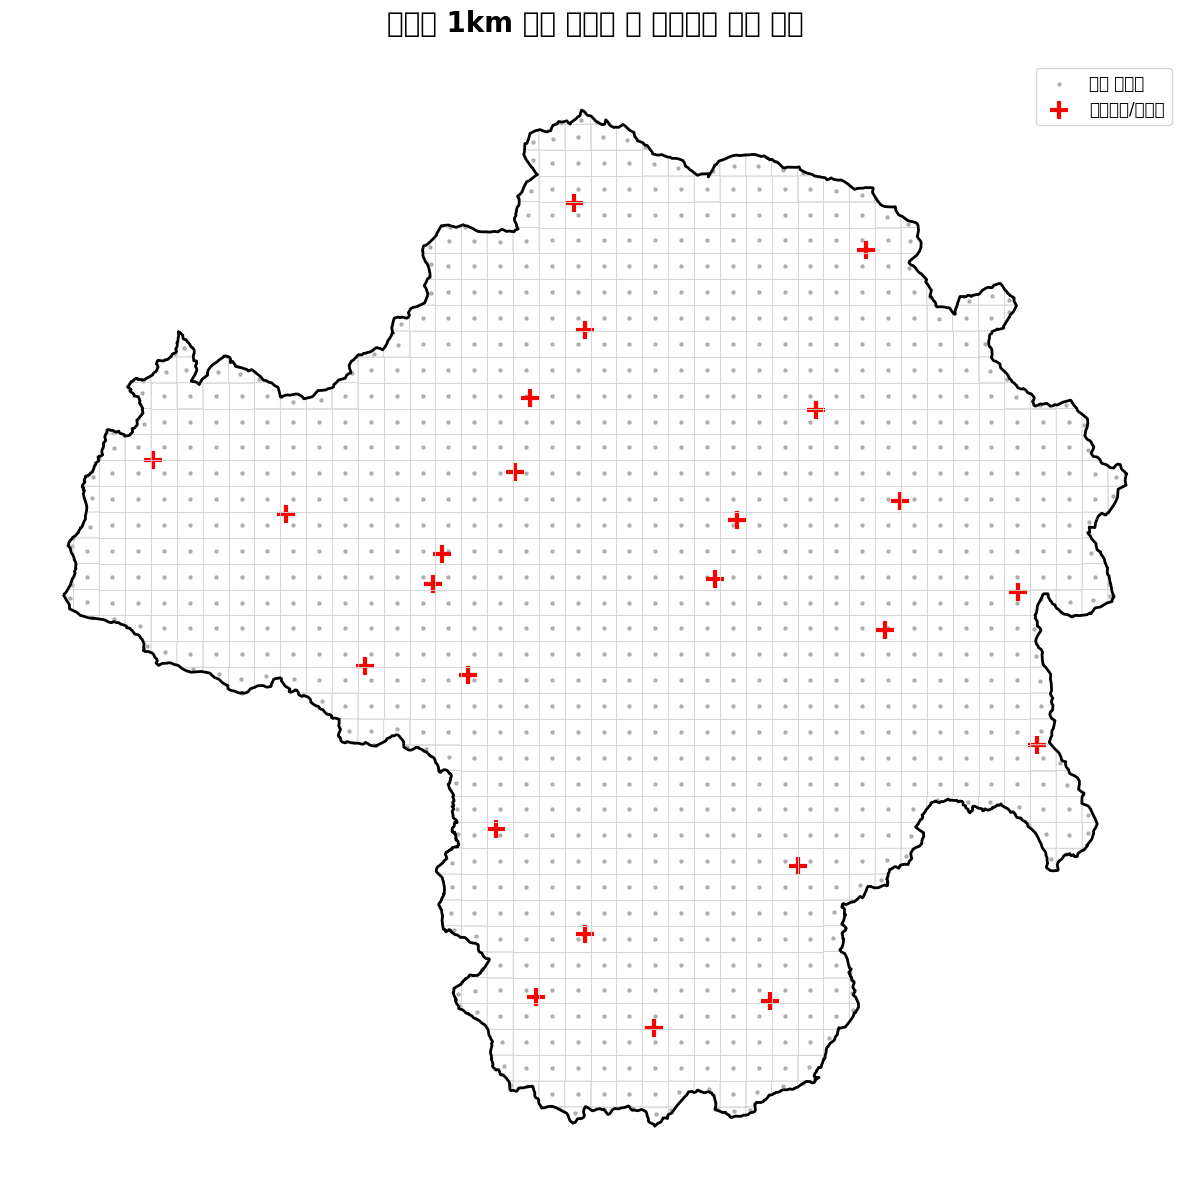


[참고] 첫 3개 격자의 중심점 좌표 (미터 단위 EPSG:5179):


,geometry,centroid
2461,"POLYGON ((1125000 1762000, 1125000 1761640.42,...",POINT (1124932.413 1761827.952)
2264,"POLYGON ((1123000 1765000, 1123000 1764768.668...",POINT (1122935.551 1764903.341)
2462,"POLYGON ((1125000 1763000, 1125000 1762000, 11...",POINT (1124651.299 1762598.048)


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import warnings
import requests
from google.colab import drive

# 1. 구글 드라이브 마운트 (연결)
# 코드를 처음 실행하면 구글 계정 권한 허용 창이 뜹니다. 허용해 주세요!
drive.mount('/content/drive')

# 경고창 무시 및 한글 폰트 설정
warnings.filterwarnings('ignore')
plt.rc('font', family='NanumBarunGothic')

# ==============================================================
# 🚨 [세팅값] 데이터 경로 설정
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

SHP_PATH = BASE_DIR + '_grid_border_grid_2025_grid_마마_grid_마마/grid_마마_1K.shp'
BORDER_PATH = BASE_DIR + '시군구/bnd_sigungu_37070_2025_2Q.shp'
CLINIC_PATH = BASE_DIR + '경상북도 영천시_보건지소및보건진료소현황(공공데이터포털,24).csv'

# ==============================================================
print("🔄 [1/3] 지도 경계 및 격자판 세팅 (거리 계산을 위해 EPSG:5179 적용)")
# ==============================================================
# 1. 영천시 경계선 세팅
try:
    sigungu_map = gpd.read_file(BORDER_PATH, encoding='utf-8')
except:
    sigungu_map = gpd.read_file(BORDER_PATH, encoding='cp949')

sigungu_map = sigungu_map.to_crs(epsg=5179)
yeongcheon_border = sigungu_map[sigungu_map['SIGUNGU_NM'].str.contains('영천', na=False)].copy()
if len(yeongcheon_border) == 0: yeongcheon_border = sigungu_map.copy()

# 2. 1km 격자판 세팅 및 자르기
try:
    grid_map = gpd.read_file(SHP_PATH, encoding='utf-8').set_crs(epsg=5179, allow_override=True)
except:
    grid_map = gpd.read_file(SHP_PATH, encoding='cp949').set_crs(epsg=5179, allow_override=True)

yeongcheon_grid = gpd.clip(grid_map, yeongcheon_border)

# 🌟 핵심: 각 격자의 정중앙 좌표(Centroid) 추출
# EPSG:5179 상태에서 추출해야 정확한 미터(m) 단위 중심점을 얻을 수 있습니다.
yeongcheon_grid['centroid'] = yeongcheon_grid.geometry.centroid


# ==============================================================
print("🏥 [2/3] 보건지소 데이터 불러오기 및 좌표 변환")
# ==============================================================
try:
    df_clinic = pd.read_csv(CLINIC_PATH, encoding='utf-8-sig')
except:
    df_clinic = pd.read_csv(CLINIC_PATH, encoding='cp949')

# 위도, 경도 결측치 제거 후 공간 데이터프레임으로 변환
df_clinic = df_clinic.dropna(subset=['위도', '경도'])
gdf_clinic = gpd.GeoDataFrame(
    df_clinic,
    geometry=gpd.points_from_xy(df_clinic['경도'], df_clinic['위도']),
    crs="EPSG:4326" # 원본은 위경도
).to_crs(epsg=5179) # 격자와 동일한 미터법 좌표계로 통일


# ==============================================================
print("✨ [3/3] 격자 중심점과 보건지소 위치 교차 시각화")
# ==============================================================
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# 1. 영천시 전체 격자 그리기 (배경)
yeongcheon_grid.boundary.plot(ax=ax, color='lightgray', linewidth=0.5)

# 2. 영천시 외곽선 굵게
yeongcheon_border.boundary.plot(ax=ax, color='black', linewidth=2)

# 3. 격자의 중심점(Centroid) 찍기 (작은 회색 점)
yeongcheon_grid['centroid'].plot(ax=ax, color='gray', markersize=5, alpha=0.5, label='격자 중심점')

# 4. 보건지소 위치 찍기 (큰 빨간색 마커)
gdf_clinic.plot(ax=ax, color='red', marker='+', markersize=150, linewidth=3, label='보건지소/진료소')

ax.set_title("영천시 1km 격자 중심점 및 보건지소 분포 현황", fontsize=20, fontweight='bold', pad=20)
ax.axis('off')
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

# 팁: 나중에 거리 계산 테스트를 위해 첫 3개 격자 정보만 출력해보기
print("\n[참고] 첫 3개 격자의 중심점 좌표 (미터 단위 EPSG:5179):")
display(yeongcheon_grid[['geometry', 'centroid']].head(3))

🔄 [1/4] 데이터 로드 및 좌표계 세팅 (거리 계산용 EPSG:5179)
🚀 [2/4] 각 격자별 최단 차량 이동 시간 계산 시작! (TEST_MODE: True)


   - 10/10 격자 처리 완료
💾 [3/4] 계산 결과 CSV 파일 저장 -> /content/drive/MyDrive/영천의미학/영천시_보건지소_차량접근성.csv
✨ [4/4] 보건지소 차량 소요시간 히트맵 시각화


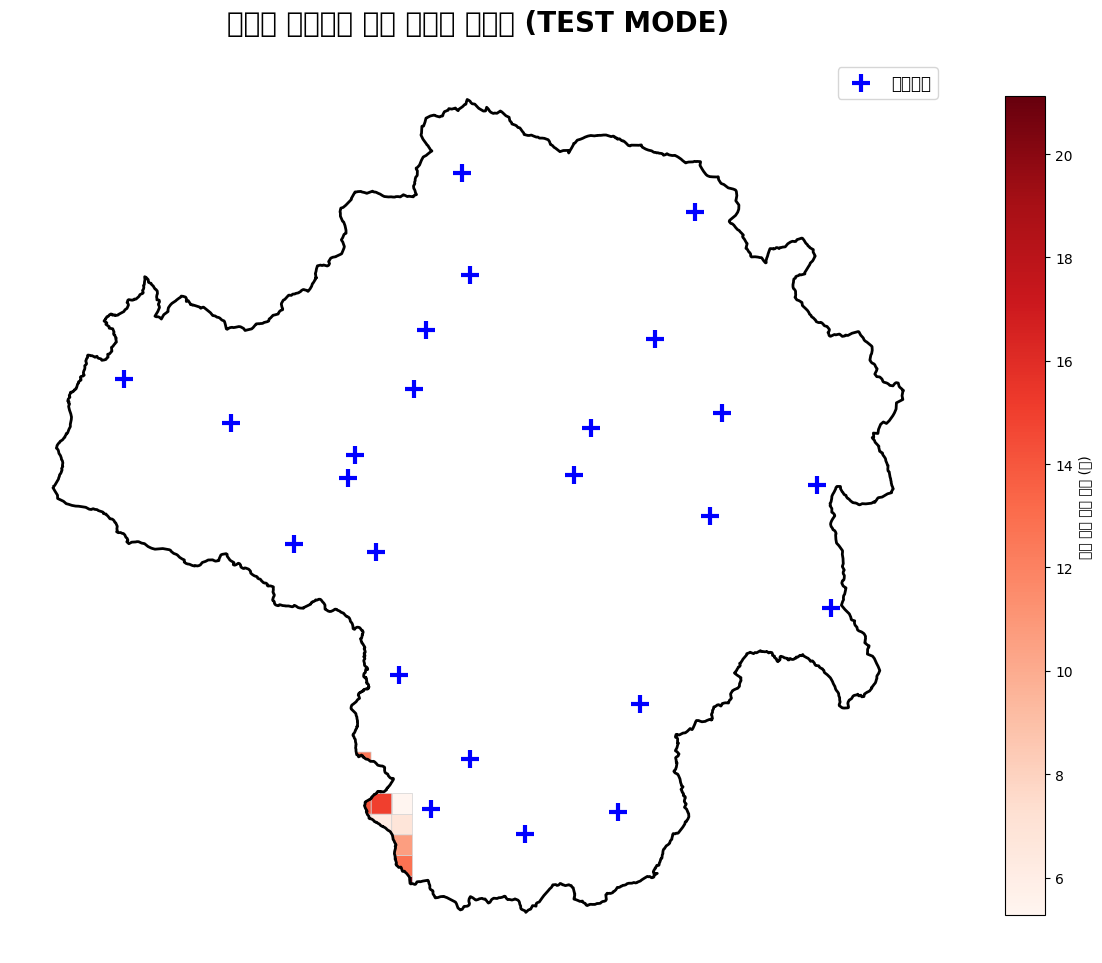


[📊 계산된 차량 이동 시간 데이터 미리보기]


,GRID_CD,min_drive_time_mins
2461,마마2461,21.116667
2264,마마2264,6.583333
2462,마마2462,12.816667
2463,마마2463,10.600000
2364,마마2364,6.166667


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import numpy as np
import time
import warnings

# 경고창 무시 및 한글 폰트 설정
warnings.filterwarnings('ignore')
plt.rc('font', family='NanumBarunGothic')

# ==============================================================
# 🚨 [세팅값] 데이터 경로 및 API 설정
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'
SHP_PATH = BASE_DIR + '_grid_border_grid_2025_grid_마마_grid_마마/grid_마마_1K.shp'
BORDER_PATH = BASE_DIR + '시군구/bnd_sigungu_37070_2025_2Q.shp'
CLINIC_PATH = BASE_DIR + '경상북도 영천시_보건지소및보건진료소현황(공공데이터포털,24).csv'

# 카카오 모빌리티(내비) API 키
KAKAO_API_KEY = "a74e16d4b116fdd2c8afc6ffb3310250"

# 🌟 회의 시연용 테스트 모드 (True: 10개 격자만 빠르게 테스트 / False: 영천시 전체 분석)
TEST_MODE = True

# 최종 저장될 파일 이름
SAVE_CSV_PATH = BASE_DIR + '영천시_보건지소_차량접근성.csv'

# ==============================================================
print("🔄 [1/4] 데이터 로드 및 좌표계 세팅 (거리 계산용 EPSG:5179)")
# ==============================================================
# 1. 영천시 경계선 및 격자판 세팅
try:
    sigungu_map = gpd.read_file(BORDER_PATH, encoding='utf-8')
except:
    sigungu_map = gpd.read_file(BORDER_PATH, encoding='cp949')

sigungu_map = sigungu_map.to_crs(epsg=5179)
yeongcheon_border = sigungu_map[sigungu_map['SIGUNGU_NM'].str.contains('영천', na=False)].copy()
if len(yeongcheon_border) == 0: yeongcheon_border = sigungu_map.copy()

try:
    grid_map = gpd.read_file(SHP_PATH, encoding='utf-8').set_crs(epsg=5179, allow_override=True)
except:
    grid_map = gpd.read_file(SHP_PATH, encoding='cp949').set_crs(epsg=5179, allow_override=True)

yeongcheon_grid = gpd.clip(grid_map, yeongcheon_border)

# 격자 중심점(Centroid) 계산
yeongcheon_grid['centroid'] = yeongcheon_grid.geometry.centroid
grid_col = yeongcheon_grid.columns[0] # 격자 ID 컬럼명 추출

# 2. 보건지소 데이터 세팅 (인코딩 자동 탐지 적용)
def load_csv_safe(path):
    encodings = ['utf-8', 'cp949', 'euc-kr', 'utf-8-sig']
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"모든 인코딩으로 {path} 파일을 열 수 없습니다.")

df_clinic = load_csv_safe(CLINIC_PATH).dropna(subset=['위도', '경도'])
gdf_clinic = gpd.GeoDataFrame(df_clinic, geometry=gpd.points_from_xy(df_clinic['경도'], df_clinic['위도']), crs="EPSG:4326").to_crs(epsg=5179)


# ==============================================================
print(f"🚀 [2/4] 각 격자별 최단 차량 이동 시간 계산 시작! (TEST_MODE: {TEST_MODE})")
# ==============================================================
# 카카오내비 API 호출 함수 (자동차 길찾기)
def get_driving_time(orig_lon, orig_lat, dest_lon, dest_lat):
    url = "https://apis-navi.kakaomobility.com/v1/directions"
    headers = {"Authorization": f"KakaoAK {KAKAO_API_KEY}"}
    params = {
        "origin": f"{orig_lon},{orig_lat}",
        "destination": f"{dest_lon},{dest_lat}",
        "priority": "RECOMMEND" # 추천 경로 기준
    }
    try:
        res = requests.get(url, headers=headers, params=params)
        if res.status_code == 200:
            data = res.json()
            if data['routes'][0]['result_code'] == 0:
                # API는 초(second) 단위로 반환하므로 분(minute) 단위로 변환
                return data['routes'][0]['summary']['duration'] / 60.0
    except Exception as e:
        pass
    return float('inf') # 경로를 못 찾은 경우 무한대 반환

# 분석할 격자 추출 (테스트 모드면 10개만)
target_grids = yeongcheon_grid.head(10).copy() if TEST_MODE else yeongcheon_grid.copy()
min_times = []

total_count = len(target_grids)
for idx, row in enumerate(target_grids.itertuples(), 1):
    centroid = row.centroid

    # 1. 유클리드(직선) 거리 기준 모든 보건지소와의 거리 계산
    distances = gdf_clinic.geometry.distance(centroid)

    # 2. 가장 가까운 Top 3 보건지소 인덱스 추출
    top3_indices = distances.nsmallest(3).index
    top3_clinics = gdf_clinic.loc[top3_indices]

    # 3. Top 3 시설에 대해 API 호출을 위해 WGS84(위경도)로 좌표 변환
    orig_geom = gpd.GeoSeries([centroid], crs="EPSG:5179").to_crs(epsg=4326).iloc[0]
    orig_lon, orig_lat = orig_geom.x, orig_geom.y

    times = []
    for clinic_idx, clinic_row in top3_clinics.iterrows():
        dest_geom = gpd.GeoSeries([clinic_row.geometry], crs="EPSG:5179").to_crs(epsg=4326).iloc[0]
        dest_lon, dest_lat = dest_geom.x, dest_geom.y

        # API 호출 및 소요 시간 수집
        driving_time = get_driving_time(orig_lon, orig_lat, dest_lon, dest_lat)
        times.append(driving_time)
        time.sleep(0.05) # API 호출 제한(Rate Limit) 방지를 위한 짧은 대기

    # 4. Top 3 중 가장 짧은 '최소 이동 시간' 기록
    best_time = min(times)
    min_times.append(best_time if best_time != float('inf') else None)

    if idx % 10 == 0 or idx == total_count:
        print(f"   - {idx}/{total_count} 격자 처리 완료")

target_grids['min_drive_time_mins'] = min_times


# ==============================================================
print(f"💾 [3/4] 계산 결과 CSV 파일 저장 -> {SAVE_CSV_PATH}")
# ==============================================================
# 지도 형상(geometry)을 제외한 데이터만 깔끔하게 저장
save_df = target_grids.drop(columns=['geometry', 'centroid'])
save_df.to_csv(SAVE_CSV_PATH, index=False, encoding='utf-8-sig')


# ==============================================================
print("✨ [4/4] 보건지소 차량 소요시간 히트맵 시각화")
# ==============================================================
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# 시간이 길수록(취약할수록) 붉은색을 띠도록 시각화 (Reds)
target_grids.plot(column='min_drive_time_mins', ax=ax, cmap='Reds',
                  edgecolor='lightgray', linewidth=0.5, legend=True,
                  legend_kwds={'label': "최소 차량 소요 시간 (분)", 'shrink': 0.7},
                  missing_kwds={'color': 'white'}) # 결측치나 테스트 안한 곳은 하얗게

yeongcheon_border.boundary.plot(ax=ax, color='black', linewidth=2)
gdf_clinic.plot(ax=ax, color='blue', marker='+', markersize=150, linewidth=3, label='보건지소')

title = "영천시 보건지소 차량 접근성 핫스팟 (TEST MODE)" if TEST_MODE else "영천시 보건지소 차량 접근성 핫스팟"
ax.set_title(title, fontsize=20, fontweight='bold', pad=20)
ax.axis('off')
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

# 최종 데이터 맛보기
print("\n[📊 계산된 차량 이동 시간 데이터 미리보기]")
display(save_df[[grid_col, 'min_drive_time_mins']].head())

🔄 [1/3] 지도 경계 및 격자판 세팅
👥 [2/3] 전체 인구 데이터 결합 및 '빈 격자' 필터링

✅ 영천시 총 격자 수: 1014개
👉 제외할 '빈 격자(인구 0명)': 293개 (전체의 28.9%)
👉 실제 분석(API 호출) 대상: 721개
✨ [3/3] 제외 대상(빈 격자) 시각화


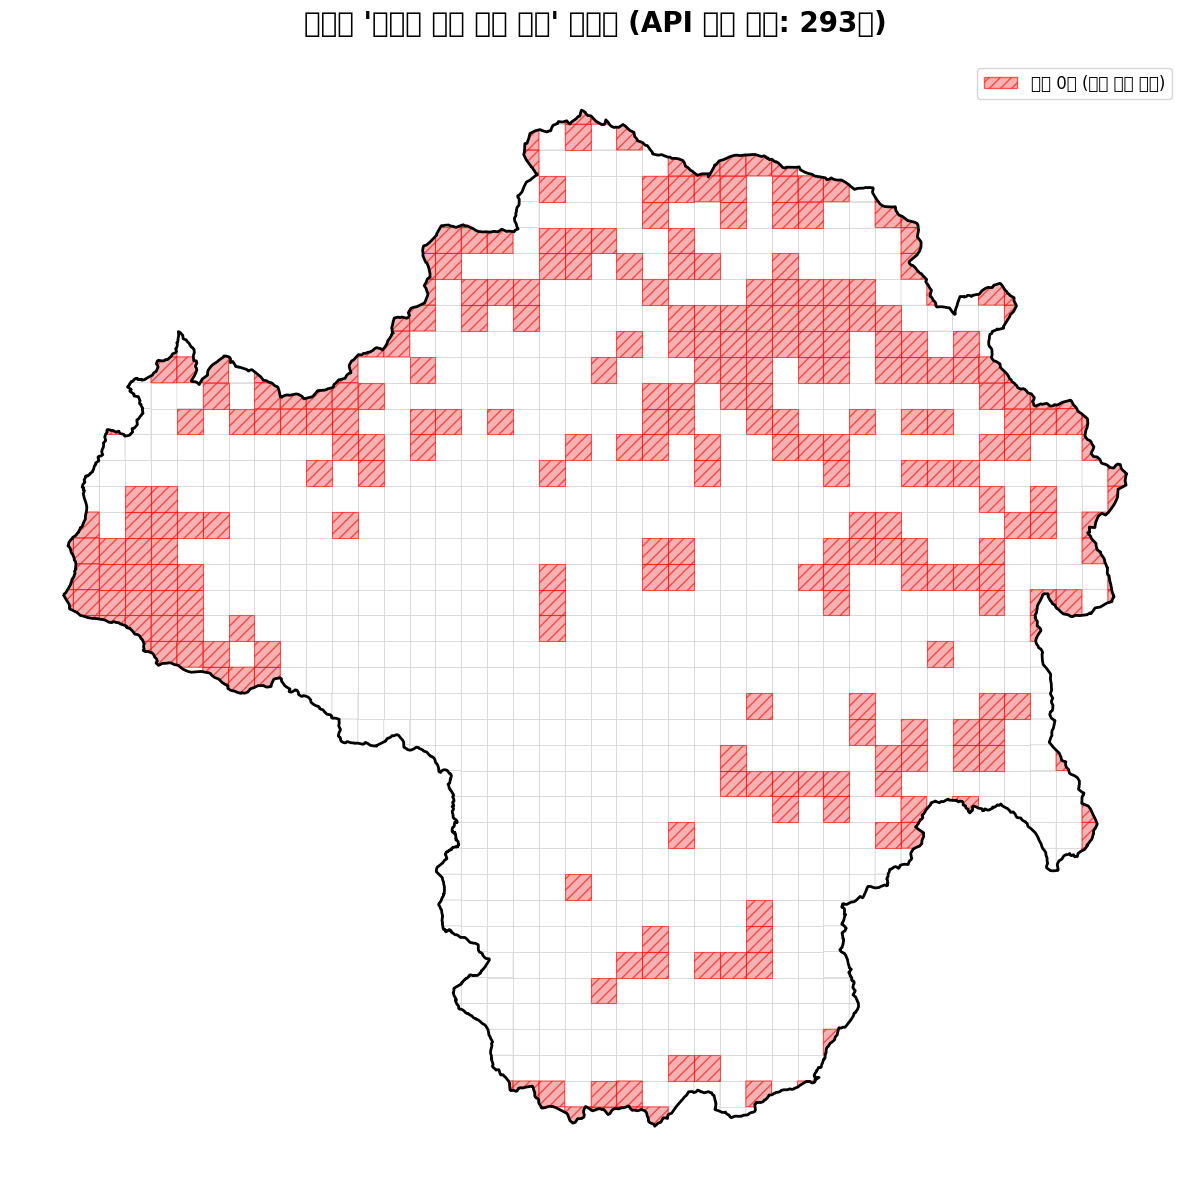

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings

# 경고창 무시 및 한글 폰트 설정
warnings.filterwarnings('ignore')
plt.rc('font', family='NanumBarunGothic')

# ==============================================================
# 🚨 [세팅값] 데이터 경로 설정
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

SHP_PATH = BASE_DIR + '_grid_border_grid_2025_grid_마마_grid_마마/grid_마마_1K.shp'
BORDER_PATH = BASE_DIR + '시군구/bnd_sigungu_37070_2025_2Q.shp'
# 🌟 전체 인구가 들어있는 원본 파일
POP_ALL_PATH = BASE_DIR + '2024년_인구_마마_1K.csv'

# ==============================================================
print("🔄 [1/3] 지도 경계 및 격자판 세팅")
# ==============================================================
try:
    sigungu_map = gpd.read_file(BORDER_PATH, encoding='utf-8')
except:
    sigungu_map = gpd.read_file(BORDER_PATH, encoding='cp949')

sigungu_map = sigungu_map.to_crs(epsg=5179)
yeongcheon_border = sigungu_map[sigungu_map['SIGUNGU_NM'].str.contains('영천', na=False)].copy()
if len(yeongcheon_border) == 0: yeongcheon_border = sigungu_map.copy()

try:
    grid_map = gpd.read_file(SHP_PATH, encoding='utf-8').set_crs(epsg=5179, allow_override=True)
except:
    grid_map = gpd.read_file(SHP_PATH, encoding='cp949').set_crs(epsg=5179, allow_override=True)

yeongcheon_grid = gpd.clip(grid_map, yeongcheon_border)
grid_col = yeongcheon_grid.columns[0]
yeongcheon_grid[grid_col] = yeongcheon_grid[grid_col].astype(str).str.strip()


# ==============================================================
print("👥 [2/3] 전체 인구 데이터 결합 및 '빈 격자' 필터링")
# ==============================================================
# 1. 헤더 없이 데이터만 있는 CSV 구조에 맞춰 불러오기
try:
    df_pop_all = pd.read_csv(POP_ALL_PATH, header=None, names=['year', 'grid_id', 'code', 'count'], encoding='utf-8')
except:
    df_pop_all = pd.read_csv(POP_ALL_PATH, header=None, names=['year', 'grid_id', 'code', 'count'], encoding='cp949')

# 2. 전체 인구수 코드('to_in_001')만 추출
df_total_pop = df_pop_all[df_pop_all['code'] == 'to_in_001'].copy()
df_total_pop['grid_id'] = df_total_pop['grid_id'].astype(str).str.strip()

# 3. 지도 격자에 인구수 결합 (데이터가 없는 격자는 결측치 NaN 생성됨)
final_map = yeongcheon_grid.merge(df_total_pop[['grid_id', 'count']], left_on=grid_col, right_on='grid_id', how='left')

# 4. 분석 핵심 로직: 인구수가 0이거나 NaN인 곳을 True(배제 대상)로 마스킹
# (count가 NaN이거나 0 이하인 경우를 모두 '사람이 없는 곳'으로 취급)
final_map['is_empty'] = final_map['count'].isna() | (final_map['count'] <= 0)

total_grids = len(final_map)
empty_grids = final_map['is_empty'].sum()
inhabited_grids = total_grids - empty_grids

print(f"\n✅ 영천시 총 격자 수: {total_grids}개")
print(f"👉 제외할 '빈 격자(인구 0명)': {empty_grids}개 (전체의 {empty_grids/total_grids*100:.1f}%)")
print(f"👉 실제 분석(API 호출) 대상: {inhabited_grids}개")


# ==============================================================
print("✨ [3/3] 제외 대상(빈 격자) 시각화")
# ==============================================================
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# 1. 기본 영천시 배경 (사람이 사는 곳 = 하얀색)
final_map[~final_map['is_empty']].plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.5)

# 2. 🚨 배제 대상 빈 격자 칠하기 (붉은색 빗금 패턴)
final_map[final_map['is_empty']].plot(ax=ax, color='lightcoral', edgecolor='red', linewidth=0.8, alpha=0.6, hatch='///', label='인구 0명 (API 제외 대상)')

# 3. 영천시 외곽선 강조
yeongcheon_border.boundary.plot(ax=ax, color='black', linewidth=2)

ax.set_title(f"영천시 '사람이 살지 않는 격자' 분포도 (API 배제 대상: {empty_grids}개)", fontsize=20, fontweight='bold', pad=20)
ax.axis('off')

# 범례 추가를 위한 꼼수 (Hatch 패턴 범례)
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(facecolor='lightcoral', edgecolor='red', hatch='///', alpha=0.6, label='인구 0명 (거리 계산 제외)')
ax.legend(handles=[red_patch], fontsize=12, loc='upper right')

plt.tight_layout()
plt.show()

🔄 [1/4] 지도 경계 및 격자판 세팅
👥 [2/4] 고령 인구 데이터 결합 및 '2명 이하' 필터링



✅ 영천시 총 격자 수: 1014개
👉 제외할 '격자(고령인구 2명 이하)': 379개 (전체의 37.4%)
👉 실제 분석(API 호출) 대상: 635개
✨ [3/4] 제외 대상(빈 격자) 시각화


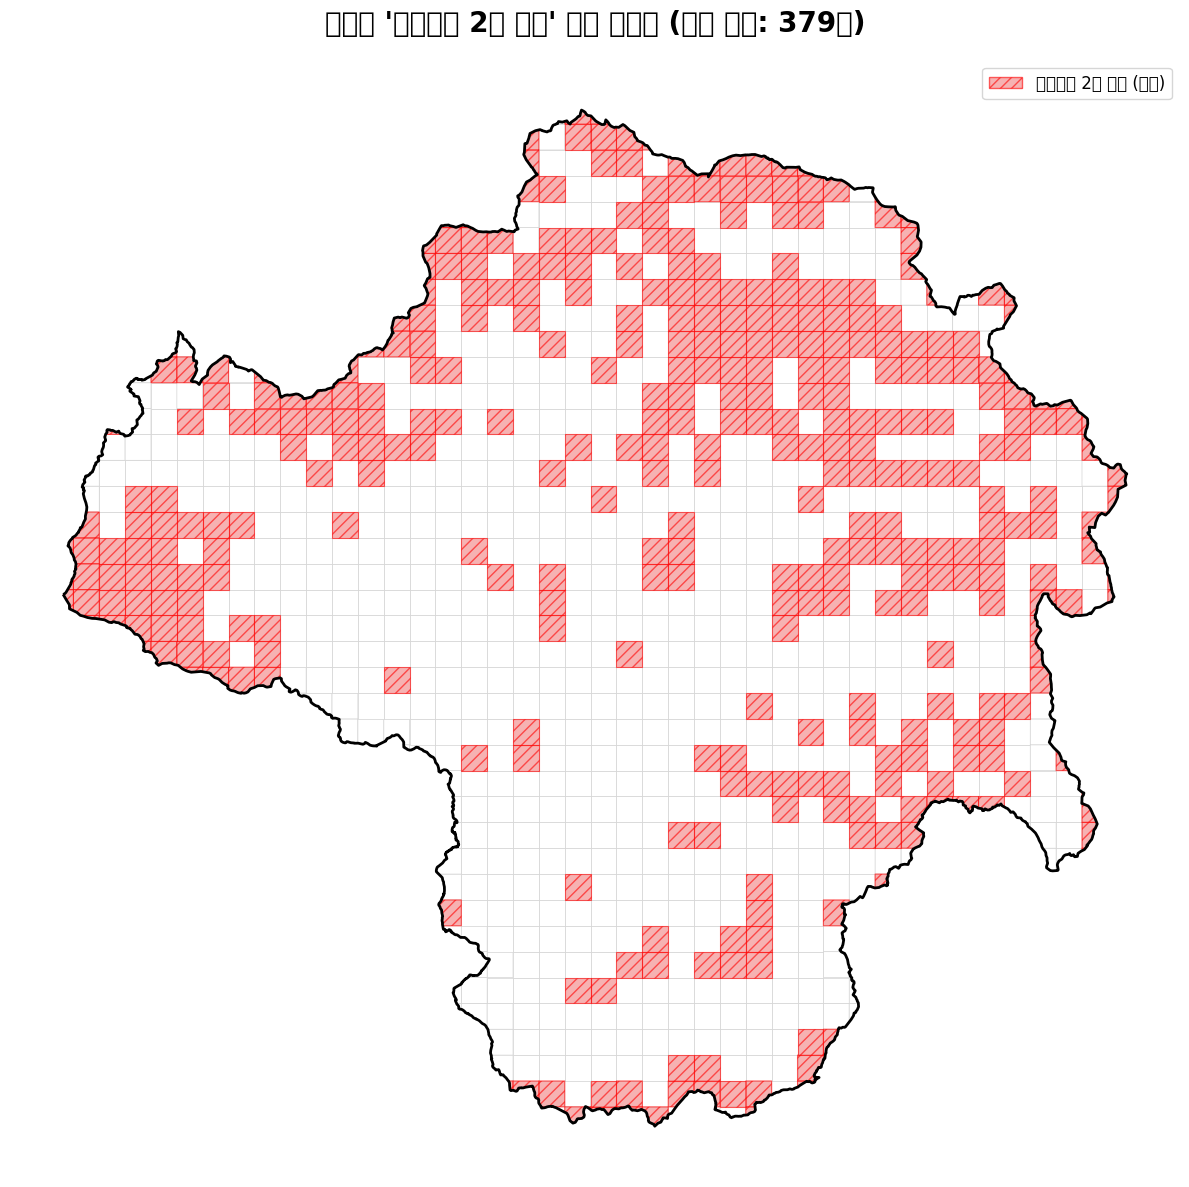

💾 [4/4] 최종 결과물 CSV 파일로 추출 및 저장
✅ 분석용 최종 CSV 파일이 성공적으로 저장되었습니다!
📁 저장 위치: /content/drive/MyDrive/영천의미학/final_active_grids(고령인구3명이상).csv


In [5]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings

# 경고창 무시 및 한글 폰트 설정
warnings.filterwarnings('ignore')
plt.rc('font', family='NanumBarunGothic')

# ==============================================================
# 🚨 [세팅값] 데이터 경로 설정
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

SHP_PATH = BASE_DIR + '_grid_border_grid_2025_grid_마마_grid_마마/grid_마마_1K.shp'
BORDER_PATH = BASE_DIR + '시군구/bnd_sigungu_37070_2025_2Q.shp'

# 🌟 팀원과 통일! '고령 인구 전처리' 데이터로 변경
POP_ALL_PATH = BASE_DIR + '2024년_인구_마마_1K_고령전처리.csv'

# ==============================================================
print("🔄 [1/4] 지도 경계 및 격자판 세팅")
# ==============================================================
try:
    sigungu_map = gpd.read_file(BORDER_PATH, encoding='utf-8')
except:
    sigungu_map = gpd.read_file(BORDER_PATH, encoding='cp949')

sigungu_map = sigungu_map.to_crs(epsg=5179)
yeongcheon_border = sigungu_map[sigungu_map['SIGUNGU_NM'].str.contains('영천', na=False)].copy()
if len(yeongcheon_border) == 0: yeongcheon_border = sigungu_map.copy()

try:
    grid_map = gpd.read_file(SHP_PATH, encoding='utf-8').set_crs(epsg=5179, allow_override=True)
except:
    grid_map = gpd.read_file(SHP_PATH, encoding='cp949').set_crs(epsg=5179, allow_override=True)

yeongcheon_grid = gpd.clip(grid_map, yeongcheon_border)
grid_col = yeongcheon_grid.columns[0]
yeongcheon_grid[grid_col] = yeongcheon_grid[grid_col].astype(str).str.strip()


# ==============================================================
print("👥 [2/4] 고령 인구 데이터 결합 및 '2명 이하' 필터링")
# ==============================================================
# 1. 고령 전처리 CSV 불러오기 (헤더 유무에 따라 안전하게 로드)
try:
    df_pop_all = pd.read_csv(POP_ALL_PATH, encoding='utf-8')
except:
    df_pop_all = pd.read_csv(POP_ALL_PATH, encoding='cp949')

# [주의] 전처리 파일의 구조가 다를 수 있어, 첫번째 컬럼을 grid_id로, 두번째를 count로 맞춥니다.
# 만약 파일 컬럼명이 명확히 있다면 아래 코드를 수정하셔도 됩니다.
if 'grid_id' not in df_pop_all.columns:
    df_pop_all.rename(columns={df_pop_all.columns[0]: 'grid_id', df_pop_all.columns[1]: 'count'}, inplace=True)

df_pop_all['grid_id'] = df_pop_all['grid_id'].astype(str).str.strip()

# 2. 지도 격자에 인구수 결합 (데이터가 없는 격자는 결측치 NaN 생성됨)
final_map = yeongcheon_grid.merge(df_pop_all[['grid_id', 'count']], left_on=grid_col, right_on='grid_id', how='left')

# 3. 🌟 분석 핵심 로직: 고령인구가 2명 이하이거나 NaN인 곳을 True(배제 대상)로 마스킹
final_map['is_empty'] = final_map['count'].isna() | (final_map['count'] <= 2)

total_grids = len(final_map)
empty_grids = final_map['is_empty'].sum()
inhabited_grids = total_grids - empty_grids

print(f"\n✅ 영천시 총 격자 수: {total_grids}개")
print(f"👉 제외할 '격자(고령인구 2명 이하)': {empty_grids}개 (전체의 {empty_grids/total_grids*100:.1f}%)")
print(f"👉 실제 분석(API 호출) 대상: {inhabited_grids}개")


# ==============================================================
print("✨ [3/4] 제외 대상(빈 격자) 시각화")
# ==============================================================
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# 1. 기본 영천시 배경 (분석 유지 대상 = 하얀색)
final_map[~final_map['is_empty']].plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.5)

# 2. 🚨 배제 대상 격자 칠하기 (붉은색 빗금 패턴, 라벨 변경)
final_map[final_map['is_empty']].plot(ax=ax, color='lightcoral', edgecolor='red', linewidth=0.8, alpha=0.6, hatch='///', label='고령인구 2명 이하 (API 제외 대상)')

# 3. 영천시 외곽선 강조
yeongcheon_border.boundary.plot(ax=ax, color='black', linewidth=2)

ax.set_title(f"영천시 '고령인구 2명 이하' 격자 분포도 (제외 대상: {empty_grids}개)", fontsize=20, fontweight='bold', pad=20)
ax.axis('off')

# 범례 추가
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(facecolor='lightcoral', edgecolor='red', hatch='///', alpha=0.6, label='고령인구 2명 이하 (제외)')
ax.legend(handles=[red_patch], fontsize=12, loc='upper right')

plt.tight_layout()
plt.show()

# ==============================================================
print("💾 [4/4] 최종 결과물 CSV 파일로 추출 및 저장")
# ==============================================================
# 1. 제거되지 않고 '살아남은' 격자(고령인구 3명 이상)만 필터링
active_grids = final_map[~final_map['is_empty']].copy()

# 2. CSV로 저장하기 위해 형태소(geometry) 공간 데이터 삭제
export_df = pd.DataFrame(active_grids.drop(columns=['geometry', 'is_empty']))

# 3. 드라이브에 CSV 파일 저장 (인코딩 utf-8-sig로 한글 깨짐 방지)
csv_save_path = BASE_DIR + 'final_active_grids(고령인구3명이상).csv'
export_df.to_csv(csv_save_path, index=False, encoding='utf-8-sig')

print(f"✅ 분석용 최종 CSV 파일이 성공적으로 저장되었습니다!")
print(f"📁 저장 위치: {csv_save_path}")

🔄 [1/5] 데이터 로드 및 좌표계 세팅 (EPSG:5179)
👥 [2/5] 대안 1: 인구수 0명인 '빈 격자' 배제 (Masking)
👉 API 호출 대상 격자 수: 20개 (Test Mode: True)
🚗 [3/5] 각 격자별 최단 차량 이동 시간 계산 (카카오내비 API)
   - 5/20 격자 API 연동 완료
   - 10/20 격자 API 연동 완료
   - 15/20 격자 API 연동 완료
   - 20/20 격자 API 연동 완료
🌊 [4/5] 대안 2: 공간 평활화 (Spatial Smoothing) 진행 중...
✨ [5/5] 보건지소 차량 접근성 히트맵 (원본 vs 평활화 비교)


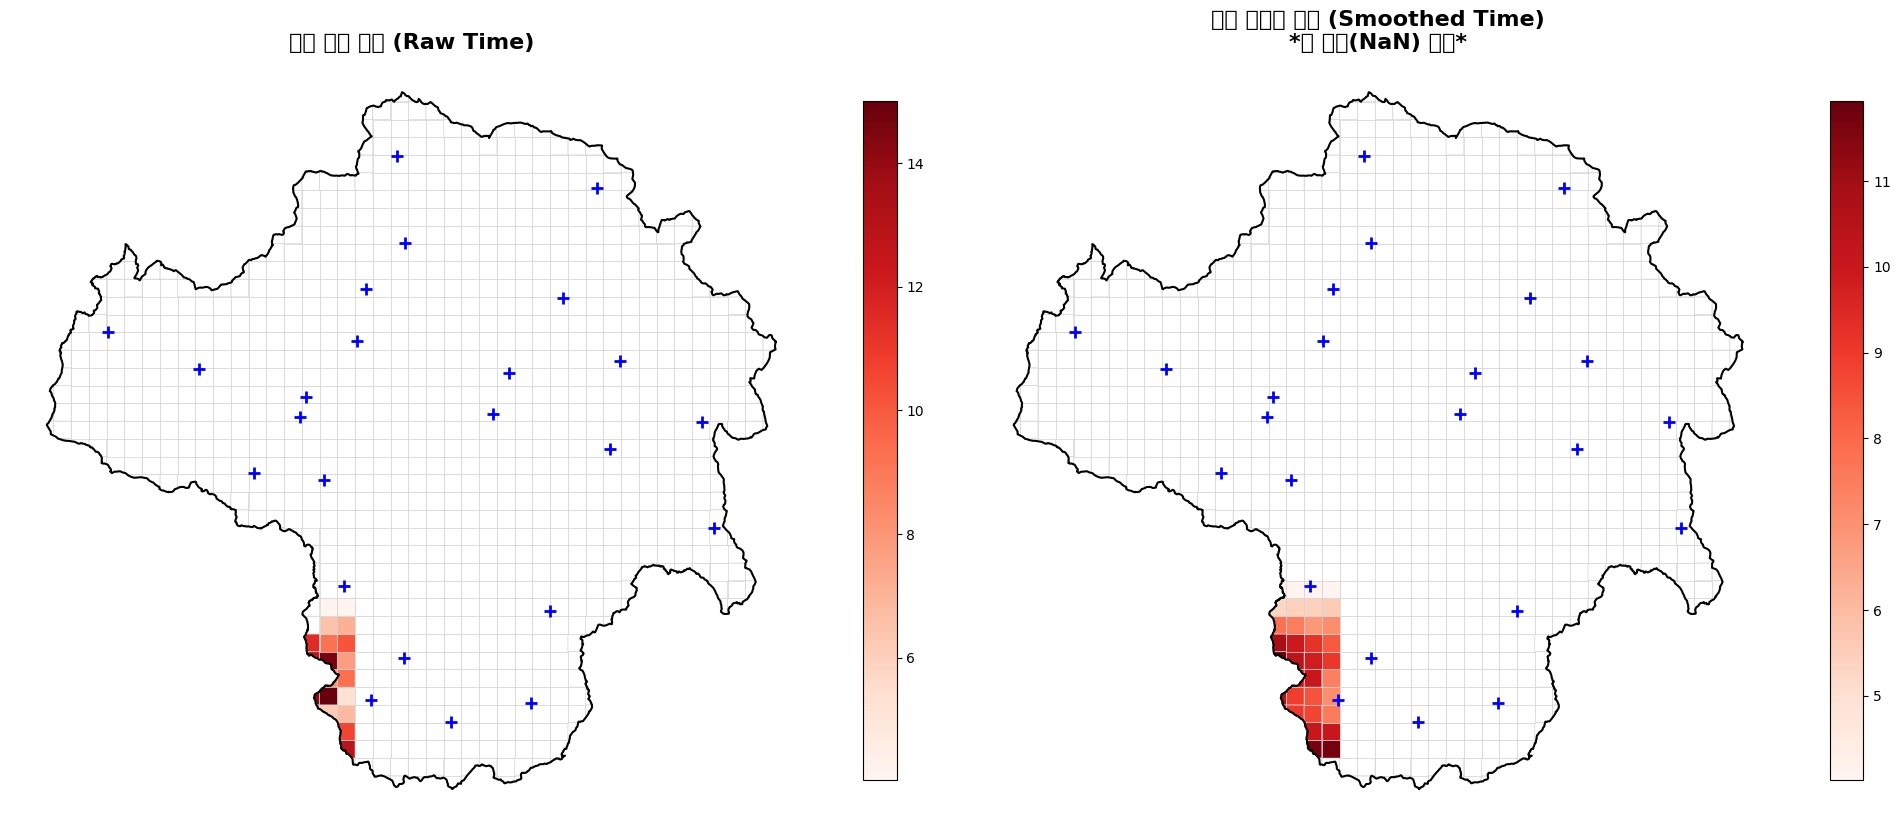

In [ ]:
# 공간 가중치 행렬을 만들기 위해 libpysal 설치가 필요합니다.
!pip install libpysal

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import numpy as np
import time
import warnings
from libpysal.weights import Queen

# 경고창 무시 및 한글 폰트 설정
warnings.filterwarnings('ignore')
plt.rc('font', family='NanumBarunGothic')

# ==============================================================
# 🚨 [세팅값] 데이터 경로 및 API 설정
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'
SHP_PATH = BASE_DIR + '_grid_border_grid_2025_grid_마마_grid_마마/grid_마마_1K.shp'
BORDER_PATH = BASE_DIR + '시군구/bnd_sigungu_37070_2025_2Q.shp'
CLINIC_PATH = BASE_DIR + '경상북도 영천시_보건지소및보건진료소현황(공공데이터포털,24).csv'
POP_ALL_PATH = BASE_DIR + '2024년_인구_마마_1K.csv'

# 카카오 모빌리티(내비) API 키
KAKAO_API_KEY = "a74e16d4b116fdd2c8afc6ffb3310250"

# 🌟 테스트 모드 설정 (True: 20개 격자만 테스트 / False: 영천시 전체 분석)
TEST_MODE = True
TEST_COUNT = 20

SAVE_CSV_PATH = BASE_DIR + '영천시_보건지소_차량접근성_Smoothing.csv'

# ==============================================================
print("🔄 [1/5] 데이터 로드 및 좌표계 세팅 (EPSG:5179)")
# ==============================================================
# 1. 영천시 경계선 및 격자판
try:
    sigungu_map = gpd.read_file(BORDER_PATH, encoding='utf-8')
except:
    sigungu_map = gpd.read_file(BORDER_PATH, encoding='cp949')
sigungu_map = sigungu_map.to_crs(epsg=5179)
yeongcheon_border = sigungu_map[sigungu_map['SIGUNGU_NM'].str.contains('영천', na=False)].copy()
if len(yeongcheon_border) == 0: yeongcheon_border = sigungu_map.copy()

try:
    grid_map = gpd.read_file(SHP_PATH, encoding='utf-8').set_crs(epsg=5179, allow_override=True)
except:
    grid_map = gpd.read_file(SHP_PATH, encoding='cp949').set_crs(epsg=5179, allow_override=True)
yeongcheon_grid = gpd.clip(grid_map, yeongcheon_border)
yeongcheon_grid['centroid'] = yeongcheon_grid.geometry.centroid
grid_col = yeongcheon_grid.columns[0]

# 2. 보건지소 데이터 (안전한 로드)
def load_csv_safe(path, header='infer', names=None):
    for enc in ['utf-8', 'cp949', 'euc-kr', 'utf-8-sig']:
        try:
            return pd.read_csv(path, encoding=enc, header=header, names=names)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"인코딩 실패: {path}")

df_clinic = load_csv_safe(CLINIC_PATH).dropna(subset=['위도', '경도'])
gdf_clinic = gpd.GeoDataFrame(df_clinic, geometry=gpd.points_from_xy(df_clinic['경도'], df_clinic['위도']), crs="EPSG:4326").to_crs(epsg=5179)


# ==============================================================
print("👥 [2/5] 대안 1: 인구수 0명인 '빈 격자' 배제 (Masking)")
# ==============================================================
df_pop_all = load_csv_safe(POP_ALL_PATH, header=None, names=['year', 'grid_id', 'code', 'count'])
df_total_pop = df_pop_all[df_pop_all['code'] == 'to_in_001'].copy()
df_total_pop['grid_id'] = df_total_pop['grid_id'].astype(str).str.strip()

final_map = yeongcheon_grid.merge(df_total_pop[['grid_id', 'count']], left_on=grid_col, right_on='grid_id', how='left')

# 사람이 없는 곳(NaN이거나 0)은 True로 마스킹
final_map['is_empty'] = final_map['count'].isna() | (final_map['count'] <= 0)

# 실제 분석할 격자만 추출 (테스트 시 앞부분 20개만)
inhabited_grids = final_map[~final_map['is_empty']].copy()
target_grids = inhabited_grids.head(TEST_COUNT).copy() if TEST_MODE else inhabited_grids.copy()

print(f"👉 API 호출 대상 격자 수: {len(target_grids)}개 (Test Mode: {TEST_MODE})")


# ==============================================================
print("🚗 [3/5] 각 격자별 최단 차량 이동 시간 계산 (카카오내비 API)")
# ==============================================================
def get_driving_time(orig_lon, orig_lat, dest_lon, dest_lat):
    url = "https://apis-navi.kakaomobility.com/v1/directions"
    headers = {"Authorization": f"KakaoAK {KAKAO_API_KEY}"}
    params = {"origin": f"{orig_lon},{orig_lat}", "destination": f"{dest_lon},{dest_lat}", "priority": "RECOMMEND"}
    try:
        res = requests.get(url, headers=headers, params=params)
        if res.status_code == 200:
            data = res.json()
            if data['routes'][0]['result_code'] == 0:
                return data['routes'][0]['summary']['duration'] / 60.0 # 분(min) 단위 반환
    except:
        pass
    return float('inf')

min_times = []
total_count = len(target_grids)

for idx, row in enumerate(target_grids.itertuples(), 1):
    centroid = row.centroid
    distances = gdf_clinic.geometry.distance(centroid)
    top3_clinics = gdf_clinic.loc[distances.nsmallest(3).index]

    orig_geom = gpd.GeoSeries([centroid], crs="EPSG:5179").to_crs(epsg=4326).iloc[0]
    orig_lon, orig_lat = orig_geom.x, orig_geom.y

    times = []
    for _, clinic_row in top3_clinics.iterrows():
        dest_geom = gpd.GeoSeries([clinic_row.geometry], crs="EPSG:5179").to_crs(epsg=4326).iloc[0]
        driving_time = get_driving_time(orig_lon, orig_lat, dest_geom.x, dest_geom.y)
        times.append(driving_time)
        time.sleep(0.05) # Rate Limit 방어

    best_time = min(times)
    min_times.append(best_time if best_time != float('inf') else np.nan)

    if idx % 5 == 0 or idx == total_count:
        print(f"   - {idx}/{total_count} 격자 API 연동 완료")

target_grids['raw_drive_time'] = min_times

# 전체 지도(final_map)에 계산된 원본 시간 병합 (계산 안 된 곳은 다 NaN)
final_map = final_map.merge(target_grids[[grid_col, 'raw_drive_time']], on=grid_col, how='left')


# ==============================================================
print("🌊 [4/5] 대안 2: 공간 평활화 (Spatial Smoothing) 진행 중...")
# ==============================================================
# 빈 격자는 영원히 NaN이므로 분모/분자에 영향 안 줌 (np.nanmean 활용)

# 1. 공간 가중치 행렬 생성 (Queen: 상하좌우 및 대각선 8방향 이웃)
# (테스트 모드일 때는 이웃이 없어 스무딩이 잘 안 보일 수 있으나 로직은 동일하게 작동합니다)
w = Queen.from_dataframe(final_map)
w.transform = 'r' # 행 표준화 (평균 내기 위함)

smoothed_times = []
for i in range(len(final_map)):
    # 현재 격자가 '빈 격자'면 스무딩도 계산하지 않고 바로 NaN
    if final_map.iloc[i]['is_empty']:
        smoothed_times.append(np.nan)
        continue

    # 현재 격자의 원본 시간
    self_time = final_map.iloc[i]['raw_drive_time']

    # 이웃 격자들의 인덱스 추출
    neighbor_indices = w.neighbors[i]
    # 이웃 격자들의 원본 시간 추출
    neighbor_times = final_map.iloc[neighbor_indices]['raw_drive_time'].tolist()

    # 자기 자신과 이웃을 포함한 리스트 생성
    all_times = [self_time] + neighbor_times

    # 🌟 핵심: np.nanmean은 리스트 내의 NaN(빈 격자 또는 계산 안 된 격자)을 무시하고
    # 유효한 숫자들의 개수(분모)로만 평균을 구합니다!
    smoothed_val = np.nanmean(all_times)
    smoothed_times.append(smoothed_val)

final_map['smooth_drive_time'] = smoothed_times

# 최종 결과 저장 (사람이 사는 격자 721개 데이터만 추출)
save_df = final_map[~final_map['is_empty']].drop(columns=['geometry', 'centroid', 'is_empty'])
save_df.to_csv(SAVE_CSV_PATH, index=False, encoding='utf-8-sig')


# ==============================================================
print("✨ [5/5] 보건지소 차량 접근성 히트맵 (원본 vs 평활화 비교)")
# ==============================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# 1. 왼쪽: 원본 시간 (raw_drive_time)
final_map.plot(column='raw_drive_time', ax=axes[0], cmap='Reds', edgecolor='lightgray', linewidth=0.5,
               legend=True, legend_kwds={'shrink': 0.7}, missing_kwds={'color': 'white'})
yeongcheon_border.boundary.plot(ax=axes[0], color='black', linewidth=1.5)
gdf_clinic.plot(ax=axes[0], color='blue', marker='+', markersize=80, linewidth=2)
axes[0].set_title("원본 소요 시간 (Raw Time)", fontsize=16, fontweight='bold')
axes[0].axis('off')

# 2. 오른쪽: 평활화된 시간 (smooth_drive_time)
final_map.plot(column='smooth_drive_time', ax=axes[1], cmap='Reds', edgecolor='lightgray', linewidth=0.5,
               legend=True, legend_kwds={'shrink': 0.7}, missing_kwds={'color': 'white'})
yeongcheon_border.boundary.plot(ax=axes[1], color='black', linewidth=1.5)
gdf_clinic.plot(ax=axes[1], color='blue', marker='+', markersize=80, linewidth=2)
axes[1].set_title("공간 평활화 적용 (Smoothed Time)\n*빈 격자(NaN) 무시*", fontsize=16, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

🔄 [1/5] 데이터 로드 및 좌표계 세팅 (EPSG:5179)
👥 [2/5] 대안 1: 인구수 0명인 '빈 격자' 배제 (Masking)
👉 API 호출 대상 격자 수: 20개 (Test Mode: True)
🚗 [3/5] 각 격자별 최단 차량 이동 시간 계산 (카카오내비 API)
   - 5/20 격자 API 연동 완료
   - 10/20 격자 API 연동 완료
   - 15/20 격자 API 연동 완료
   - 20/20 격자 API 연동 완료
🌊 [4/5] 대안 2: 공간 평활화 (KNN 8이웃 + 자가 가중치 제어)
✨ [5/5] 보건지소 차량 접근성 히트맵 (원본 vs 평활화 비교)


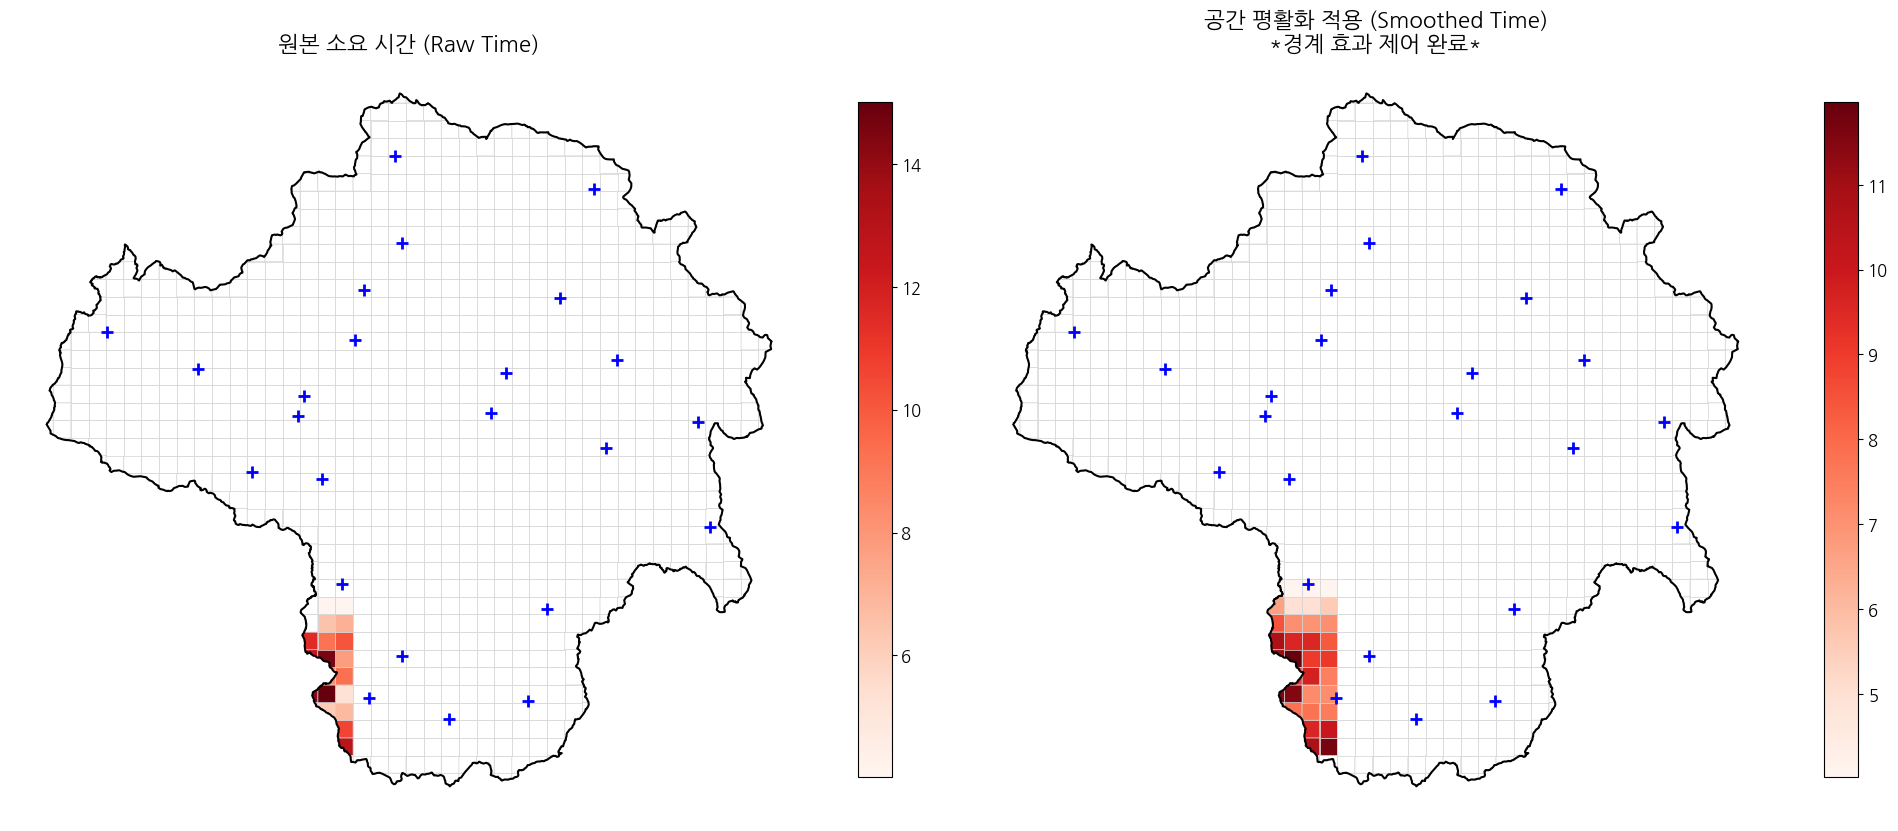


[📊 분석 완료! 저장된 결과 파일 미리보기]


,GRID_CD,raw_drive_time,smooth_drive_time
1,마마2264,6.583333,8.006250
2,마마2462,12.816667,10.758333
3,마마2463,10.600000,9.597222
4,마마2364,6.166667,7.834524
5,마마2464,6.800000,7.761667
6,마마2465,5.266667,7.178333
7,마마2365,15.000000,11.529762
8,마마2265,14.116667,11.550000
9,마마2267,12.483333,11.079762
10,마마2466,9.333333,9.741667


In [ ]:
# 1. 필요 라이브러리 및 폰트 설치 (최초 1회만 실행됨)
!pip install -q libpysal
!apt-get install -y fonts-nanum > /dev/null

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import requests
import numpy as np
import time
import warnings
import os
from libpysal.weights import KNN

# -----------------------------------------------------------
# 폰트 에러 완벽 해결 로직 (캐시 삭제 및 강제 인식)
# -----------------------------------------------------------
warnings.filterwarnings('ignore')
fe = fm.FontEntry(
    fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    name='NanumGothic'
)
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams.update({'font.size': 12, 'font.family': 'NanumGothic'})
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# ==============================================================
# 🚨 [세팅값] 데이터 경로 및 API 설정
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'
SHP_PATH = BASE_DIR + '_grid_border_grid_2025_grid_마마_grid_마마/grid_마마_1K.shp'
BORDER_PATH = BASE_DIR + '시군구/bnd_sigungu_37070_2025_2Q.shp'
CLINIC_PATH = BASE_DIR + '경상북도 영천시_보건지소및보건진료소현황(공공데이터포털,24).csv'
POP_ALL_PATH = BASE_DIR + '2024년_인구_마마_1K.csv'

# 카카오 모빌리티(내비) API 키
KAKAO_API_KEY = "a74e16d4b116fdd2c8afc6ffb3310250"

# 🌟 테스트 모드 설정 (True: 20개 격자 / False: 전체 스캔)
TEST_MODE = True
TEST_COUNT = 20

SAVE_CSV_PATH = BASE_DIR + '영천시_보건지소_차량접근성_Smoothing.csv'

# ==============================================================
print("🔄 [1/5] 데이터 로드 및 좌표계 세팅 (EPSG:5179)")
# ==============================================================
# 1. 영천시 경계선 및 격자판
try:
    sigungu_map = gpd.read_file(BORDER_PATH, encoding='utf-8')
except:
    sigungu_map = gpd.read_file(BORDER_PATH, encoding='cp949')
sigungu_map = sigungu_map.to_crs(epsg=5179)
yeongcheon_border = sigungu_map[sigungu_map['SIGUNGU_NM'].str.contains('영천', na=False)].copy()
if len(yeongcheon_border) == 0: yeongcheon_border = sigungu_map.copy()

try:
    grid_map = gpd.read_file(SHP_PATH, encoding='utf-8').set_crs(epsg=5179, allow_override=True)
except:
    grid_map = gpd.read_file(SHP_PATH, encoding='cp949').set_crs(epsg=5179, allow_override=True)
yeongcheon_grid = gpd.clip(grid_map, yeongcheon_border)
yeongcheon_grid['centroid'] = yeongcheon_grid.geometry.centroid
grid_col = yeongcheon_grid.columns[0]

# 2. 보건지소 데이터 (안전한 로드)
def load_csv_safe(path, header='infer', names=None):
    for enc in ['utf-8', 'cp949', 'euc-kr', 'utf-8-sig']:
        try:
            return pd.read_csv(path, encoding=enc, header=header, names=names)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"인코딩 실패: {path}")

df_clinic = load_csv_safe(CLINIC_PATH).dropna(subset=['위도', '경도'])
gdf_clinic = gpd.GeoDataFrame(df_clinic, geometry=gpd.points_from_xy(df_clinic['경도'], df_clinic['위도']), crs="EPSG:4326").to_crs(epsg=5179)


# ==============================================================
print("👥 [2/5] 대안 1: 인구수 0명인 '빈 격자' 배제 (Masking)")
# ==============================================================
df_pop_all = load_csv_safe(POP_ALL_PATH, header=None, names=['year', 'grid_id', 'code', 'count'])
df_total_pop = df_pop_all[df_pop_all['code'] == 'to_in_001'].copy()
df_total_pop['grid_id'] = df_total_pop['grid_id'].astype(str).str.strip()

final_map = yeongcheon_grid.merge(df_total_pop[['grid_id', 'count']], left_on=grid_col, right_on='grid_id', how='left')

# 사람이 없는 곳(NaN이거나 0)은 True로 마스킹
final_map['is_empty'] = final_map['count'].isna() | (final_map['count'] <= 0)

# 실제 분석할 격자만 추출 (테스트 시 앞부분 20개만)
inhabited_grids = final_map[~final_map['is_empty']].copy()
target_grids = inhabited_grids.head(TEST_COUNT).copy() if TEST_MODE else inhabited_grids.copy()

print(f"👉 API 호출 대상 격자 수: {len(target_grids)}개 (Test Mode: {TEST_MODE})")


# ==============================================================
print("🚗 [3/5] 각 격자별 최단 차량 이동 시간 계산 (카카오내비 API)")
# ==============================================================
def get_driving_time(orig_lon, orig_lat, dest_lon, dest_lat):
    url = "https://apis-navi.kakaomobility.com/v1/directions"
    headers = {"Authorization": f"KakaoAK {KAKAO_API_KEY}"}
    params = {"origin": f"{orig_lon},{orig_lat}", "destination": f"{dest_lon},{dest_lat}", "priority": "RECOMMEND"}
    try:
        res = requests.get(url, headers=headers, params=params)
        if res.status_code == 200:
            data = res.json()
            if data['routes'][0]['result_code'] == 0:
                return data['routes'][0]['summary']['duration'] / 60.0 # 분(min) 단위 반환
    except:
        pass
    return float('inf')

min_times = []
total_count = len(target_grids)

for idx, row in enumerate(target_grids.itertuples(), 1):
    centroid = row.centroid
    distances = gdf_clinic.geometry.distance(centroid)
    top3_clinics = gdf_clinic.loc[distances.nsmallest(3).index]

    orig_geom = gpd.GeoSeries([centroid], crs="EPSG:5179").to_crs(epsg=4326).iloc[0]
    orig_lon, orig_lat = orig_geom.x, orig_geom.y

    times = []
    for _, clinic_row in top3_clinics.iterrows():
        dest_geom = gpd.GeoSeries([clinic_row.geometry], crs="EPSG:5179").to_crs(epsg=4326).iloc[0]
        driving_time = get_driving_time(orig_lon, orig_lat, dest_geom.x, dest_geom.y)
        times.append(driving_time)
        time.sleep(0.05) # Rate Limit 방어

    best_time = min(times)
    min_times.append(best_time if best_time != float('inf') else np.nan)

    if idx % 5 == 0 or idx == total_count:
        print(f"   - {idx}/{total_count} 격자 API 연동 완료")

target_grids['raw_drive_time'] = min_times

# 전체 지도(final_map)에 계산된 원본 시간 병합 (계산 안 된 곳은 다 NaN)
final_map = final_map.merge(target_grids[[grid_col, 'raw_drive_time']], on=grid_col, how='left')


# ==============================================================
print("🌊 [4/5] 대안 2: 공간 평활화 (KNN 8이웃 + 자가 가중치 제어)")
# ==============================================================
# 🌟 경계 효과 해결: KNN 알고리즘으로 무조건 가장 가까운 이웃 8개를 찾아 스무딩
# 🌟 테스트 모드에서는 격자가 적어 이웃 8개를 찾을 수 없으므로, 격자 수에 맞춰 k값을 자동 조정합니다.
k_neighbors = min(8, len(final_map) - 1)
w = KNN.from_dataframe(final_map, k=k_neighbors)

smoothed_times = []
for i in range(len(final_map)):
    if final_map.iloc[i]['is_empty']:
        smoothed_times.append(np.nan)
        continue

    self_time = final_map.iloc[i]['raw_drive_time']
    neighbor_indices = w.neighbors[i]

    # 이웃 격자들의 원본 시간 추출
    neighbor_times = final_map.iloc[neighbor_indices]['raw_drive_time'].tolist()
    valid_neighbors = [t for t in neighbor_times if not np.isnan(t)]

    if len(valid_neighbors) > 0:
        neighbor_mean = np.nanmean(valid_neighbors)
        # 🌟 핵심 방어 로직: 자기 자신 원본 값 50% + 이웃 평균 50%
        if not np.isnan(self_time):
            smoothed_val = (self_time * 0.5) + (neighbor_mean * 0.5)
        else:
            smoothed_val = neighbor_mean # 원본이 NaN이면 이웃 평균으로 보간
    else:
        smoothed_val = self_time

    smoothed_times.append(smoothed_val)

final_map['smooth_drive_time'] = smoothed_times

# 최종 결과 저장 (사람이 사는 격자 721개 데이터만 추출)
save_df = final_map[~final_map['is_empty']].drop(columns=['geometry', 'centroid', 'is_empty'])
save_df.to_csv(SAVE_CSV_PATH, index=False, encoding='utf-8-sig')


# ==============================================================
print("✨ [5/5] 보건지소 차량 접근성 히트맵 (원본 vs 평활화 비교)")
# ==============================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# 1. 왼쪽: 원본 시간 (raw_drive_time)
final_map.plot(column='raw_drive_time', ax=axes[0], cmap='Reds', edgecolor='lightgray', linewidth=0.5,
               legend=True, legend_kwds={'shrink': 0.7}, missing_kwds={'color': 'white'})
yeongcheon_border.boundary.plot(ax=axes[0], color='black', linewidth=1.5)
gdf_clinic.plot(ax=axes[0], color='blue', marker='+', markersize=80, linewidth=2)
axes[0].set_title("원본 소요 시간 (Raw Time)", fontsize=16, fontweight='bold')
axes[0].axis('off')

# 2. 오른쪽: 평활화된 시간 (smooth_drive_time)
final_map.plot(column='smooth_drive_time', ax=axes[1], cmap='Reds', edgecolor='lightgray', linewidth=0.5,
               legend=True, legend_kwds={'shrink': 0.7}, missing_kwds={'color': 'white'})
yeongcheon_border.boundary.plot(ax=axes[1], color='black', linewidth=1.5)
gdf_clinic.plot(ax=axes[1], color='blue', marker='+', markersize=80, linewidth=2)
axes[1].set_title("공간 평활화 적용 (Smoothed Time)\n*경계 효과 제어 완료*", fontsize=16, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\n[📊 분석 완료! 저장된 결과 파일 미리보기]")
display(save_df[[grid_col, 'raw_drive_time', 'smooth_drive_time']].head(10))

In [3]:
import requests

def test_tmap_pedestrian(app_key, start_lon, start_lat, end_lon, end_lat):
    # Tmap 보행자 경로 탐색 API 엔드포인트
    url = "https://apis.openapi.sk.com/tmap/routes/pedestrian?version=1&format=json"

    headers = {
        "appKey": app_key
    }

    # API 요청 파라미터
    payload = {
        "startX": start_lon,
        "startY": start_lat,
        "endX": end_lon,
        "endY": end_lat,
        "reqCoordType": "WGS84GEO", # WGS84 (경도, 위도) 좌표계 사용
        "resCoordType": "EPSG3857",
        "startName": "출발지",        # 필수값 (임의의 문자열)
        "endName": "정류장"         # 필수값 (임의의 문자열)
    }

    try:
        res = requests.post(url, headers=headers, json=payload)
        data = res.json()

        # 총 소요 시간(초) 추출 및 분 단위 변환
        total_time_sec = data['features'][0]['properties']['totalTime']
        total_time_min = total_time_sec / 60.0

        # 총 거리(미터) 추출
        total_distance_m = data['features'][0]['properties']['totalDistance']

        print("✅ API 통신 성공!")
        print(f"🚶 예상 도보 소요 시간: {total_time_min:.1f}분")
        print(f"📏 예상 실제 도보 거리: {total_distance_m}m")

        return total_time_min

    except Exception as e:
        print("❌ 에러 발생!")
        print(f"상세 응답: {res.text}")
        return None

# 발급받은 API 키 입력
TMAP_KEY = 'RX4bh03eje6PXlD39zEhN3JOqevsa8w967go9XlP'

# 영천시 내 임의의 테스트 좌표 (경도, 위도 순서)
test_start_lon, test_start_lat = 128.9385, 35.9733  # 임의의 격자 중심점
test_end_lon, test_end_lat = 128.9330, 35.9700    # 임의의 버스 정류장

# 함수 실행
test_tmap_pedestrian(TMAP_KEY, test_start_lon, test_start_lat, test_end_lon, test_end_lat)

✅ API 통신 성공!
🚶 예상 도보 소요 시간: 12.2분
📏 예상 실제 도보 거리: 940m


12.15

🔄 [1/4] 지도 경계 및 격자판 세팅
👥 [2/4] 전체 인구 데이터 결합 및 '빈 격자' 필터링
✅ 영천시 총 격자 수: 1014개
👉 제외할 '빈 격자(인구 0명)': 293개
👉 실제 분석(API 호출) 대상: 721개
🚌 [3/4] 버스 정류장 데이터 로드 및 공간 데이터(Geo) 변환
✅ 영천시 내 버스 정류장 매핑 완료: 총 1669개
✨ [4/4] 최종 시각화 (격자 + 버스 정류장)


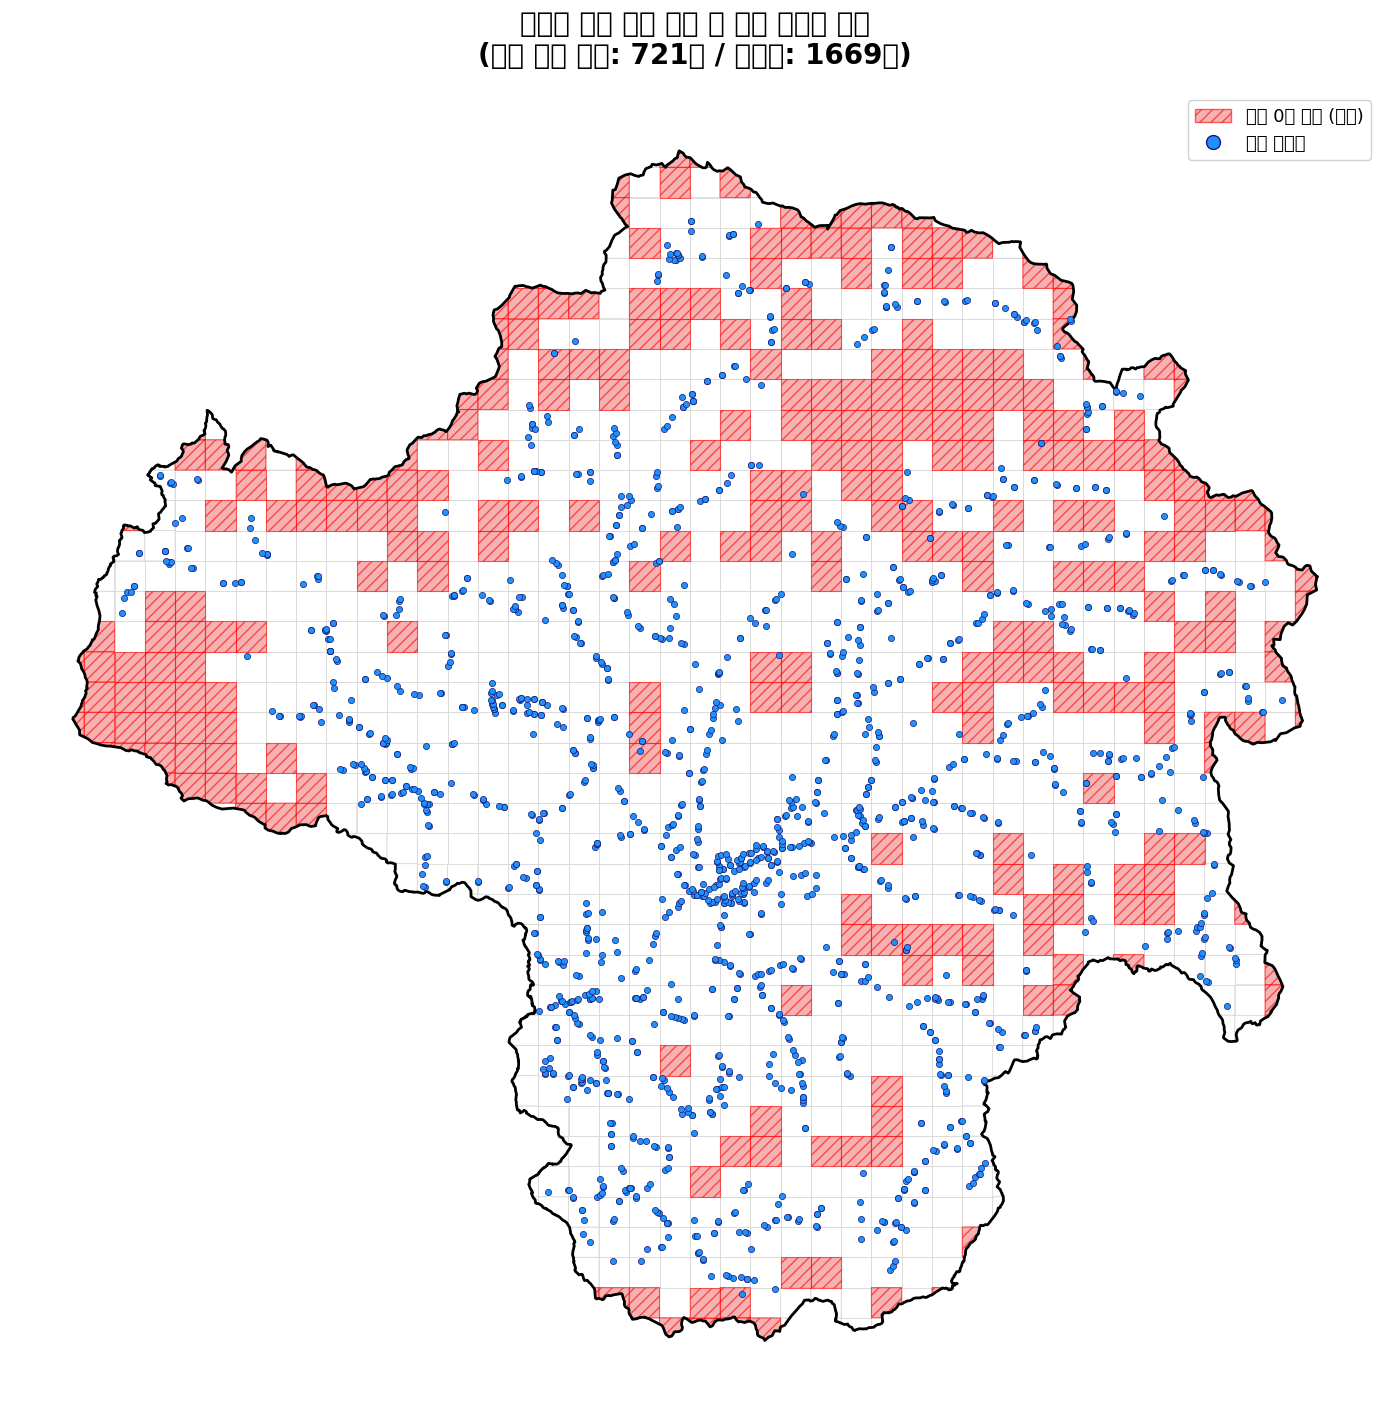

In [6]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# 경고창 무시 및 한글 폰트 설정
warnings.filterwarnings('ignore')
plt.rc('font', family='NanumBarunGothic')

# ==============================================================
# 🚨 [세팅값] 데이터 경로 설정
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

SHP_PATH = BASE_DIR + '_grid_border_grid_2025_grid_마마_grid_마마/grid_마마_1K.shp'
BORDER_PATH = BASE_DIR + '시군구/bnd_sigungu_37070_2025_2Q.shp'
POP_ALL_PATH = BASE_DIR + '2024년_인구_마마_1K.csv'

# 🌟 추가된 데이터: 버스 정류장
BUS_PATH = BASE_DIR + 'bus_final.csv'

# ==============================================================
print("🔄 [1/4] 지도 경계 및 격자판 세팅")
# ==============================================================
try:
    sigungu_map = gpd.read_file(BORDER_PATH, encoding='utf-8')
except:
    sigungu_map = gpd.read_file(BORDER_PATH, encoding='cp949')

sigungu_map = sigungu_map.to_crs(epsg=5179)
yeongcheon_border = sigungu_map[sigungu_map['SIGUNGU_NM'].str.contains('영천', na=False)].copy()
if len(yeongcheon_border) == 0: yeongcheon_border = sigungu_map.copy()

try:
    grid_map = gpd.read_file(SHP_PATH, encoding='utf-8').set_crs(epsg=5179, allow_override=True)
except:
    grid_map = gpd.read_file(SHP_PATH, encoding='cp949').set_crs(epsg=5179, allow_override=True)

yeongcheon_grid = gpd.clip(grid_map, yeongcheon_border)
grid_col = yeongcheon_grid.columns[0]
yeongcheon_grid[grid_col] = yeongcheon_grid[grid_col].astype(str).str.strip()


# ==============================================================
print("👥 [2/4] 전체 인구 데이터 결합 및 '빈 격자' 필터링")
# ==============================================================
try:
    df_pop_all = pd.read_csv(POP_ALL_PATH, header=None, names=['year', 'grid_id', 'code', 'count'], encoding='utf-8')
except:
    df_pop_all = pd.read_csv(POP_ALL_PATH, header=None, names=['year', 'grid_id', 'code', 'count'], encoding='cp949')

df_total_pop = df_pop_all[df_pop_all['code'] == 'to_in_001'].copy()
df_total_pop['grid_id'] = df_total_pop['grid_id'].astype(str).str.strip()

final_map = yeongcheon_grid.merge(df_total_pop[['grid_id', 'count']], left_on=grid_col, right_on='grid_id', how='left')
final_map['is_empty'] = final_map['count'].isna() | (final_map['count'] <= 0)

total_grids = len(final_map)
empty_grids = final_map['is_empty'].sum()
inhabited_grids = total_grids - empty_grids

print(f"✅ 영천시 총 격자 수: {total_grids}개")
print(f"👉 제외할 '빈 격자(인구 0명)': {empty_grids}개")
print(f"👉 실제 분석(API 호출) 대상: {inhabited_grids}개")


# ==============================================================
print("🚌 [3/4] 버스 정류장 데이터 로드 및 공간 데이터(Geo) 변환")
# ==============================================================
try:
    df_bus = pd.read_csv(BUS_PATH, encoding='utf-8')
except:
    df_bus = pd.read_csv(BUS_PATH, encoding='cp949')

# 위경도(lat, lon)를 점(Point) 형태의 공간 데이터로 변환 (기본 좌표계: EPSG:4326)
gdf_bus = gpd.GeoDataFrame(
    df_bus,
    geometry=gpd.points_from_xy(df_bus['lon'], df_bus['lat']),
    crs="EPSG:4326"
)

# 격자 지도와 동일한 좌표계(EPSG:5179)로 변환 (아주 중요!)
gdf_bus = gdf_bus.to_crs(epsg=5179)

# 영천시 경계 안쪽의 정류장만 깔끔하게 자르기 (이상치 방지)
gdf_bus = gpd.clip(gdf_bus, yeongcheon_border)
print(f"✅ 영천시 내 버스 정류장 매핑 완료: 총 {len(gdf_bus)}개")


# ==============================================================
print("✨ [4/4] 최종 시각화 (격자 + 버스 정류장)")
# ==============================================================
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

# 1. 기본 영천시 배경 (사람이 사는 곳 = 하얀색)
final_map[~final_map['is_empty']].plot(ax=ax, color='white', edgecolor='lightgray', linewidth=0.5)

# 2. 🚨 배제 대상 빈 격자 칠하기 (붉은색 빗금 패턴)
final_map[final_map['is_empty']].plot(ax=ax, color='lightcoral', edgecolor='red', linewidth=0.8, alpha=0.6, hatch='///')

# 3. 영천시 외곽선 강조
yeongcheon_border.boundary.plot(ax=ax, color='black', linewidth=2)

# 4. 🚌 버스 정류장 포인트 찍기 (파란색 원)
gdf_bus.plot(ax=ax, color='dodgerblue', markersize=20, edgecolor='midnightblue', linewidth=0.5, zorder=5)

ax.set_title(f"영천시 인구 분포 격자 및 버스 정류장 현황\n(분석 대상 격자: {inhabited_grids}개 / 정류장: {len(gdf_bus)}개)", fontsize=20, fontweight='bold', pad=20)
ax.axis('off')

# 범례 추가 (패턴 + 마커 종합)
red_patch = mpatches.Patch(facecolor='lightcoral', edgecolor='red', hatch='///', alpha=0.6, label='인구 0명 격자 (제외)')
blue_dot = mlines.Line2D([], [], color='white', marker='o', markerfacecolor='dodgerblue', markeredgecolor='midnightblue', markersize=10, label='버스 정류장')

ax.legend(handles=[red_patch, blue_dot], fontsize=13, loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors

# ==============================================================
# 📏 [1/3] 공간 좌표 추출 (격자 중심점 vs 버스 정류장)
# ==============================================================
print("🔄 격자 중심점과 정류장 좌표를 추출합니다...")

# 1. 분석 대상 격자(721개)의 중심점(Centroid) 도출
active_grids = final_map[~final_map['is_empty']].copy()
active_grids['centroid'] = active_grids.geometry.centroid

# 2. 중심점의 X, Y 좌표를 numpy 배열로 추출 (학습용 데이터 형태)
grid_coords = np.array([(pt.x, pt.y) for pt in active_grids['centroid']])

# 3. 버스 정류장의 X, Y 좌표 추출
bus_coords = np.array([(pt.x, pt.y) for pt in gdf_bus.geometry])

# ==============================================================
# 🤖 [2/3] KNN 알고리즘으로 가장 가까운 Top 3 정류장 찾기
# ==============================================================
print("🤖 유클리드 거리 기반 Top 3 정류장 탐색 중...")

# n_neighbors=3 (가장 가까운 3개), metric='euclidean' (직선거리) 설정
knn = NearestNeighbors(n_neighbors=3, metric='euclidean')

# 버스 정류장 좌표를 알고리즘에 학습(Fit)
knn.fit(bus_coords)

# 각 격자 중심점에서 가장 가까운 3개 정류장의 '거리(distances)'와 '인덱스(indices)' 반환
# EPSG:5179 좌표계이므로 계산된 거리의 단위는 '미터(m)'입니다.
distances, indices = knn.kneighbors(grid_coords)

# ==============================================================
# 💾 [3/3] 결과 정리 및 CSV 파일 저장
# ==============================================================
print("💾 분석 결과를 데이터프레임으로 변환하여 저장합니다...")

result_data = []

# 반복문을 통해 각 격자별 1, 2, 3위 정류장 정보 매핑
for i, grid_idx in enumerate(active_grids.index):
    grid_id = active_grids.loc[grid_idx, grid_col] # 격자 번호

    # 1, 2, 3위 정류장의 인덱스와 거리(소수점 1자리까지)
    idx_1, idx_2, idx_3 = indices[i]
    dist_1, dist_2, dist_3 = distances[i]

    # 결과 딕셔너리 생성 (버스 정류장 원본 데이터의 Bus_Stop, Bus_StopID 활용)
    row = {
        'grid_id': grid_id,

        '1st_bus_stop': gdf_bus.iloc[idx_1]['Bus_Stop'],
        '1st_stop_id': gdf_bus.iloc[idx_1]['Bus_StopID'],
        '1st_dist_m': round(dist_1, 1),

        '2nd_bus_stop': gdf_bus.iloc[idx_2]['Bus_Stop'],
        '2nd_stop_id': gdf_bus.iloc[idx_2]['Bus_StopID'],
        '2nd_dist_m': round(dist_2, 1),

        '3rd_bus_stop': gdf_bus.iloc[idx_3]['Bus_Stop'],
        '3rd_stop_id': gdf_bus.iloc[idx_3]['Bus_StopID'],
        '3rd_dist_m': round(dist_3, 1)
    }
    result_data.append(row)

# 데이터프레임 변환
df_top3_bus = pd.DataFrame(result_data)

# CSV 파일로 저장
csv_save_path = BASE_DIR + 'grid_top3_bus_stops.csv'
df_top3_bus.to_csv(csv_save_path, index=False, encoding='utf-8-sig')

print(f"\n✅ 성공! 721개 격자의 Top 3 버스 정류장 거리가 계산되었습니다.")
print(f"📁 저장 위치: {csv_save_path}")

# 데이터 미리보기
display(df_top3_bus.head())

🔄 격자 중심점과 정류장 좌표를 추출합니다...
🤖 유클리드 거리 기반 Top 3 정류장 탐색 중...
💾 분석 결과를 데이터프레임으로 변환하여 저장합니다...

✅ 성공! 721개 격자의 Top 3 버스 정류장 거리가 계산되었습니다.
📁 저장 위치: /content/drive/MyDrive/영천의미학/grid_top3_bus_stops.csv


,grid_id,1st_bus_stop,1st_stop_id,1st_dist_m,2nd_bus_stop,2nd_stop_id,2nd_dist_m,3rd_bus_stop,3rd_stop_id,3rd_dist_m
0,마마2264,사리2리종점,570698.0,471.4,사리2리(대창방면),570699.0,1095.4,사리2리(사리방면),570697.0,1111.8
1,마마2462,구지리,570714.0,867.6,장곡리(사리방면),570705.0,892.1,장곡리마을회관,570704.0,1196.5
2,마마2463,장곡리(사리방면),570705.0,131.9,장곡리마을회관,570704.0,286.3,장곡리(장곡방면),570703.0,732.0
3,마마2364,사리2리종점,570698.0,545.4,장곡마을입구(장곡방면),570701.0,606.7,장곡마을입구(사리방면),570707.0,630.9
4,마마2464,장곡공장(사리방면),570706.0,68.4,장곡공장(장곡방면),570702.0,68.4,장곡리(장곡방면),570703.0,260.3


In [8]:
import pandas as pd
import requests
import time
from tqdm import tqdm # 진행률을 보기 위한 라이브러리

# ==============================================================
# 🚨 [세팅값] 경로 및 API 키 설정
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

# 이전 단계에서 만든 파일 불러오기
INPUT_CSV = BASE_DIR + 'grid_top3_bus_stops.csv'

# 발급받으신 Tmap API 키 입력
TMAP_KEY = 'RX4bh03eje6PXlD39zEhN3JOqevsa8w967go9XlP'

# ==============================================================
# 🔄 [1/3] 데이터 로드 및 초기화
# ==============================================================
print("🔄 1단계: 버스 정류장 거리 데이터를 불러옵니다...")
df_bus_top3 = pd.read_csv(INPUT_CSV, encoding='utf-8-sig')

# 위경도 데이터가 필요하므로 격자 중심점과 버스 정류장 데이터를 다시 결합해야 합니다.
# (이전 코드에서 실행된 active_grids와 gdf_bus가 메모리에 있다고 가정합니다.)
# 만약 초기화되었다면, 중심점의 X(lon), Y(lat) 좌표와 버스 정류장의 X, Y를 다시 매핑해야 합니다.

# [안전한 매핑을 위한 보조 코드]
# 1. 격자 중심점 위경도 변환 (EPSG:5179 -> EPSG:4326(Tmap용))
active_grids_4326 = active_grids.to_crs(epsg=4326)
grid_coords_map = {row[grid_col]: (row.geometry.centroid.x, row.geometry.centroid.y) for idx, row in active_grids_4326.iterrows()}

# 2. 버스 정류장 위경도 딕셔너리 (Bus_StopID 기준)
bus_coords_map = {row['Bus_StopID']: (row.geometry.x, row.geometry.y) for idx, row in gdf_bus.to_crs(epsg=4326).iterrows()}


# 새로운 컬럼 추가 (결과 저장용)
df_bus_top3['tmap_success'] = 'N'  # Tmap 호출 성공 여부 (Y/N)
df_bus_top3['walk_time_min'] = None # 도보 소요 시간(분)
df_bus_top3['walk_dist_m'] = None   # 실제 도보 거리(m)

# ==============================================================
# 🚶 [2/3] Tmap API 호출 (2순위 정류장 타겟)
# ==============================================================
print("🚶 2단계: Tmap 보행자 경로 API를 호출하여 2순위 정류장까지의 거리를 계산합니다...")
print(f"총 분석 대상: {len(df_bus_top3)}개 격자")

# Tmap 보행자 경로 탐색 API 엔드포인트
url = "https://apis.openapi.sk.com/tmap/routes/pedestrian?version=1&format=json"
headers = {"appKey": TMAP_KEY}

# 진행률 표시줄(tqdm) 사용
for index, row in tqdm(df_bus_top3.iterrows(), total=df_bus_top3.shape[0], desc="Tmap API 호출 중"):
    grid_id = str(row['grid_id'])
    bus_id_2nd = row['2nd_stop_id'] # 타겟: 2번째 정류장

    # 시작점(격자)과 도착점(정류장)의 위경도(EPSG:4326) 가져오기
    if grid_id in grid_coords_map and bus_id_2nd in bus_coords_map:
        start_lon, start_lat = grid_coords_map[grid_id]
        end_lon, end_lat = bus_coords_map[bus_id_2nd]

        payload = {
            "startX": start_lon, "startY": start_lat,
            "endX": end_lon, "endY": end_lat,
            "reqCoordType": "WGS84GEO", "resCoordType": "EPSG3857",
            "startName": "격자중심", "endName": "정류장"
        }

        try:
            res = requests.post(url, headers=headers, json=payload, timeout=5)

            # API 정상 응답 시
            if res.status_code == 200:
                data = res.json()
                total_time_sec = data['features'][0]['properties']['totalTime']
                total_distance_m = data['features'][0]['properties']['totalDistance']

                # 데이터 기록
                df_bus_top3.at[index, 'tmap_success'] = 'Y'
                df_bus_top3.at[index, 'walk_time_min'] = round(total_time_sec / 60.0, 1)
                df_bus_top3.at[index, 'walk_dist_m'] = total_distance_m
            else:
                # API는 응답했으나 길찾기 실패 (ex: 산속, 10km 이상 이격 등)
                df_bus_top3.at[index, 'tmap_success'] = 'N_PathError'

        except Exception as e:
            # 타임아웃, 네트워크 오류 등
            df_bus_top3.at[index, 'tmap_success'] = 'N_NetError'

    else:
        # 좌표 맵핑 실패 시
        df_bus_top3.at[index, 'tmap_success'] = 'N_CoordError'

    # API 서버에 무리를 주지 않기 위해 0.1초 휴식 (초당 10건 호출)
    time.sleep(0.1)

# ==============================================================
# 💾 [3/3] 결과 저장 및 요약
# ==============================================================
print("\n💾 3단계: 분석 결과를 저장합니다...")

csv_save_path = BASE_DIR + 'tmap_walking_result_2nd_stop.csv'
df_bus_top3.to_csv(csv_save_path, index=False, encoding='utf-8-sig')

# 결과 요약
success_cnt = (df_bus_top3['tmap_success'] == 'Y').sum()
fail_cnt = len(df_bus_top3) - success_cnt

print("========================================")
print(f"✅ 분석 완료! 총 {len(df_bus_top3)}건 중")
print(f"🟢 길찾기 성공(Y): {success_cnt}건")
print(f"🔴 길찾기 실패(N): {fail_cnt}건 (추후 보정 필요)")
print(f"📁 저장 위치: {csv_save_path}")
print("========================================")

# 실패한 데이터만 살짝 보여주기
if fail_cnt > 0:
    print("\n[참고] 길찾기 실패한 데이터 일부:")
    display(df_bus_top3[df_bus_top3['tmap_success'] != 'Y'][['grid_id', '2nd_bus_stop', 'tmap_success']].head())

🔄 1단계: 버스 정류장 거리 데이터를 불러옵니다...
🚶 2단계: Tmap 보행자 경로 API를 호출하여 2순위 정류장까지의 거리를 계산합니다...
총 분석 대상: 721개 격자


Tmap API 호출 중: 100%|██████████| 721/721 [08:09<00:00,  1.47it/s]


💾 3단계: 분석 결과를 저장합니다...
✅ 분석 완료! 총 721건 중
🟢 길찾기 성공(Y): 91건
🔴 길찾기 실패(N): 630건 (추후 보정 필요)
📁 저장 위치: /content/drive/MyDrive/영천의미학/tmap_walking_result_2nd_stop.csv

[참고] 길찾기 실패한 데이터 일부:


,grid_id,2nd_bus_stop,tmap_success
0,마마2264,사리2리(대창방면),N_PathError
1,마마2462,장곡리(사리방면),N_PathError
2,마마2463,장곡리마을회관,N_PathError
3,마마2364,장곡마을입구(장곡방면),N_PathError
4,마마2464,장곡공장(장곡방면),N_PathError


In [9]:
import pandas as pd
import requests
import time
from tqdm import tqdm

# ==============================================================
# 🚨 [세팅값] 경로 및 API 키 설정
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

# 이전에 만든 유클리드 거리 Top 3 파일 불러오기
INPUT_CSV = BASE_DIR + 'grid_top3_bus_stops.csv'
TMAP_KEY = 'RX4bh03eje6PXlD39zEhN3 파이썬 키 입력 오류 방지용 가짜 키가 아닌 발급받으신 키 확인' # 기존 키: 'RX4bh03eje6PXlD39zEhN3JOqevsa8w967go9XlP'
TMAP_KEY = 'RX4bh03eje6PXlD39zEhN3JOqevsa8w967go9XlP'

print("🔄 1단계: 버스 정류장 거리 데이터를 불러옵니다...")
df_bus_top3 = pd.read_csv(INPUT_CSV, encoding='utf-8-sig')

# [보조 코드] 위경도 매핑 (이전 셀들이 실행된 상태여야 합니다)
try:
    active_grids_4326 = active_grids.to_crs(epsg=4326)
    grid_coords_map = {row[grid_col]: (row.geometry.centroid.x, row.geometry.centroid.y) for idx, row in active_grids_4326.iterrows()}
    bus_coords_map = {row['Bus_StopID']: (row.geometry.x, row.geometry.y) for idx, row in gdf_bus.to_crs(epsg=4326).iterrows()}
except NameError:
    print("⚠️ 오류: 메모리에 active_grids나 gdf_bus가 없습니다. 이전 셀들을 먼저 실행해 주세요!")

# ==============================================================
# 🛠️ [2/4] 결과를 저장할 빈 컬럼 생성 (1st, 2nd, 3rd 모두 준비)
# ==============================================================
ranks = ['1st', '2nd', '3rd']
for rank in ranks:
    df_bus_top3[f'{rank}_tmap_success'] = 'N'  # 성공 여부 플래그
    df_bus_top3[f'{rank}_walk_time_min'] = None # 도보 소요 시간(분)
    df_bus_top3[f'{rank}_walk_dist_m'] = None   # 실제 도보 거리(m)

# ==============================================================
# 🚶 [3/4] Tmap API 연속 호출 (1, 2, 3순위 순차 탐색)
# ==============================================================
print(f"🚶 2단계: 총 {len(df_bus_top3)}개 격자에 대해 1~3순위 정류장 도보 경로를 탐색합니다.")
print("   (예상 소요 시간: 약 4~5분)")

url = "https://apis.openapi.sk.com/tmap/routes/pedestrian?version=1&format=json"
headers = {"appKey": TMAP_KEY}

for index, row in tqdm(df_bus_top3.iterrows(), total=df_bus_top3.shape[0], desc="Tmap 1~3순위 경로 탐색 중"):
    grid_id = str(row['grid_id'])

    if grid_id in grid_coords_map:
        start_lon, start_lat = grid_coords_map[grid_id]

        # 1st, 2nd, 3rd 순서대로 각각 API 호출
        for rank in ranks:
            bus_id = row[f'{rank}_stop_id']

            if pd.notna(bus_id) and bus_id in bus_coords_map:
                end_lon, end_lat = bus_coords_map[bus_id]

                payload = {
                    "startX": start_lon, "startY": start_lat,
                    "endX": end_lon, "endY": end_lat,
                    "reqCoordType": "WGS84GEO", "resCoordType": "EPSG3857",
                    "startName": "격자중심", "endName": "정류장"
                }

                try:
                    res = requests.post(url, headers=headers, json=payload, timeout=5)

                    if res.status_code == 200:
                        data = res.json()
                        total_time_sec = data['features'][0]['properties']['totalTime']
                        total_distance_m = data['features'][0]['properties']['totalDistance']

                        df_bus_top3.at[index, f'{rank}_tmap_success'] = 'Y'
                        df_bus_top3.at[index, f'{rank}_walk_time_min'] = round(total_time_sec / 60.0, 1)
                        df_bus_top3.at[index, f'{rank}_walk_dist_m'] = total_distance_m
                    else:
                        df_bus_top3.at[index, f'{rank}_tmap_success'] = 'N_PathError'
                except Exception as e:
                    df_bus_top3.at[index, f'{rank}_tmap_success'] = 'N_NetError'

                # API 서버 무리 방지를 위해 한 번 호출할 때마다 0.1초 휴식
                time.sleep(0.1)
            else:
                df_bus_top3.at[index, f'{rank}_tmap_success'] = 'N_CoordError'
    else:
        for rank in ranks:
            df_bus_top3.at[index, f'{rank}_tmap_success'] = 'N_GridCoordError'

# ==============================================================
# 💾 [4/4] 마스터 결과 저장 및 통계 요약
# ==============================================================
print("\n💾 3단계: 분석 결과를 저장합니다...")

csv_save_path = BASE_DIR + 'tmap_walking_result_ALL_top3.csv'
df_bus_top3.to_csv(csv_save_path, index=False, encoding='utf-8-sig')

print("========================================")
print(f"✅ 통합 분석 완료! (저장 위치: {csv_save_path})")
for rank in ranks:
    success_cnt = (df_bus_top3[f'{rank}_tmap_success'] == 'Y').sum()
    fail_cnt = len(df_bus_top3) - success_cnt
    print(f"▶ {rank} 정류장 - 성공: {success_cnt}건 / 실패: {fail_cnt}건")
print("========================================")

display(df_bus_top3[['grid_id', '1st_tmap_success', '2nd_tmap_success', '3rd_tmap_success']].head())

🔄 1단계: 버스 정류장 거리 데이터를 불러옵니다...
🚶 2단계: 총 721개 격자에 대해 1~3순위 정류장 도보 경로를 탐색합니다.
   (예상 소요 시간: 약 4~5분)


Tmap 1~3순위 경로 탐색 중: 100%|██████████| 721/721 [22:38<00:00,  1.88s/it]


💾 3단계: 분석 결과를 저장합니다...
✅ 통합 분석 완료! (저장 위치: /content/drive/MyDrive/영천의미학/tmap_walking_result_ALL_top3.csv)
▶ 1st 정류장 - 성공: 13건 / 실패: 708건
▶ 2nd 정류장 - 성공: 11건 / 실패: 710건
▶ 3rd 정류장 - 성공: 13건 / 실패: 708건


,grid_id,1st_tmap_success,2nd_tmap_success,3rd_tmap_success
0,마마2264,Y,N_PathError,N_PathError
1,마마2462,N_PathError,N_PathError,N_PathError
2,마마2463,N_PathError,N_PathError,N_PathError
3,마마2364,Y,N_PathError,N_PathError
4,마마2464,N_PathError,N_PathError,N_PathError


In [11]:
import pandas as pd
import requests
import time
from tqdm import tqdm

# ==============================================================
# 🚨 [세팅값] 경로 및 API 키 설정
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

# 이전에 만든 유클리드 거리 Top 3 파일 불러오기
INPUT_CSV = BASE_DIR + 'grid_top3_bus_stops.csv'

# 발급받으신 Tmap API 키 입력
TMAP_KEY = '4onMTM0nhC7vUn70Bafux23SEZMJ8Gz2aiaXs0ZW'

# ==============================================================
# 🔄 [1/3] 데이터 로드 및 위경도 맵핑
# ==============================================================
print("🔄 1단계: 버스 정류장 거리 데이터를 불러옵니다...")
df_bus_top3 = pd.read_csv(INPUT_CSV, encoding='utf-8-sig')

# [보조 코드] 격자와 정류장의 위경도(EPSG:4326) 맵핑
# (이전 셀에서 실행된 active_grids, gdf_bus 데이터프레임이 메모리에 있어야 합니다.)
try:
    active_grids_4326 = active_grids.to_crs(epsg=4326)
    grid_coords_map = {row[grid_col]: (row.geometry.centroid.x, row.geometry.centroid.y) for idx, row in active_grids_4326.iterrows()}
    bus_coords_map = {row['Bus_StopID']: (row.geometry.x, row.geometry.y) for idx, row in gdf_bus.to_crs(epsg=4326).iterrows()}
except NameError:
    print("⚠️ 오류: 메모리에 active_grids나 gdf_bus가 없습니다. 지도 시각화 셀을 먼저 한번 실행해 주세요!")

# 결과를 저장할 새로운 컬럼 생성
df_bus_top3['tmap_success'] = 'N'  # 성공 여부 (Y/N/Error)
df_bus_top3['walk_time_min'] = None # 도보 소요 시간(분)
df_bus_top3['walk_dist_m'] = None   # 실제 도보 거리(m)

# ==============================================================
# 🚶 [2/3] Tmap API 호출 (🌟 1순위 정류장 타겟 🌟)
# ==============================================================
print("🚶 2단계: Tmap 보행자 경로 API를 호출하여 가장 가까운(1순위) 정류장까지 거리를 계산합니다...")
print(f"총 분석 대상: {len(df_bus_top3)}개 격자")

url = "https://apis.openapi.sk.com/tmap/routes/pedestrian?version=1&format=json"
headers = {"appKey": TMAP_KEY}

for index, row in tqdm(df_bus_top3.iterrows(), total=df_bus_top3.shape[0], desc="Tmap API 1순위 탐색 중"):
    grid_id = str(row['grid_id'])

    # 🌟 타겟을 1번째 정류장으로 설정 🌟
    bus_id_1st = row['1st_stop_id']

    if grid_id in grid_coords_map and pd.notna(bus_id_1st) and bus_id_1st in bus_coords_map:
        start_lon, start_lat = grid_coords_map[grid_id]
        end_lon, end_lat = bus_coords_map[bus_id_1st]

        payload = {
            "startX": start_lon, "startY": start_lat,
            "endX": end_lon, "endY": end_lat,
            "reqCoordType": "WGS84GEO", "resCoordType": "EPSG3857",
            "startName": "격자중심", "endName": "1순위정류장"
        }

        try:
            # timeout을 5초로 주어 무한 대기 방지
            res = requests.post(url, headers=headers, json=payload, timeout=5)

            if res.status_code == 200:
                data = res.json()
                total_time_sec = data['features'][0]['properties']['totalTime']
                total_distance_m = data['features'][0]['properties']['totalDistance']

                df_bus_top3.at[index, 'tmap_success'] = 'Y'
                df_bus_top3.at[index, 'walk_time_min'] = round(total_time_sec / 60.0, 1)
                df_bus_top3.at[index, 'walk_dist_m'] = total_distance_m
            else:
                # 길이 끊겼거나 너무 먼 경우 (산 속 등)
                df_bus_top3.at[index, 'tmap_success'] = 'N_PathError'

        except Exception as e:
            df_bus_top3.at[index, 'tmap_success'] = 'N_NetError'

    else:
        df_bus_top3.at[index, 'tmap_success'] = 'N_CoordError'

    # SK 서버 차단 방지 (초당 10번 이하 호출 유지)
    time.sleep(0.1)

# ==============================================================
# 💾 [3/3] 결과 저장 및 요약
# ==============================================================
print("\n💾 3단계: 분석 결과를 저장합니다...")

# 파일명도 1순위 타겟임을 알 수 있게 변경
csv_save_path = BASE_DIR + 'tmap_walking_result_1st_stop.csv'
df_bus_top3.to_csv(csv_save_path, index=False, encoding='utf-8-sig')

# 결과 통계
success_cnt = (df_bus_top3['tmap_success'] == 'Y').sum()
fail_cnt = len(df_bus_top3) - success_cnt

print("========================================")
print(f"✅ 1순위 정류장 탐색 완료! (총 {len(df_bus_top3)}건)")
print(f"🟢 길찾기 성공(Y): {success_cnt}건")
print(f"🔴 길찾기 실패(N): {fail_cnt}건 (추후 보정 필요)")
print(f"📁 저장 위치: {csv_save_path}")
print("========================================")

display(df_bus_top3[['grid_id', '1st_bus_stop', '1st_dist_m', 'tmap_success', 'walk_time_min', 'walk_dist_m']].head(10))

🔄 1단계: 버스 정류장 거리 데이터를 불러옵니다...
🚶 2단계: Tmap 보행자 경로 API를 호출하여 가장 가까운(1순위) 정류장까지 거리를 계산합니다...
총 분석 대상: 721개 격자


Tmap API 1순위 탐색 중: 100%|██████████| 721/721 [08:07<00:00,  1.48it/s]


💾 3단계: 분석 결과를 저장합니다...
✅ 1순위 정류장 탐색 완료! (총 721건)
🟢 길찾기 성공(Y): 97건
🔴 길찾기 실패(N): 624건 (추후 보정 필요)
📁 저장 위치: /content/drive/MyDrive/영천의미학/tmap_walking_result_1st_stop.csv


,grid_id,1st_bus_stop,1st_dist_m,tmap_success,walk_time_min,walk_dist_m
0,마마2264,사리2리종점,471.4,Y,0.9,71
1,마마2462,구지리,867.6,N_PathError,None,None
2,마마2463,장곡리(사리방면),131.9,N_PathError,None,None
3,마마2364,사리2리종점,545.4,Y,29.7,2278
4,마마2464,장곡공장(사리방면),68.4,N_PathError,None,None
5,마마2465,사리1리마을회관,528.1,N_PathError,None,None
6,마마2365,사리2리종점,375.3,Y,25.7,1982
7,마마2265,사리2리종점,500.2,Y,15.0,1157
8,마마2267,남성마을,1283.4,N_PathError,None,None
9,마마2466,포척(금호방면),898.2,N_PathError,None,None


In [5]:
import pandas as pd
import numpy as np

# ==============================================================
# 🚨 [세팅값] 데이터 경로 설정
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

file1_path = BASE_DIR + 'tmap_walking_result_1st_stop.csv'
file2_path = BASE_DIR + 'tmap_walking_result_2nd_stop.csv'
file3_path = BASE_DIR + 'tmap_walking_result_3st_stop.csv' # 파일명 3st_stop 오타 그대로 유지

print("🔄 1단계: 1, 2, 3순위 데이터를 모두 불러옵니다...")
df1 = pd.read_csv(file1_path, encoding='utf-8-sig')
df2 = pd.read_csv(file2_path, encoding='utf-8-sig')
df3 = pd.read_csv(file3_path, encoding='utf-8-sig')

# ==============================================================
# 🛠️ [2/4] 데이터 병합을 위한 전처리 (컬럼명 및 데이터 구조 통일)
# ==============================================================
# 기준이 되는 기본 정보는 df1에서 추출
base_cols = ['grid_id', '1st_bus_stop', '1st_stop_id', '1st_dist_m',
             '2nd_bus_stop', '2nd_stop_id', '2nd_dist_m',
             '3rd_bus_stop', '3rd_stop_id', '3rd_dist_m']
df_base = df1[base_cols].copy()

# [1순위 전처리]
res1 = df1[['grid_id', 'tmap_success', 'walk_time_min', 'walk_dist_m']].rename(
    columns={'tmap_success': '1st_success', 'walk_time_min': '1st_time', 'walk_dist_m': '1st_walk_dist'})

# [2순위 전처리]
res2 = df2[['grid_id', 'tmap_success', 'walk_time_min', 'walk_dist_m']].rename(
    columns={'tmap_success': '2nd_success', 'walk_time_min': '2nd_time', 'walk_dist_m': '2nd_walk_dist'})

# 🚨 [3순위 전처리 - 팀원 데이터 구조에 맞게 수정됨] 🚨
# 팀원 데이터는 컬럼명이 '3rd_tmap_...' 으로 되어 있음
res3 = df3[['grid_id', '3rd_tmap_success', '3rd_tmap_time_min', '3rd_tmap_dist_m']].copy()

# 팀원 데이터의 성공 여부가 True/False 일 수 있으므로 'Y' / 'N' 으로 강제 통일
res3['3rd_tmap_success'] = res3['3rd_tmap_success'].apply(lambda x: 'Y' if str(x).strip().lower() in ['true', 'y', '1'] else 'N')

res3 = res3.rename(columns={
    '3rd_tmap_success': '3rd_success',
    '3rd_tmap_time_min': '3rd_time',
    '3rd_tmap_dist_m': '3rd_walk_dist'
})

# grid_id를 기준으로 모든 결과 하나로 합치기
df_merged = df_base.merge(res1, on='grid_id').merge(res2, on='grid_id').merge(res3, on='grid_id')

# ==============================================================
# 🔍 [3/4] 성공 여부에 따른 격자 분류
# ==============================================================
print("🔍 2단계: 성공 여부에 따라 데이터를 3가지 그룹으로 분류합니다...")

# 격자별로 길찾기 성공('Y')한 개수 카운트 (0~3개)
df_merged['success_count'] = (df_merged['1st_success'] == 'Y').astype(int) + \
                             (df_merged['2nd_success'] == 'Y').astype(int) + \
                             (df_merged['3rd_success'] == 'Y').astype(int)

# --- [추출 1] 3개 모두 성공한 격자 (최소값 도출) ---
df_all_success = df_merged[df_merged['success_count'] == 3].copy()

def get_min_walking_info(row):
    dists = [row['1st_walk_dist'], row['2nd_walk_dist'], row['3rd_walk_dist']]
    times = [row['1st_time'], row['2nd_time'], row['3rd_time']]
    min_idx = np.argmin(dists) # 가장 짧은 거리의 인덱스(0, 1, 2) 반환
    return pd.Series([dists[min_idx], times[min_idx], f"{min_idx+1}순위"])

if not df_all_success.empty:
    df_all_success[['final_min_dist_m', 'final_min_time_min', 'selected_target']] = df_all_success.apply(get_min_walking_info, axis=1)

# --- [추출 2] 우회계수 적용 대상 격자 ---
# (3개 모두 성공한 격자가 아닌 나머지 전부 = 하나라도 API 값이 없는 격자)
df_need_detour = df_merged[df_merged['success_count'] < 3].copy()

# --- [추출 3] 부분 성공 격자 ---
# (3개 중 1~2개는 API 값을 받아온 격자. 우회계수 모델링 시 '참고자료'로 활용)
df_partial_success = df_merged[(df_merged['success_count'] == 1) | (df_merged['success_count'] == 2)].copy()

# ==============================================================
# 💾 [4/4] 3가지 CSV 파일 추출
# ==============================================================
print("💾 3단계: 분류된 데이터를 CSV 파일로 저장합니다...")

path_all_success = BASE_DIR + '1_all_3_success_min_dist.csv'
path_need_detour = BASE_DIR + '2_need_detour_coefficient.csv'
path_partial_success = BASE_DIR + '3_partial_success_reference.csv'

df_all_success.to_csv(path_all_success, index=False, encoding='utf-8-sig')
df_need_detour.to_csv(path_need_detour, index=False, encoding='utf-8-sig')
df_partial_success.to_csv(path_partial_success, index=False, encoding='utf-8-sig')

print("========================================")
print(f"✅ 데이터 분류 및 저장 완벽하게 성공!")
print(f"🟢 1. 3개 모두 성공 (최소값 적용): {len(df_all_success)}건")
print(f"🔴 2. 하나라도 실패 (우회계수 적용 대상): {len(df_need_detour)}건")
print(f"🟡 3. 부분 성공 (API 값이 1~2개 존재): {len(df_partial_success)}건")
print("========================================")

🔄 1단계: 1, 2, 3순위 데이터를 모두 불러옵니다...
🔍 2단계: 성공 여부에 따라 데이터를 3가지 그룹으로 분류합니다...
💾 3단계: 분류된 데이터를 CSV 파일로 저장합니다...
✅ 데이터 분류 및 저장 완벽하게 성공!
🟢 1. 3개 모두 성공 (최소값 적용): 79건
🔴 2. 하나라도 실패 (우회계수 적용 대상): 642건
🟡 3. 부분 성공 (API 값이 1~2개 존재): 26건


🔄 1단계: API 성공 데이터를 모두 수집합니다...
✅ 총 275개의 유효한 (직선거리 vs 실제 도보거리) 데이터를 확보했습니다!

🧮 2단계: 최적의 우회계수를 계산합니다...
▶ [기법 1] 중앙값 기반 우회계수: 1.257
▶ [기법 2] 선형 회귀 우회계수:  4.388
▶ [기법 3] 이상치 제거 평균 우회계수: 1.382

🌟 결론: 영천시 지역 맞춤형 최종 우회계수는 [4.388] 로 결정합니다! 🌟
📁 모델링 그래프가 저장되었습니다: /content/drive/MyDrive/영천의미학/yeongcheon_detour_coefficient_model.png


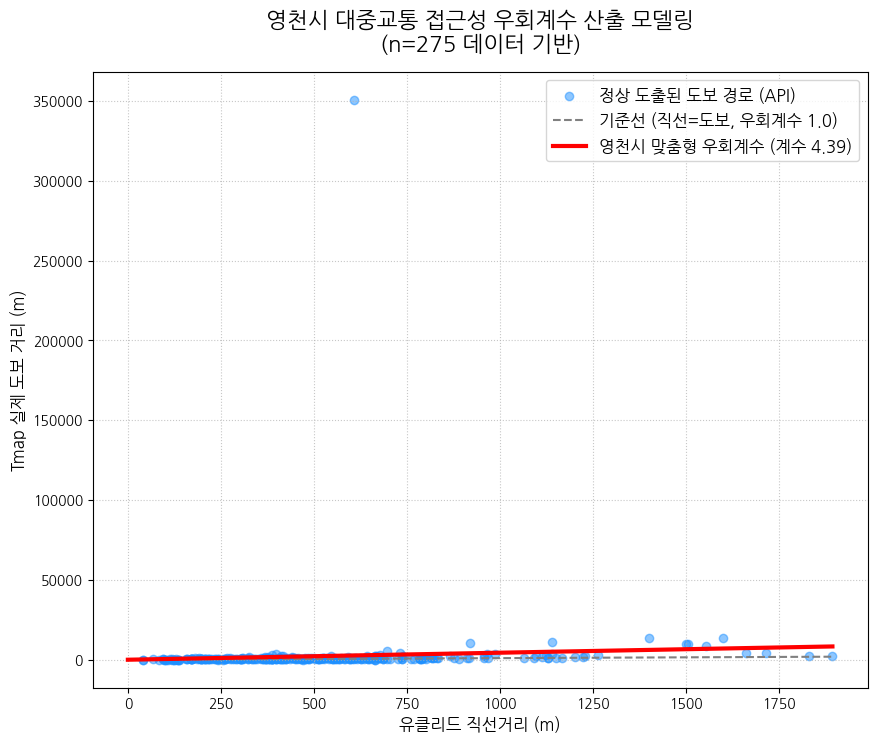

In [7]:
# ==============================================================
# 🎨 [0/4] 나눔고딕 폰트 설치 및 한글 설정 (코랩 환경 전용)
# ==============================================================
# 리눅스 환경에 나눔 폰트 설치 (출력 숨김 처리)
!apt-get -qq -y install fonts-nanum > /dev/null

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import warnings

warnings.filterwarnings('ignore')

# 설치된 나눔고딕 폰트를 시스템에 바로 적용 (런타임 재시작 방지)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumGothic')

# 마이너스(-) 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# ==============================================================
# 🚨 [1/4] 데이터 로드 및 성공 데이터 추출
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

print("🔄 1단계: API 성공 데이터를 모두 수집합니다...")
df_all = pd.read_csv(BASE_DIR + '1_all_3_success_min_dist.csv')
df_partial = pd.read_csv(BASE_DIR + '3_partial_success_reference.csv')

# 성공한 (직선거리, 실제거리) 쌍을 담을 리스트
valid_pairs = []

# 전체 성공 파일 + 부분 성공 파일 모두 반복
for df in [df_all, df_partial]:
    for rank in ['1st', '2nd', '3rd']:
        # 해당 순위가 API 호출 성공('Y')한 경우만 필터링
        valid_rows = df[df[f'{rank}_success'] == 'Y']
        for _, row in valid_rows.iterrows():
            euclid = row[f'{rank}_dist_m']
            actual = row[f'{rank}_walk_dist']

            # 거리가 0 이상인 정상 데이터만 수집
            if pd.notna(euclid) and pd.notna(actual) and euclid > 0 and actual > 0:
                valid_pairs.append({'euclid': euclid, 'actual': actual})

df_pairs = pd.DataFrame(valid_pairs)
df_pairs['ratio'] = df_pairs['actual'] / df_pairs['euclid']

print(f"✅ 총 {len(df_pairs)}개의 유효한 (직선거리 vs 실제 도보거리) 데이터를 확보했습니다!")

# ==============================================================
# 🧮 [2/4] 3가지 기법으로 우회계수 계산
# ==============================================================
print("\n🧮 2단계: 최적의 우회계수를 계산합니다...")

# 기법 1: 중앙값 (Median)
coef_median = df_pairs['ratio'].median()

# 기법 2: 선형 회귀 (기울기 a 계산: sum(X*Y) / sum(X^2))
x = df_pairs['euclid'].values
y = df_pairs['actual'].values
coef_regression = np.sum(x * y) / np.sum(x * x)

# 기법 3: 이상치(IQR) 제거 후 평균
Q1 = df_pairs['ratio'].quantile(0.25)
Q3 = df_pairs['ratio'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_pure = df_pairs[(df_pairs['ratio'] >= lower_bound) & (df_pairs['ratio'] <= upper_bound)]
coef_mean_pure = df_pure['ratio'].mean()

print(f"▶ [기법 1] 중앙값 기반 우회계수: {coef_median:.3f}")
print(f"▶ [기법 2] 선형 회귀 우회계수:  {coef_regression:.3f}")
print(f"▶ [기법 3] 이상치 제거 평균 우회계수: {coef_mean_pure:.3f}")

# ==============================================================
# 🎯 [3/4] 최종 우회계수 설정
# ==============================================================
# 팀장님께서 가장 합리적이라고 판단하신 값을 선택해 주세요! (기본값: 선형 회귀)
FINAL_COEFFICIENT = coef_regression

print(f"\n🌟 결론: 영천시 지역 맞춤형 최종 우회계수는 [{FINAL_COEFFICIENT:.3f}] 로 결정합니다! 🌟")

# ==============================================================
# 📊 [4/4] 결과 시각화 (보고서/발표 자료용)
# ==============================================================
plt.figure(figsize=(10, 8))

# 1. 산점도 (실제 데이터 점 찍기)
plt.scatter(df_pairs['euclid'], df_pairs['actual'], alpha=0.5, color='dodgerblue', label='정상 도출된 도보 경로 (API)')

# 2. 기준선 (직선거리 = 도보거리, 우회계수 1.0)
max_val = df_pairs['euclid'].max()
plt.plot([0, max_val], [0, max_val], color='gray', linestyle='--', label='기준선 (직선=도보, 우회계수 1.0)')

# 3. 영천시 맞춤 우회계수 선
plt.plot([0, max_val], [0, max_val * FINAL_COEFFICIENT], color='red', linewidth=3,
         label=f'영천시 맞춤형 우회계수 (계수 {FINAL_COEFFICIENT:.2f})')

plt.title(f"영천시 대중교통 접근성 우회계수 산출 모델링\n(n={len(df_pairs)} 데이터 기반)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("유클리드 직선거리 (m)", fontsize=12)
plt.ylabel("Tmap 실제 도보 거리 (m)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

# 이미지 저장
img_path = BASE_DIR + 'yeongcheon_detour_coefficient_model.png'
plt.savefig(img_path, dpi=300, bbox_inches='tight')
print(f"📁 모델링 그래프가 저장되었습니다: {img_path}")

plt.show()

✅ 전체 데이터: 275건 -> 5%~95% 절사 후 데이터: 247건 (28건 제거됨)
🌟 결론: 영천시 지역 맞춤형 최종 우회계수 (Trimmed OLS) = [1.615] 🌟


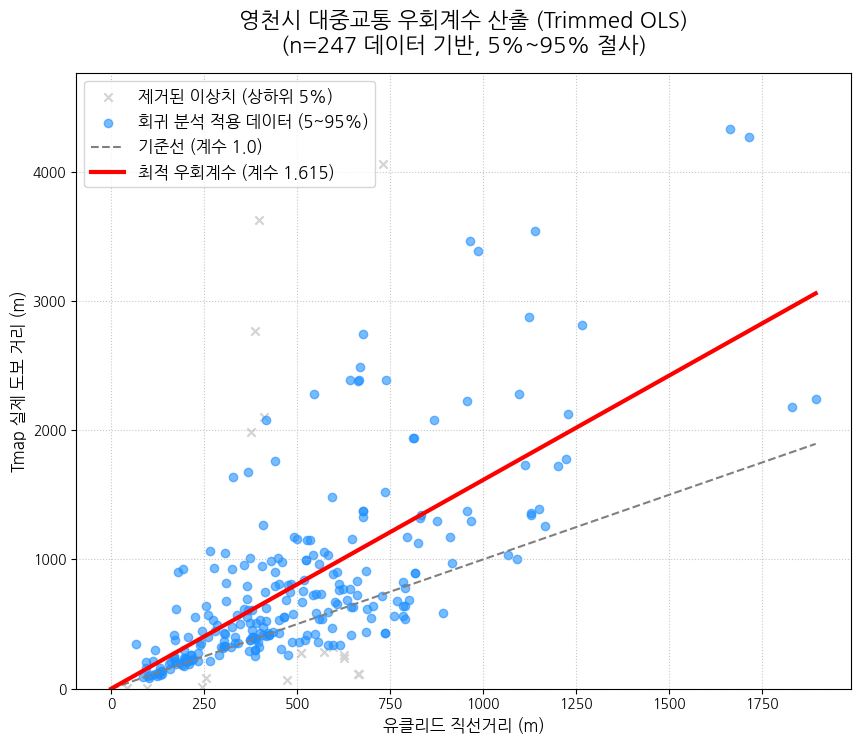

In [8]:
# ==============================================================
# 🎨 [0/4] 나눔고딕 폰트 설치 (코랩 환경 전용)
# ==============================================================
!apt-get -qq -y install fonts-nanum > /dev/null

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import warnings

warnings.filterwarnings('ignore')

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# ==============================================================
# 🚨 [1/4] 데이터 로드 및 성공 데이터 추출
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

df_all = pd.read_csv(BASE_DIR + '1_all_3_success_min_dist.csv')
df_partial = pd.read_csv(BASE_DIR + '3_partial_success_reference.csv')

valid_pairs = []
for df in [df_all, df_partial]:
    for rank in ['1st', '2nd', '3rd']:
        valid_rows = df[df[f'{rank}_success'] == 'Y']
        for _, row in valid_rows.iterrows():
            euclid = row[f'{rank}_dist_m']
            actual = row[f'{rank}_walk_dist']
            if pd.notna(euclid) and pd.notna(actual) and euclid > 0 and actual > 0:
                valid_pairs.append({'euclid': euclid, 'actual': actual})

df_pairs = pd.DataFrame(valid_pairs)
df_pairs['ratio'] = df_pairs['actual'] / df_pairs['euclid']

# ==============================================================
# ✂️ [2/4] 상/하위 5% 절사 (Trim) 및 최적 우회계수 계산
# ==============================================================
# 비율(ratio) 기준 하위 5%, 상위 95% 경계값 계산
p05 = df_pairs['ratio'].quantile(0.05)
p95 = df_pairs['ratio'].quantile(0.95)

# 이상치가 제거된 순수 데이터셋 생성
df_trimmed = df_pairs[(df_pairs['ratio'] >= p05) & (df_pairs['ratio'] <= p95)]

print(f"✅ 전체 데이터: {len(df_pairs)}건 -> 5%~95% 절사 후 데이터: {len(df_trimmed)}건 ({(len(df_pairs)-len(df_trimmed))}건 제거됨)")

# 🌟 절사 선형 회귀 (Trimmed OLS without intercept) 계산
x_trim = df_trimmed['euclid'].values
y_trim = df_trimmed['actual'].values
FINAL_COEFFICIENT = np.sum(x_trim * y_trim) / np.sum(x_trim * x_trim)

print(f"🌟 결론: 영천시 지역 맞춤형 최종 우회계수 (Trimmed OLS) = [{FINAL_COEFFICIENT:.3f}] 🌟")

# ==============================================================
# 📊 [3/4] 결과 시각화
# ==============================================================
plt.figure(figsize=(10, 8))

# 1. 제거된 이상치 (회색 x 표시)
df_outliers = df_pairs[(df_pairs['ratio'] < p05) | (df_pairs['ratio'] > p95)]
plt.scatter(df_outliers['euclid'], df_outliers['actual'], color='lightgray', marker='x', label='제거된 이상치 (상하위 5%)')

# 2. 분석에 사용된 순수 데이터 (파란 점)
plt.scatter(df_trimmed['euclid'], df_trimmed['actual'], alpha=0.6, color='dodgerblue', label='회귀 분석 적용 데이터 (5~95%)')

# 3. 기준선 (직선거리 = 도보거리)
max_val = df_trimmed['euclid'].max()
plt.plot([0, max_val], [0, max_val], color='gray', linestyle='--', label='기준선 (계수 1.0)')

# 4. 최종 도출된 영천시 맞춤 우회계수 선
plt.plot([0, max_val], [0, max_val * FINAL_COEFFICIENT], color='red', linewidth=3,
         label=f'최적 우회계수 (계수 {FINAL_COEFFICIENT:.3f})')

plt.title(f"영천시 대중교통 우회계수 산출 (Trimmed OLS)\n(n={len(df_trimmed)} 데이터 기반, 5%~95% 절사)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("유클리드 직선거리 (m)", fontsize=12)
plt.ylabel("Tmap 실제 도보 거리 (m)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

# y축 범위를 잘려나간 데이터 기준이 아닌, 순수 데이터 기준으로 맞춰서 그래프 가독성 극대화
plt.ylim(0, df_trimmed['actual'].max() * 1.1)

img_path = BASE_DIR + 'yeongcheon_trimmed_ols_model.png'
plt.savefig(img_path, dpi=300, bbox_inches='tight')

plt.show()

✅ 수집된 전체 데이터: 275건
🚫 1차 정제 (비율 1.0 미만 물리적 오류 배제): 78건
▶ 1차 정제 후 유효 데이터: 197건

✂️ 2차 정제 (상하위 5% 통계적 극단치 배제): 20건
✅ 최종 분석(선형 회귀) 적용 데이터: 177건

🌟 결론: 오류 완벽 정제! 영천시 최종 맞춤형 우회계수 = [2.027] 🌟
📁 최종 모델링 그래프가 저장되었습니다: /content/drive/MyDrive/영천의미학/yeongcheon_final_detour_model.png


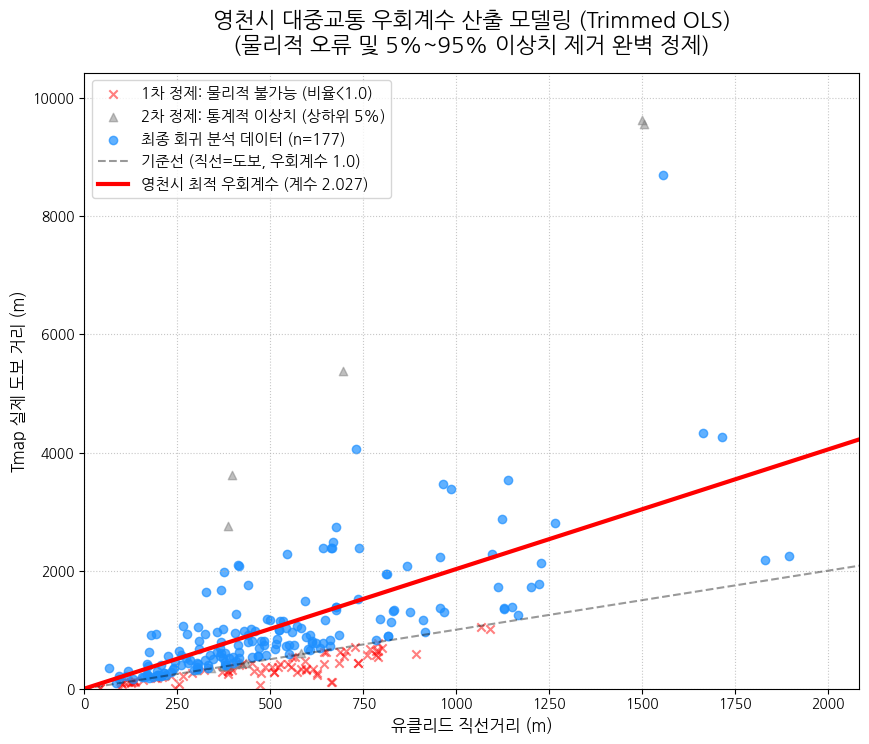

In [9]:
# ==============================================================
# 🎨 [0/4] 나눔고딕 폰트 설치 (코랩 환경 전용)
# ==============================================================
!apt-get -qq -y install fonts-nanum > /dev/null

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import warnings

warnings.filterwarnings('ignore')

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# ==============================================================
# 🚨 [1/4] 데이터 로드 및 1차 정제 (물리적 오류 제거)
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

df_all = pd.read_csv(BASE_DIR + '1_all_3_success_min_dist.csv')
df_partial = pd.read_csv(BASE_DIR + '3_partial_success_reference.csv')

valid_pairs = []
error_pairs = [] # 1차 배제: 비율 1.0 미만 (직선거리 > 도보거리) 물리적 오류 데이터

for df in [df_all, df_partial]:
    for rank in ['1st', '2nd', '3rd']:
        valid_rows = df[df[f'{rank}_success'] == 'Y']
        for _, row in valid_rows.iterrows():
            euclid = row[f'{rank}_dist_m']
            actual = row[f'{rank}_walk_dist']

            # 값이 존재하는 정상적인 데이터 쌍 확인
            if pd.notna(euclid) and pd.notna(actual) and euclid > 0 and actual > 0:
                if actual >= euclid:
                    # 정상: 도보거리가 직선거리보다 길거나 같음 (비율 >= 1.0)
                    valid_pairs.append({'euclid': euclid, 'actual': actual})
                else:
                    # 비정상: 하늘을 나는 직선거리보다 도보거리가 짧음 (API 튕김 현상 등)
                    error_pairs.append({'euclid': euclid, 'actual': actual})

df_pairs = pd.DataFrame(valid_pairs)
df_pairs['ratio'] = df_pairs['actual'] / df_pairs['euclid']
df_error = pd.DataFrame(error_pairs)

print(f"✅ 수집된 전체 데이터: {len(df_pairs) + len(df_error)}건")
print(f"🚫 1차 정제 (비율 1.0 미만 물리적 오류 배제): {len(df_error)}건")
print(f"▶ 1차 정제 후 유효 데이터: {len(df_pairs)}건\n")

# ==============================================================
# ✂️ [2/4] 상/하위 5% 절사 (Trim) 및 최적 우회계수 계산
# ==============================================================
# 1차 정제된 순수 데이터에서 상하위 5% 경계값(Threshold) 계산
p05 = df_pairs['ratio'].quantile(0.05)
p95 = df_pairs['ratio'].quantile(0.95)

# 2차 정제 (통계적 이상치 제거)
df_trimmed = df_pairs[(df_pairs['ratio'] >= p05) & (df_pairs['ratio'] <= p95)]
df_outliers = df_pairs[(df_pairs['ratio'] < p05) | (df_pairs['ratio'] > p95)]

print(f"✂️ 2차 정제 (상하위 5% 통계적 극단치 배제): {len(df_outliers)}건")
print(f"✅ 최종 분석(선형 회귀) 적용 데이터: {len(df_trimmed)}건")

# 🌟 절사 선형 회귀 (Trimmed OLS without intercept) 계산
x_trim = df_trimmed['euclid'].values
y_trim = df_trimmed['actual'].values
FINAL_COEFFICIENT = np.sum(x_trim * y_trim) / np.sum(x_trim * x_trim)

print(f"\n🌟 결론: 오류 완벽 정제! 영천시 최종 맞춤형 우회계수 = [{FINAL_COEFFICIENT:.3f}] 🌟")

# ==============================================================
# 📊 [3/4] 결과 시각화
# ==============================================================
plt.figure(figsize=(10, 8))

# 1. 1차 제거 데이터 (빨간색 x 표시)
if not df_error.empty:
    plt.scatter(df_error['euclid'], df_error['actual'], color='red', marker='x', alpha=0.5, label='1차 정제: 물리적 불가능 (비율<1.0)')

# 2. 2차 제거 이상치 (회색 세모 표시)
if not df_outliers.empty:
    plt.scatter(df_outliers['euclid'], df_outliers['actual'], color='gray', marker='^', alpha=0.5, label='2차 정제: 통계적 이상치 (상하위 5%)')

# 3. 분석에 사용된 순수 데이터 (파란 점)
plt.scatter(df_trimmed['euclid'], df_trimmed['actual'], alpha=0.7, color='dodgerblue', label=f'최종 회귀 분석 데이터 (n={len(df_trimmed)})')

# 4. 기준선 (직선거리 = 도보거리)
max_x = df_trimmed['euclid'].max()
plt.plot([0, max_x * 1.1], [0, max_x * 1.1], color='black', linestyle='--', alpha=0.4, label='기준선 (직선=도보, 우회계수 1.0)')

# 5. 최종 도출된 영천시 맞춤 우회계수 선
plt.plot([0, max_x * 1.1], [0, max_x * 1.1 * FINAL_COEFFICIENT], color='red', linewidth=3,
         label=f'영천시 최적 우회계수 (계수 {FINAL_COEFFICIENT:.3f})')

plt.title(f"영천시 대중교통 우회계수 산출 모델링 (Trimmed OLS)\n(물리적 오류 및 5%~95% 이상치 제거 완벽 정제)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("유클리드 직선거리 (m)", fontsize=12)
plt.ylabel("Tmap 실제 도보 거리 (m)", fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)

# y축/x축 범위를 분석에 사용된 순수 데이터 기준으로 맞춰 그래프 가독성 극대화
plt.xlim(0, max_x * 1.1)
plt.ylim(0, df_trimmed['actual'].max() * 1.2)

# 이미지 저장
img_path = BASE_DIR + 'yeongcheon_final_detour_model.png'
plt.savefig(img_path, dpi=300, bbox_inches='tight')
print(f"📁 최종 모델링 그래프가 저장되었습니다: {img_path}")

plt.show()

In [10]:
import pandas as pd
import numpy as np

# ==============================================================
# 🚨 [세팅값] 데이터 경로 및 적용 계수 설정
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

# 앞서 도출한 영천시 맞춤형 우회계수
DETOUR_COEF = 2.027

# 성인 평균 도보 속도 (시속 4km = 분당 약 66.67m)
WALK_SPEED_M_PER_MIN = 66.67

print("🔄 1단계: 데이터를 불러옵니다...")
df_all_success = pd.read_csv(BASE_DIR + '1_all_3_success_min_dist.csv', encoding='utf-8-sig')
df_need_detour = pd.read_csv(BASE_DIR + '2_need_detour_coefficient.csv', encoding='utf-8-sig')

# ==============================================================
# 🧩 [2/3] 데이터 그룹별 최종 정보 추출 및 가공
# ==============================================================
print("🧩 2단계: 그룹별 최종 산출 로직을 적용합니다...")

# ----------------------------------------------------
# 🟢 그룹 A: 3개 모두 성공한 격자 (최소값 채택)
# ----------------------------------------------------
# selected_target(ex: 1순위)에 따라 정류장 이름, ID, 유클리드 거리를 가져오는 함수
def extract_target_info(row):
    rank = row['selected_target']
    if rank == '1순위':
        return pd.Series([row['1st_bus_stop'], row['1st_stop_id'], row['1st_dist_m']])
    elif rank == '2순위':
        return pd.Series([row['2nd_bus_stop'], row['2nd_stop_id'], row['2nd_dist_m']])
    else:
        return pd.Series([row['3rd_bus_stop'], row['3rd_stop_id'], row['3rd_dist_m']])

df_all_success[['target_bus_stop', 'target_stop_id', 'euclid_dist_m']] = df_all_success.apply(extract_target_info, axis=1)
df_all_success['final_walk_dist_m'] = df_all_success['final_min_dist_m'].round(1)
df_all_success['final_walk_time_min'] = df_all_success['final_min_time_min'].round(1)
df_all_success['calc_method'] = 'Tmap_API_Min (' + df_all_success['selected_target'] + ')'

# 필요한 컬럼만 추출
cols_to_keep = ['grid_id', 'target_bus_stop', 'target_stop_id', 'euclid_dist_m',
                'final_walk_dist_m', 'final_walk_time_min', 'calc_method']
df_A_final = df_all_success[cols_to_keep].copy()


# ----------------------------------------------------
# 🔴 그룹 B: 우회계수 적용 대상 격자 (가장 가까운 1순위 기준)
# ----------------------------------------------------
df_need_detour['target_bus_stop'] = df_need_detour['1st_bus_stop']
df_need_detour['target_stop_id'] = df_need_detour['1st_stop_id']
df_need_detour['euclid_dist_m'] = df_need_detour['1st_dist_m']

# 🌟 1순위 유클리드 거리에 우회계수(2.027) 곱하기 🌟
df_need_detour['final_walk_dist_m'] = (df_need_detour['1st_dist_m'] * DETOUR_COEF).round(1)

# 🌟 도보 속도로 소요 시간 계산 🌟
df_need_detour['final_walk_time_min'] = (df_need_detour['final_walk_dist_m'] / WALK_SPEED_M_PER_MIN).round(1)
df_need_detour['calc_method'] = f'Detour_Coefficient_Model ({DETOUR_COEF})'

df_B_final = df_need_detour[cols_to_keep].copy()

# ==============================================================
# 💾 [3/3] 최종 병합 및 파일 저장
# ==============================================================
print("💾 3단계: 두 그룹을 병합하고 마스터 파일을 생성합니다...")

# 두 데이터 프레임 위아래로 합치기
df_master = pd.concat([df_A_final, df_B_final], ignore_index=True)

# 결측치(API 통신 실패 등으로 거리가 비어있던 곳)가 모두 채워졌는지 확인
missing_check = df_master['final_walk_dist_m'].isna().sum()

# CSV 저장
save_path = BASE_DIR + 'FINAL_bus_accessibility_master.csv'
df_master.to_csv(save_path, index=False, encoding='utf-8-sig')

print("========================================")
print(f"✅ 대중교통 접근성 분석 최종 마스터 파일 생성 완료!")
print(f"총 격자 수: {len(df_master)}개 (그룹A: {len(df_A_final)}개 / 그룹B: {len(df_B_final)}개)")
if missing_check == 0:
    print("✨ 결측치 0개! 모든 격자의 보행 거리가 완벽하게 도출되었습니다.")
print(f"📁 저장 위치: {save_path}")
print("========================================")

display(df_master.sample(5)) # 무작위 5개 샘플 데이터 확인

🔄 1단계: 데이터를 불러옵니다...
🧩 2단계: 그룹별 최종 산출 로직을 적용합니다...
💾 3단계: 두 그룹을 병합하고 마스터 파일을 생성합니다...
✅ 대중교통 접근성 분석 최종 마스터 파일 생성 완료!
총 격자 수: 721개 (그룹A: 79개 / 그룹B: 642개)
✨ 결측치 0개! 모든 격자의 보행 거리가 완벽하게 도출되었습니다.
📁 저장 위치: /content/drive/MyDrive/영천의미학/FINAL_bus_accessibility_master.csv


,grid_id,target_bus_stop,target_stop_id,euclid_dist_m,final_walk_dist_m,final_walk_time_min,calc_method
65,마마2879,도림(영천방면),570586.0,117.4,117.0,1.5,Tmap_API_Min (1순위)
511,마마3380,우항.굽들(우항방면),570234.0,350.3,710.1,10.7,Detour_Coefficient_Model (2.027)
698,마마2595,죽전숲(상송방면),570825.0,1371.4,2779.8,41.7,Detour_Coefficient_Model (2.027)
286,마마3571,반정3리(경반마을건너),571443.0,83.7,169.7,2.5,Detour_Coefficient_Model (2.027)
620,마마3486,삼매1리경로당건너,570520.0,720.6,1460.7,21.9,Detour_Coefficient_Model (2.027)


In [11]:
import pandas as pd
import numpy as np

# ==============================================================
# 🚨 [세팅값] 데이터 경로 및 적용 계수 설정
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

# 앞서 도출한 영천시 맞춤형 우회계수
DETOUR_COEF = 2.027

# 성인 평균 도보 속도 (시속 4km = 분당 약 66.67m)
WALK_SPEED_M_PER_MIN = 66.67

print("🔄 1단계: 데이터를 불러옵니다...")
df_all_success = pd.read_csv(BASE_DIR + '1_all_3_success_min_dist.csv', encoding='utf-8-sig')
df_need_detour = pd.read_csv(BASE_DIR + '2_need_detour_coefficient.csv', encoding='utf-8-sig')

# ==============================================================
# 🧩 [2/4] 그룹별 기본 데이터 가공
# ==============================================================
print("🧩 2단계: 그룹별 최종 산출 로직을 적용합니다...")

# --- 🟢 그룹 A: 3개 모두 성공한 격자 (기본: 최소값 채택) ---
def extract_target_info(row):
    rank = row['selected_target']
    if rank == '1순위':
        return pd.Series([row['1st_bus_stop'], row['1st_stop_id'], row['1st_dist_m']])
    elif rank == '2순위':
        return pd.Series([row['2nd_bus_stop'], row['2nd_stop_id'], row['2nd_dist_m']])
    else:
        return pd.Series([row['3rd_bus_stop'], row['3rd_stop_id'], row['3rd_dist_m']])

df_all_success[['target_bus_stop', 'target_stop_id', 'euclid_dist_m']] = df_all_success.apply(extract_target_info, axis=1)
df_all_success['final_walk_dist_m'] = df_all_success['final_min_dist_m'].round(1)
df_all_success['final_walk_time_min'] = df_all_success['final_min_time_min'].round(1)
df_all_success['calc_method'] = 'Tmap_API_Min (' + df_all_success['selected_target'] + ')'

cols_to_keep = ['grid_id', 'target_bus_stop', 'target_stop_id', 'euclid_dist_m',
                'final_walk_dist_m', 'final_walk_time_min', 'calc_method']
df_A = df_all_success[cols_to_keep].copy()

# --- 🔴 그룹 B: 우회계수 적용 대상 격자 (기본: 1순위 타겟) ---
df_need_detour['target_bus_stop'] = df_need_detour['1st_bus_stop']
df_need_detour['target_stop_id'] = df_need_detour['1st_stop_id']
df_need_detour['euclid_dist_m'] = df_need_detour['1st_dist_m']
df_need_detour['final_walk_dist_m'] = (df_need_detour['1st_dist_m'] * DETOUR_COEF).round(1)
df_need_detour['final_walk_time_min'] = (df_need_detour['final_walk_dist_m'] / WALK_SPEED_M_PER_MIN).round(1)
df_need_detour['calc_method'] = f'Detour_Coefficient_Model ({DETOUR_COEF})'

df_B = df_need_detour[cols_to_keep].copy()

# 전체 병합
df_master = pd.concat([df_A, df_B], ignore_index=True)

# ==============================================================
# 🚨 [3/4] 물리적 불가능 데이터 강제 보정 (핵심 로직)
# ==============================================================
# 직선거리보다 도보거리가 짧은(말이 안 되는) 격자들 찾아내기
error_mask = df_master['final_walk_dist_m'] < df_master['euclid_dist_m']
error_count = error_mask.sum()

print("\n========================================")
print(f"🚨 [경고] 도보거리 < 직선거리 인 물리적 오류 격자 발견: {error_count}건")
print(f"🛠️ 해당 격자들의 Tmap 데이터를 폐기하고 우회계수({DETOUR_COEF})로 강제 보정합니다...")

# 조건에 맞는 행들만 우회계수 값으로 덮어쓰기
df_master.loc[error_mask, 'final_walk_dist_m'] = (df_master.loc[error_mask, 'euclid_dist_m'] * DETOUR_COEF).round(1)
df_master.loc[error_mask, 'final_walk_time_min'] = (df_master.loc[error_mask, 'final_walk_dist_m'] / WALK_SPEED_M_PER_MIN).round(1)
# 산출 방식 컬럼에 '오류 보정됨' 꼬리표 달아두기
df_master.loc[error_mask, 'calc_method'] = f'Detour_Coefficient_Model ({DETOUR_COEF}) [오류 보정됨]'

# ==============================================================
# 💾 [4/4] 최종 검증 및 저장
# ==============================================================
remaining_errors = (df_master['final_walk_dist_m'] < df_master['euclid_dist_m']).sum()

# 새로운 이름으로 저장 (헷갈림 방지)
save_path = BASE_DIR + 'FINAL_bus_accessibility_master_Corrected.csv'
df_master.to_csv(save_path, index=False, encoding='utf-8-sig')

print("\n========================================")
print(f"✅ 대중교통 접근성 보정 완료 및 마스터 파일 생성 성공!")
print(f"총 격자 수: {len(df_master)}개")
if remaining_errors == 0:
    print("✨ 완벽! 물리적 모순 데이터가 0개로 클린하게 정제되었습니다.")
print(f"📁 저장 위치: {save_path}")
print("========================================")

# 보정된 데이터가 잘 들어갔는지 샘플로 몇 개만 띄워서 확인
if error_count > 0:
    print("\n[참고] 강제 보정된 격자 샘플 확인:")
    display(df_master[df_master['calc_method'].str.contains('오류 보정됨')].head())

🔄 1단계: 데이터를 불러옵니다...
🧩 2단계: 그룹별 최종 산출 로직을 적용합니다...

🚨 [경고] 도보거리 < 직선거리 인 물리적 오류 격자 발견: 33건
🛠️ 해당 격자들의 Tmap 데이터를 폐기하고 우회계수(2.027)로 강제 보정합니다...

✅ 대중교통 접근성 보정 완료 및 마스터 파일 생성 성공!
총 격자 수: 721개
✨ 완벽! 물리적 모순 데이터가 0개로 클린하게 정제되었습니다.
📁 저장 위치: /content/drive/MyDrive/영천의미학/FINAL_bus_accessibility_master_Corrected.csv

[참고] 강제 보정된 격자 샘플 확인:


,grid_id,target_bus_stop,target_stop_id,euclid_dist_m,final_walk_dist_m,final_walk_time_min,calc_method
0,마마2271,금호역,570112.0,582.0,1179.7,17.7,Detour_Coefficient_Model (2.027) [오류 보정됨]
2,마마2273,전륜사,571230.0,195.6,396.5,5.9,Detour_Coefficient_Model (2.027) [오류 보정됨]
3,마마2374,대평모텔건너,571690.0,510.1,1034.0,15.5,Detour_Coefficient_Model (2.027) [오류 보정됨]
4,마마2375,신덕2리.대평(청통방면),571232.0,570.9,1157.2,17.4,Detour_Coefficient_Model (2.027) [오류 보정됨]
6,마마3866,효리입구(영천방면),571407.0,291.2,590.3,8.9,Detour_Coefficient_Model (2.027) [오류 보정됨]


🔄 1단계: 데이터를 로드합니다...
🧩 2단계: 그룹별 로직 적용 및 고령자 보행 시간(속도 42m/분)을 계산합니다...
✅ 최종 마스터 파일 저장 완료: /content/drive/MyDrive/영천의미학/FINAL_bus_accessibility_master_Corrected.csv
🗺️ 4단계: 지도 시각화를 위한 공간 데이터를 생성합니다...
🔥 5단계: 영천시 대중교통 사각지대 히트맵을 렌더링합니다...
📁 히트맵 지도가 저장되었습니다: /content/drive/MyDrive/영천의미학/yeongcheon_bus_accessibility_heatmap.png


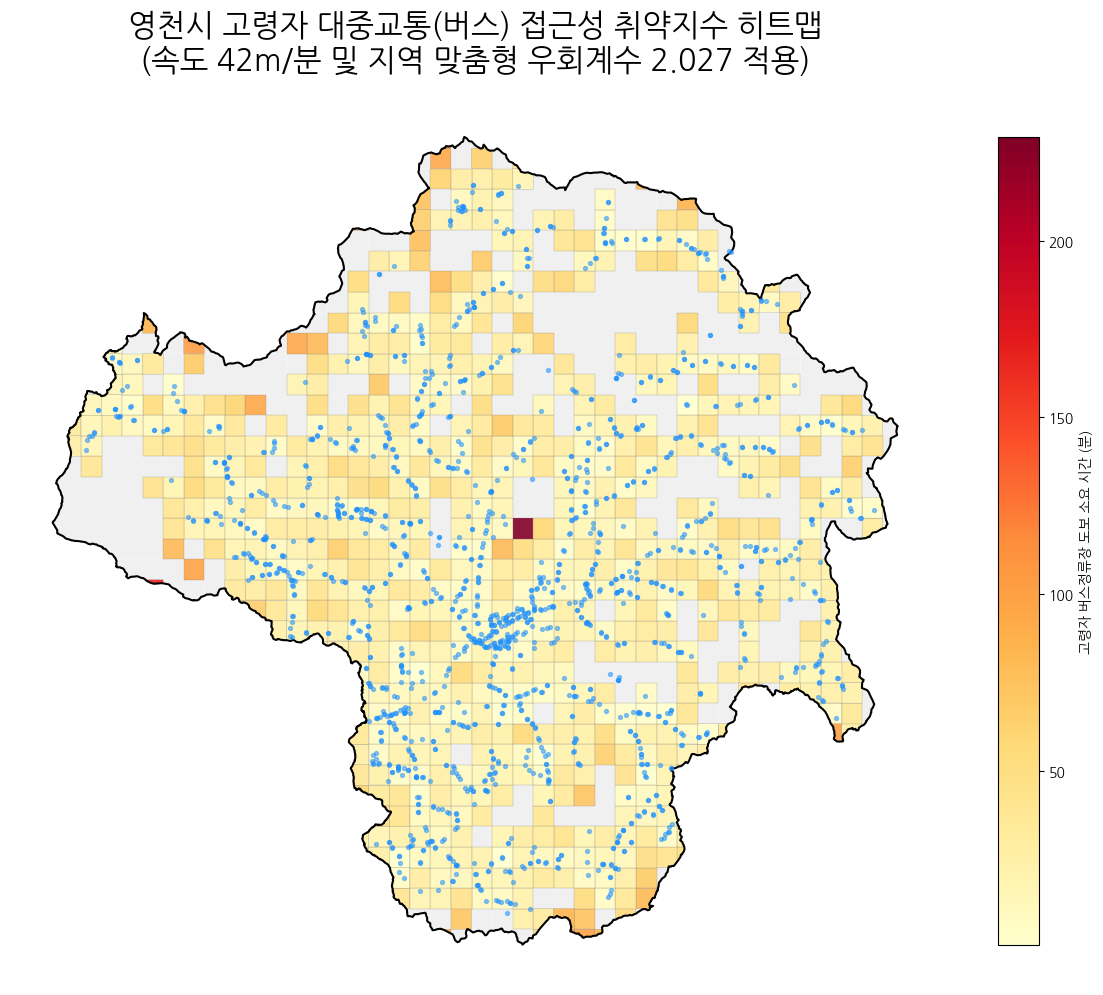

In [12]:
# ==============================================================
# 🎨 [0/5] 나눔고딕 폰트 설치 (코랩 환경 전용)
# ==============================================================
!apt-get -qq -y install fonts-nanum > /dev/null

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import warnings

warnings.filterwarnings('ignore')

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# ==============================================================
# 🚨 [1/5] 세팅값 및 데이터 로드
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

# 도출된 파라미터
DETOUR_COEF = 2.027                  # 영천시 맞춤형 우회계수
ELDERLY_SPEED_M_PER_MIN = 42.0       # 고령자 평균 보행 속도 (분당 42m)

print("🔄 1단계: 데이터를 로드합니다...")
df_all_success = pd.read_csv(BASE_DIR + '1_all_3_success_min_dist.csv', encoding='utf-8-sig')
df_need_detour = pd.read_csv(BASE_DIR + '2_need_detour_coefficient.csv', encoding='utf-8-sig')

# 지도 데이터 (이전 단계에서 사용한 파일명에 맞게 조정)
SHP_PATH = BASE_DIR + '_grid_border_grid_2025_grid_마마_grid_마마/grid_마마_1K.shp'
BORDER_PATH = BASE_DIR + '시군구/bnd_sigungu_37070_2025_2Q.shp'
BUS_PATH = BASE_DIR + 'bus_final.csv'

# ==============================================================
# 🧩 [2/5] 최종 데이터 병합 및 고령자 시간 계산
# ==============================================================
print("🧩 2단계: 그룹별 로직 적용 및 고령자 보행 시간(속도 42m/분)을 계산합니다...")

# --- 🟢 그룹 A (3개 성공 최소값) ---
def extract_target_info(row):
    rank = row['selected_target']
    if rank == '1순위': return pd.Series([row['1st_bus_stop'], row['1st_stop_id'], row['1st_dist_m']])
    elif rank == '2순위': return pd.Series([row['2nd_bus_stop'], row['2nd_stop_id'], row['2nd_dist_m']])
    else: return pd.Series([row['3rd_bus_stop'], row['3rd_stop_id'], row['3rd_dist_m']])

df_all_success[['target_bus_stop', 'target_stop_id', 'euclid_dist_m']] = df_all_success.apply(extract_target_info, axis=1)
df_all_success['final_walk_dist_m'] = df_all_success['final_min_dist_m'].round(1)
df_all_success['calc_method'] = 'Tmap_API_Min'
cols_to_keep = ['grid_id', 'target_bus_stop', 'target_stop_id', 'euclid_dist_m', 'final_walk_dist_m', 'calc_method']
df_A = df_all_success[cols_to_keep].copy()

# --- 🔴 그룹 B (우회계수 적용) ---
df_need_detour['target_bus_stop'] = df_need_detour['1st_bus_stop']
df_need_detour['target_stop_id'] = df_need_detour['1st_stop_id']
df_need_detour['euclid_dist_m'] = df_need_detour['1st_dist_m']
df_need_detour['final_walk_dist_m'] = (df_need_detour['1st_dist_m'] * DETOUR_COEF).round(1)
df_need_detour['calc_method'] = f'Detour_Model_{DETOUR_COEF}'
df_B = df_need_detour[cols_to_keep].copy()

df_master = pd.concat([df_A, df_B], ignore_index=True)

# ==============================================================
# 🚨 [3/5] 물리적 오류 보정 및 최종 체감 시간 도출
# ==============================================================
# 1. 도보 < 직선거리 모순 데이터 강제 보정
error_mask = df_master['final_walk_dist_m'] < df_master['euclid_dist_m']
df_master.loc[error_mask, 'final_walk_dist_m'] = (df_master.loc[error_mask, 'euclid_dist_m'] * DETOUR_COEF).round(1)
df_master.loc[error_mask, 'calc_method'] = f'Detour_Model_{DETOUR_COEF}_(오류보정)'

# 2. 👵 고령자 맞춤형 보행 소요 시간(분) 일괄 계산
df_master['elderly_walk_time_min'] = (df_master['final_walk_dist_m'] / ELDERLY_SPEED_M_PER_MIN).round(1)

# CSV 저장
save_path = BASE_DIR + 'FINAL_bus_accessibility_master_Corrected.csv'
df_master.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f"✅ 최종 마스터 파일 저장 완료: {save_path}")

# ==============================================================
# 🗺️ [4/5] 공간 데이터(GeoDataFrame) 결합 준비
# ==============================================================
print("🗺️ 4단계: 지도 시각화를 위한 공간 데이터를 생성합니다...")

# 영천시 경계선
try: sigungu_map = gpd.read_file(BORDER_PATH, encoding='utf-8')
except: sigungu_map = gpd.read_file(BORDER_PATH, encoding='cp949')
yeongcheon_border = sigungu_map[sigungu_map['SIGUNGU_NM'].str.contains('영천', na=False)].to_crs(epsg=5179)
if len(yeongcheon_border) == 0: yeongcheon_border = sigungu_map.to_crs(epsg=5179).copy()

# 격자 데이터
try: grid_map = gpd.read_file(SHP_PATH, encoding='utf-8').set_crs(epsg=5179, allow_override=True)
except: grid_map = gpd.read_file(SHP_PATH, encoding='cp949').set_crs(epsg=5179, allow_override=True)
yeongcheon_grid = gpd.clip(grid_map, yeongcheon_border)
grid_col = yeongcheon_grid.columns[0]
yeongcheon_grid[grid_col] = yeongcheon_grid[grid_col].astype(str).str.strip()

# 버스 정류장 포인트 (배경 참조용)
try: df_bus = pd.read_csv(BUS_PATH, encoding='utf-8')
except: df_bus = pd.read_csv(BUS_PATH, encoding='cp949')
gdf_bus = gpd.GeoDataFrame(df_bus, geometry=gpd.points_from_xy(df_bus['lon'], df_bus['lat']), crs="EPSG:4326").to_crs(epsg=5179)
gdf_bus = gpd.clip(gdf_bus, yeongcheon_border)

# 🌟 격자 + 접근성 결과 데이터 결합 (마스터파일의 grid_id 기준)
# 인구가 0명이라서 분석 제외된 격자는 흰색으로 남기기 위해 left 결합
map_data = yeongcheon_grid.merge(df_master, left_on=grid_col, right_on='grid_id', how='left')

# ==============================================================
# 🔥 [5/5] 대중교통 취약지수 히트맵 시각화
# ==============================================================
print("🔥 5단계: 영천시 대중교통 사각지대 히트맵을 렌더링합니다...")

fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# 1. 배경 영천시 외곽선
yeongcheon_border.boundary.plot(ax=ax, color='black', linewidth=1.5, zorder=3)

# 2. 비어있는 격자(인구 0명)는 옅은 회색으로 칠하기
map_data[map_data['elderly_walk_time_min'].isna()].plot(ax=ax, color='#f0f0f0', edgecolor='whitesmoke', linewidth=0.3, zorder=1)

# 3. 🔥 핵심: 분석된 격자에 히트맵(단계구분도) 칠하기 🔥
# cmap='YlOrRd' (Yellow to Red). 붉을수록 시간이 오래 걸리는 취약지역
map_data[map_data['elderly_walk_time_min'].notna()].plot(
    column='elderly_walk_time_min',
    ax=ax,
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': "고령자 버스정류장 도보 소요 시간 (분)", 'shrink': 0.7, 'orientation': "vertical"},
    edgecolor='gray',
    linewidth=0.2,
    alpha=0.9,
    zorder=2
)

# 4. 버스 정류장 포인트 (참고용)
gdf_bus.plot(ax=ax, color='dodgerblue', markersize=8, alpha=0.5, zorder=4, label='버스 정류장')

ax.set_title("영천시 고령자 대중교통(버스) 접근성 취약지수 히트맵\n(속도 42m/분 및 지역 맞춤형 우회계수 2.027 적용)",
             fontsize=22, fontweight='bold', pad=20)
ax.axis('off')

# 저장
heatmap_path = BASE_DIR + 'yeongcheon_bus_accessibility_heatmap.png'
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
print(f"📁 히트맵 지도가 저장되었습니다: {heatmap_path}")

plt.show()

🔄 1단계: 데이터를 로드합니다...
🧩 2단계: 그룹별 로직 적용 및 1차 보정을 수행합니다...
🗺️ 3단계: 지도 시각화를 위한 공간 데이터를 준비합니다...
🛠️ 4단계: '직선거리 3배 이상'인 이상치를 주변 평균으로 대체합니다...
🔥 5단계: 완벽하게 정제된 데이터로 히트맵을 렌더링합니다...
📁 히트맵 지도가 성공적으로 저장되었습니다: /content/drive/MyDrive/영천의미학/yeongcheon_bus_accessibility_heatmap_Final.png


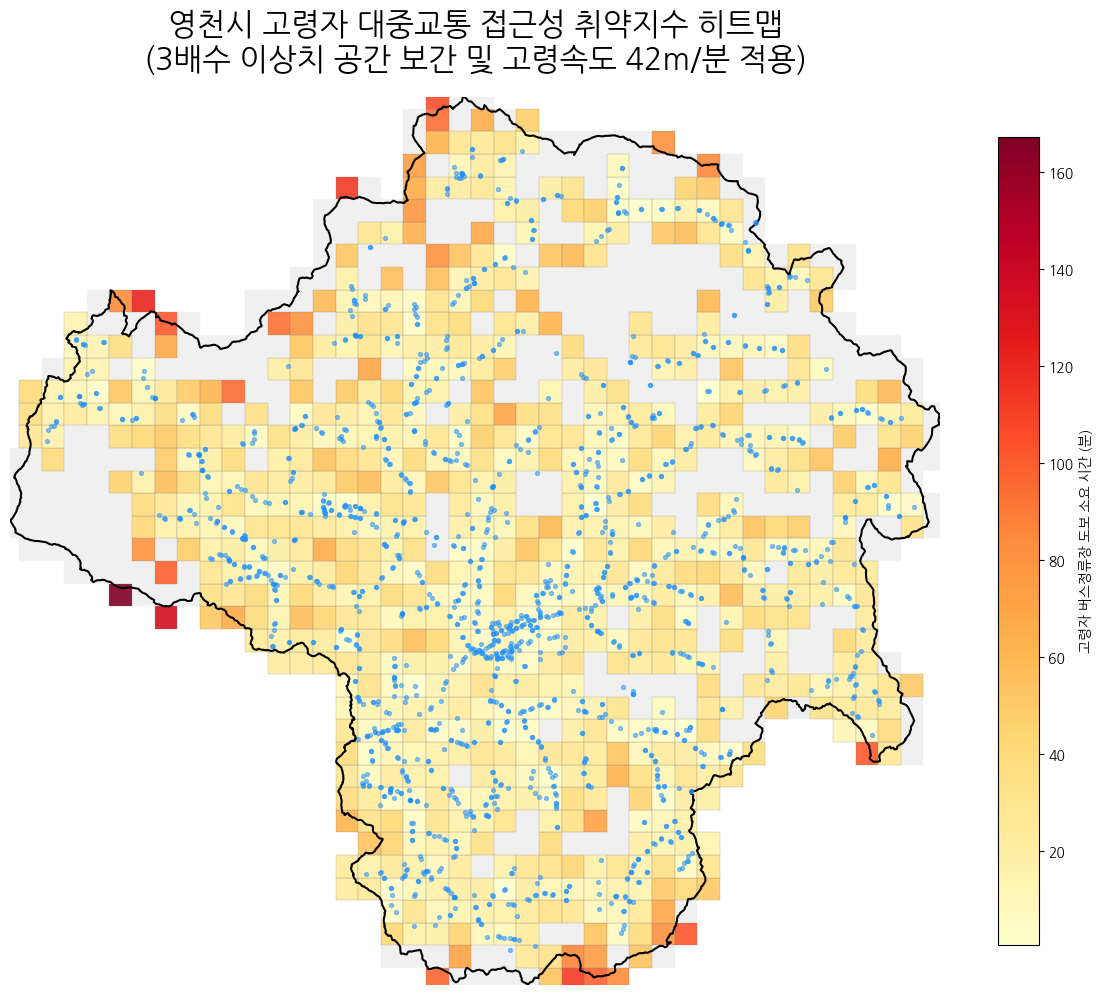

In [16]:
# ==============================================================
# 🎨 [0/6] 나눔고딕 폰트 설치 및 환경 설정
# ==============================================================
!apt-get -qq -y install fonts-nanum > /dev/null

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import warnings

warnings.filterwarnings('ignore')

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# ==============================================================
# 🚨 [1/6] 세팅값 및 데이터 로드
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

DETOUR_COEF = 2.027                  # 영천시 맞춤형 우회계수
ELDERLY_SPEED_M_PER_MIN = 42.0       # 고령자 평균 보행 속도 (분당 42m)

print("🔄 1단계: 데이터를 로드합니다...")
df_all_success = pd.read_csv(BASE_DIR + '1_all_3_success_min_dist.csv', encoding='utf-8-sig')
df_need_detour = pd.read_csv(BASE_DIR + '2_need_detour_coefficient.csv', encoding='utf-8-sig')

SHP_PATH = BASE_DIR + '_grid_border_grid_2025_grid_마마_grid_마마/grid_마마_1K.shp'
BORDER_PATH = BASE_DIR + '시군구/bnd_sigungu_37070_2025_2Q.shp'
BUS_PATH = BASE_DIR + 'bus_final.csv'

# ==============================================================
# 🧩 [2/6] 최종 데이터 병합 및 물리적 오류(1배 미만) 1차 보정
# ==============================================================
print("🧩 2단계: 그룹별 로직 적용 및 1차 보정을 수행합니다...")

def extract_target_info(row):
    rank = row['selected_target']
    if rank == '1순위': return pd.Series([row['1st_bus_stop'], row['1st_stop_id'], row['1st_dist_m']])
    elif rank == '2순위': return pd.Series([row['2nd_bus_stop'], row['2nd_stop_id'], row['2nd_dist_m']])
    else: return pd.Series([row['3rd_bus_stop'], row['3rd_stop_id'], row['3rd_dist_m']])

df_all_success[['target_bus_stop', 'target_stop_id', 'euclid_dist_m']] = df_all_success.apply(extract_target_info, axis=1)
df_all_success['final_walk_dist_m'] = df_all_success['final_min_dist_m'].round(1)
df_all_success['calc_method'] = 'Tmap_API_Min'
cols_to_keep = ['grid_id', 'target_bus_stop', 'target_stop_id', 'euclid_dist_m', 'final_walk_dist_m', 'calc_method']
df_A = df_all_success[cols_to_keep].copy()

df_need_detour['target_bus_stop'] = df_need_detour['1st_bus_stop']
df_need_detour['target_stop_id'] = df_need_detour['1st_stop_id']
df_need_detour['euclid_dist_m'] = df_need_detour['1st_dist_m']
df_need_detour['final_walk_dist_m'] = (df_need_detour['1st_dist_m'] * DETOUR_COEF).round(1)
df_need_detour['calc_method'] = f'Detour_Model_{DETOUR_COEF}'
df_B = df_need_detour[cols_to_keep].copy()

df_master = pd.concat([df_A, df_B], ignore_index=True)

# 물리적 오류 보정
error_mask = df_master['final_walk_dist_m'] < df_master['euclid_dist_m']
df_master.loc[error_mask, 'final_walk_dist_m'] = (df_master.loc[error_mask, 'euclid_dist_m'] * DETOUR_COEF).round(1)
df_master.loc[error_mask, 'calc_method'] = f'Detour_Model_{DETOUR_COEF}_(물리적오류보정)'

# 고령자 체감 소요 시간 계산
df_master['elderly_walk_time_min'] = (df_master['final_walk_dist_m'] / ELDERLY_SPEED_M_PER_MIN).round(1)

# ==============================================================
# 🗺️ [3/6] 공간 데이터 준비 (🌟 거대한 회색 배경 제거 로직 포함!)
# ==============================================================
print("🗺️ 3단계: 지도 시각화를 위한 공간 데이터를 준비합니다...")

try: sigungu_map = gpd.read_file(BORDER_PATH, encoding='utf-8')
except: sigungu_map = gpd.read_file(BORDER_PATH, encoding='cp949')
yeongcheon_border = sigungu_map[sigungu_map['SIGUNGU_NM'].str.contains('영천', na=False)].to_crs(epsg=5179)

try: grid_map = gpd.read_file(SHP_PATH, encoding='utf-8').set_crs(epsg=5179, allow_override=True)
except: grid_map = gpd.read_file(SHP_PATH, encoding='cp949').set_crs(epsg=5179, allow_override=True)

grid_col = grid_map.columns[0]
grid_map[grid_col] = grid_map[grid_col].astype(str).str.strip()
df_master['grid_id'] = df_master['grid_id'].astype(str).str.strip()

# 🌟 핵심 수정: 영천시 영역에 살짝이라도 닿아있는 격자만 안전하게 골라내기 (에러 안남)
yc_union = yeongcheon_border.unary_union
yeongcheon_grid = grid_map[grid_map.geometry.intersects(yc_union)].copy()

# 지도 데이터와 분석 데이터 병합
map_data = yeongcheon_grid.merge(df_master, left_on=grid_col, right_on='grid_id', how='left')

try: df_bus = pd.read_csv(BUS_PATH, encoding='utf-8')
except: df_bus = pd.read_csv(BUS_PATH, encoding='cp949')
gdf_bus = gpd.GeoDataFrame(df_bus, geometry=gpd.points_from_xy(df_bus['lon'], df_bus['lat']), crs="EPSG:4326").to_crs(epsg=5179)

# ==============================================================
# 🛠️ [4/6] 직선거리 3배 이상 라우팅 이상치 공간 보간
# ==============================================================
print("🛠️ 4단계: '직선거리 3배 이상'인 이상치를 주변 평균으로 대체합니다...")

outlier_mask = (map_data['final_walk_dist_m'] / map_data['euclid_dist_m']) >= 3.0
outliers = map_data[outlier_mask]

for idx, row in outliers.iterrows():
    centroid = row.geometry.centroid
    neighbors = map_data[
        (map_data.geometry.centroid.distance(centroid) <= 1500) &
        (map_data.index != idx) &
        (~outlier_mask)
    ]

    valid_neighbors = neighbors.dropna(subset=['elderly_walk_time_min'])

    if not valid_neighbors.empty:
        avg_dist = valid_neighbors['final_walk_dist_m'].mean()
        avg_time = valid_neighbors['elderly_walk_time_min'].mean()

        map_data.loc[idx, 'final_walk_dist_m'] = round(avg_dist, 1)
        map_data.loc[idx, 'elderly_walk_time_min'] = round(avg_time, 1)
        map_data.loc[idx, 'calc_method'] = 'Spatial_Interpolation (3배수_주변평균)'

        master_idx = df_master[df_master['grid_id'] == row['grid_id']].index
        df_master.loc[master_idx, 'final_walk_dist_m'] = round(avg_dist, 1)
        df_master.loc[master_idx, 'elderly_walk_time_min'] = round(avg_time, 1)
        df_master.loc[master_idx, 'calc_method'] = 'Spatial_Interpolation (3배수_주변평균)'

# ==============================================================
# 💾 [5/6] 최종 CSV 저장
# ==============================================================
save_path = BASE_DIR + 'FINAL_bus_accessibility_master_Smoothed.csv'
df_master.to_csv(save_path, index=False, encoding='utf-8-sig')

# ==============================================================
# 🔥 [6/6] 대중교통 취약지수 히트맵 시각화 (🌟 줌 아웃 방지 적용)
# ==============================================================
print("🔥 5단계: 완벽하게 정제된 데이터로 히트맵을 렌더링합니다...")

fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# 영천시 경계선 먼저 그리기
yeongcheon_border.boundary.plot(ax=ax, color='black', linewidth=1.5, zorder=3)

# 인구 0명 격자
map_data[map_data['elderly_walk_time_min'].isna()].plot(
    ax=ax, color='#f0f0f0', edgecolor='whitesmoke', linewidth=0.3, zorder=1
)

# 이상치 보정 완료된 히트맵
map_data[map_data['elderly_walk_time_min'].notna()].plot(
    column='elderly_walk_time_min',
    ax=ax,
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': "고령자 버스정류장 도보 소요 시간 (분)", 'shrink': 0.7, 'orientation': "vertical"},
    edgecolor='gray',
    linewidth=0.2,
    alpha=0.9,
    zorder=2
)

# 버스 정류장
gdf_bus.plot(ax=ax, color='dodgerblue', markersize=8, alpha=0.5, zorder=4, label='버스 정류장')

# 🌟 핵심: 카메라(축)를 영천시 크기에 딱 맞게 강제 고정 🌟
minx, miny, maxx, maxy = yeongcheon_border.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title("영천시 고령자 대중교통 접근성 취약지수 히트맵\n(3배수 이상치 공간 보간 및 고령속도 42m/분 적용)",
             fontsize=22, fontweight='bold', pad=20)
ax.axis('off')

heatmap_path = BASE_DIR + 'yeongcheon_bus_accessibility_heatmap_Final.png'
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
print(f"📁 히트맵 지도가 성공적으로 저장되었습니다: {heatmap_path}")

plt.show()

🔄 1단계: 데이터를 로드합니다...
🧩 2단계: 그룹별 로직 적용 및 물리적 오류 1차 보정을 수행합니다...
🗺️ 3단계: 지도 시각화를 위한 공간 데이터를 준비하고 경계선에 맞춰 예쁘게 오려냅니다...
🛠️ 4단계: '직선거리 3배 이상'인 이상치를 주변 평균으로 대체합니다...
🔥 5단계: 완벽하게 정제된 데이터로 히트맵을 렌더링합니다...
📁 완벽하게 크롭된 히트맵 지도가 저장되었습니다: /content/drive/MyDrive/영천의미학/yeongcheon_bus_accessibility_heatmap_Final_Clipped.png


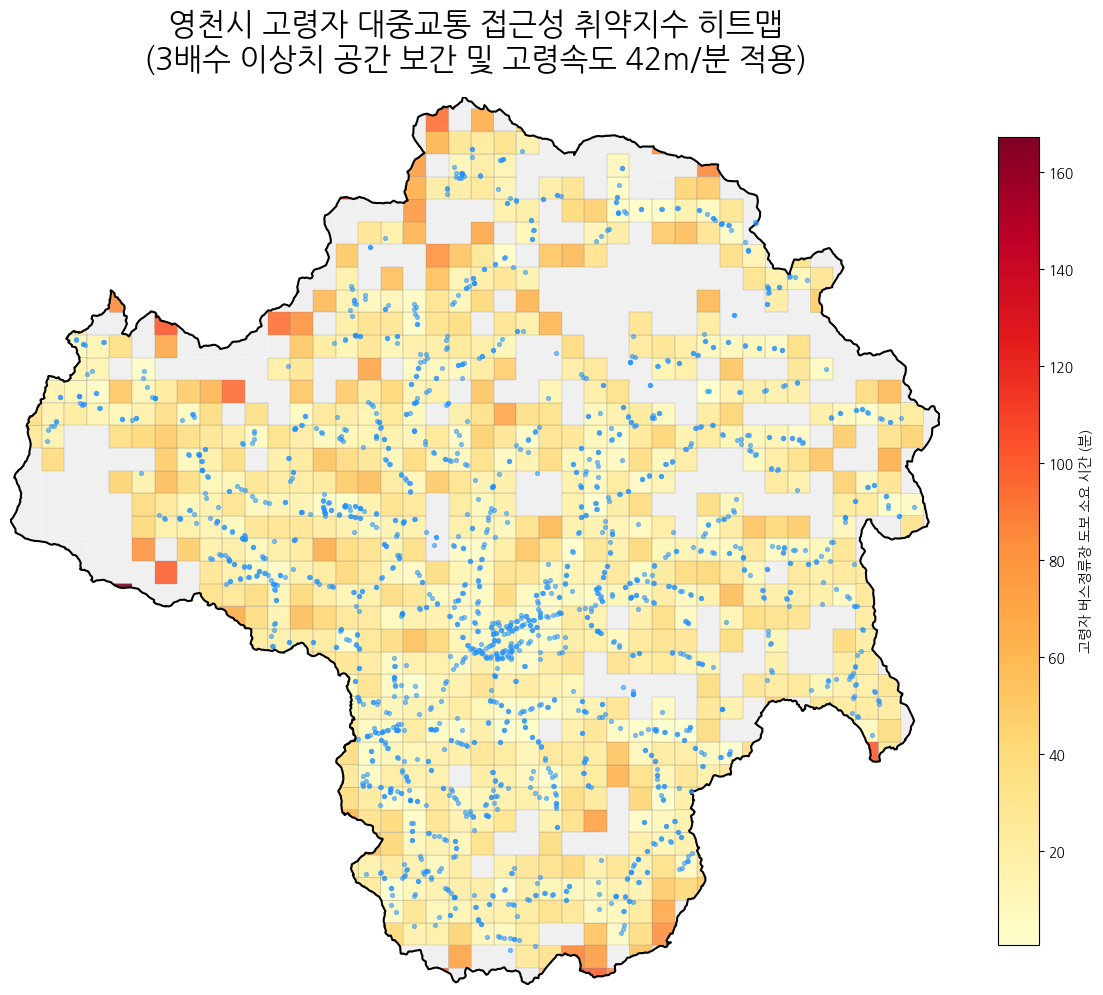

In [17]:
# ==============================================================
# 🎨 [0/6] 나눔고딕 폰트 설치 및 환경 설정
# ==============================================================
!apt-get -qq -y install fonts-nanum > /dev/null

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import warnings

warnings.filterwarnings('ignore')

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# ==============================================================
# 🚨 [1/6] 세팅값 및 데이터 로드
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

DETOUR_COEF = 2.027                  # 영천시 맞춤형 우회계수
ELDERLY_SPEED_M_PER_MIN = 42.0       # 고령자 평균 보행 속도 (분당 42m)

print("🔄 1단계: 데이터를 로드합니다...")
df_all_success = pd.read_csv(BASE_DIR + '1_all_3_success_min_dist.csv', encoding='utf-8-sig')
df_need_detour = pd.read_csv(BASE_DIR + '2_need_detour_coefficient.csv', encoding='utf-8-sig')

SHP_PATH = BASE_DIR + '_grid_border_grid_2025_grid_마마_grid_마마/grid_마마_1K.shp'
BORDER_PATH = BASE_DIR + '시군구/bnd_sigungu_37070_2025_2Q.shp'
BUS_PATH = BASE_DIR + 'bus_final.csv'

# ==============================================================
# 🧩 [2/6] 최종 데이터 병합 및 1차 보정
# ==============================================================
print("🧩 2단계: 그룹별 로직 적용 및 물리적 오류 1차 보정을 수행합니다...")

def extract_target_info(row):
    rank = row['selected_target']
    if rank == '1순위': return pd.Series([row['1st_bus_stop'], row['1st_stop_id'], row['1st_dist_m']])
    elif rank == '2순위': return pd.Series([row['2nd_bus_stop'], row['2nd_stop_id'], row['2nd_dist_m']])
    else: return pd.Series([row['3rd_bus_stop'], row['3rd_stop_id'], row['3rd_dist_m']])

df_all_success[['target_bus_stop', 'target_stop_id', 'euclid_dist_m']] = df_all_success.apply(extract_target_info, axis=1)
df_all_success['final_walk_dist_m'] = df_all_success['final_min_dist_m'].round(1)
df_all_success['calc_method'] = 'Tmap_API_Min'
cols_to_keep = ['grid_id', 'target_bus_stop', 'target_stop_id', 'euclid_dist_m', 'final_walk_dist_m', 'calc_method']
df_A = df_all_success[cols_to_keep].copy()

df_need_detour['target_bus_stop'] = df_need_detour['1st_bus_stop']
df_need_detour['target_stop_id'] = df_need_detour['1st_stop_id']
df_need_detour['euclid_dist_m'] = df_need_detour['1st_dist_m']
df_need_detour['final_walk_dist_m'] = (df_need_detour['1st_dist_m'] * DETOUR_COEF).round(1)
df_need_detour['calc_method'] = f'Detour_Model_{DETOUR_COEF}'
df_B = df_need_detour[cols_to_keep].copy()

df_master = pd.concat([df_A, df_B], ignore_index=True)

# 🚨 물리적 오류(도보 < 직선) 보정
error_mask = df_master['final_walk_dist_m'] < df_master['euclid_dist_m']
df_master.loc[error_mask, 'final_walk_dist_m'] = (df_master.loc[error_mask, 'euclid_dist_m'] * DETOUR_COEF).round(1)
df_master.loc[error_mask, 'calc_method'] = f'Detour_Model_{DETOUR_COEF}_(물리적오류보정)'

# 👵 고령자 체감 소요 시간 계산
df_master['elderly_walk_time_min'] = (df_master['final_walk_dist_m'] / ELDERLY_SPEED_M_PER_MIN).round(1)

# ==============================================================
# 🗺️ [3/6] 공간 데이터 준비 및 칼같은 잘라내기(Clipping)
# ==============================================================
print("🗺️ 3단계: 지도 시각화를 위한 공간 데이터를 준비하고 경계선에 맞춰 예쁘게 오려냅니다...")

# 1. 영천시 경계선 로드 및 에러 방지용 buffer(0) 처리
try: sigungu_map = gpd.read_file(BORDER_PATH, encoding='utf-8')
except: sigungu_map = gpd.read_file(BORDER_PATH, encoding='cp949')
yeongcheon_border = sigungu_map[sigungu_map['SIGUNGU_NM'].str.contains('영천', na=False)].to_crs(epsg=5179)
yeongcheon_border['geometry'] = yeongcheon_border.geometry.buffer(0)

# 2. 격자 데이터 로드 및 에러 방지용 buffer(0) 처리
try: grid_map = gpd.read_file(SHP_PATH, encoding='utf-8').set_crs(epsg=5179, allow_override=True)
except: grid_map = gpd.read_file(SHP_PATH, encoding='cp949').set_crs(epsg=5179, allow_override=True)
grid_map['geometry'] = grid_map.geometry.buffer(0)

grid_col = grid_map.columns[0]
grid_map[grid_col] = grid_map[grid_col].astype(str).str.strip()
df_master['grid_id'] = df_master['grid_id'].astype(str).str.strip()

# 🌟 핵심: 영천시 경계에 맞춰 격자들을 삐져나옴 없이 완벽하게 잘라내기 (Clip)
yeongcheon_grid = gpd.clip(grid_map, yeongcheon_border)

# 지도 데이터와 분석 데이터 병합
map_data = yeongcheon_grid.merge(df_master, left_on=grid_col, right_on='grid_id', how='left')

# 버스 정류장
try: df_bus = pd.read_csv(BUS_PATH, encoding='utf-8')
except: df_bus = pd.read_csv(BUS_PATH, encoding='cp949')
gdf_bus = gpd.GeoDataFrame(df_bus, geometry=gpd.points_from_xy(df_bus['lon'], df_bus['lat']), crs="EPSG:4326").to_crs(epsg=5179)
gdf_bus = gpd.clip(gdf_bus, yeongcheon_border) # 버스 정류장도 깔끔하게 클리핑

# ==============================================================
# 🛠️ [4/6] 직선거리 3배 이상 라우팅 이상치 공간 보간
# ==============================================================
print("🛠️ 4단계: '직선거리 3배 이상'인 이상치를 주변 평균으로 대체합니다...")

outlier_mask = (map_data['final_walk_dist_m'] / map_data['euclid_dist_m']) >= 3.0
outliers = map_data[outlier_mask]

for idx, row in outliers.iterrows():
    centroid = row.geometry.centroid
    neighbors = map_data[
        (map_data.geometry.centroid.distance(centroid) <= 1500) &
        (map_data.index != idx) &
        (~outlier_mask)
    ]

    valid_neighbors = neighbors.dropna(subset=['elderly_walk_time_min'])

    if not valid_neighbors.empty:
        avg_dist = valid_neighbors['final_walk_dist_m'].mean()
        avg_time = valid_neighbors['elderly_walk_time_min'].mean()

        map_data.loc[idx, 'final_walk_dist_m'] = round(avg_dist, 1)
        map_data.loc[idx, 'elderly_walk_time_min'] = round(avg_time, 1)
        map_data.loc[idx, 'calc_method'] = 'Spatial_Interpolation (3배수_주변평균)'

        master_idx = df_master[df_master['grid_id'] == row['grid_id']].index
        df_master.loc[master_idx, 'final_walk_dist_m'] = round(avg_dist, 1)
        df_master.loc[master_idx, 'elderly_walk_time_min'] = round(avg_time, 1)
        df_master.loc[master_idx, 'calc_method'] = 'Spatial_Interpolation (3배수_주변평균)'

# ==============================================================
# 💾 [5/6] 최종 CSV 저장
# ==============================================================
save_path = BASE_DIR + 'FINAL_bus_accessibility_master_Smoothed.csv'
df_master.to_csv(save_path, index=False, encoding='utf-8-sig')

# ==============================================================
# 🔥 [6/6] 대중교통 취약지수 히트맵 시각화
# ==============================================================
print("🔥 5단계: 완벽하게 정제된 데이터로 히트맵을 렌더링합니다...")

fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# 1. 인구 0명(분석 제외) 격자는 옅은 회색으로 칠하기
map_data[map_data['elderly_walk_time_min'].isna()].plot(
    ax=ax, color='#f0f0f0', edgecolor='whitesmoke', linewidth=0.3, zorder=1
)

# 2. 이상치 보정 완료된 히트맵 렌더링 (경계선에 맞춰 예쁘게 잘린 상태)
map_data[map_data['elderly_walk_time_min'].notna()].plot(
    column='elderly_walk_time_min',
    ax=ax,
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': "고령자 버스정류장 도보 소요 시간 (분)", 'shrink': 0.7, 'orientation': "vertical"},
    edgecolor='gray',
    linewidth=0.2,
    alpha=0.9,
    zorder=2
)

# 3. 영천시 경계선 (맨 위에 선명하게 덮기)
yeongcheon_border.boundary.plot(ax=ax, color='black', linewidth=1.5, zorder=3)

# 4. 버스 정류장 포인트
gdf_bus.plot(ax=ax, color='dodgerblue', markersize=8, alpha=0.5, zorder=4, label='버스 정류장')

# 화면 비율 영천시에 꽉 차게 고정
minx, miny, maxx, maxy = yeongcheon_border.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title("영천시 고령자 대중교통 접근성 취약지수 히트맵\n(3배수 이상치 공간 보간 및 고령속도 42m/분 적용)",
             fontsize=22, fontweight='bold', pad=20)
ax.axis('off')

# 히트맵 이미지 저장
heatmap_path = BASE_DIR + 'yeongcheon_bus_accessibility_heatmap_Final_Clipped.png'
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
print(f"📁 완벽하게 크롭된 히트맵 지도가 저장되었습니다: {heatmap_path}")

plt.show()

In [18]:
# ==============================================================
# 🌍 [0/3] 지리 공간 네트워크 라이브러리 설치 (코랩용)
# ==============================================================
# OpenStreetMap(OSM) 데이터를 파이썬으로 불러오는 라이브러리입니다.
!pip install -q osmnx

import osmnx as ox
import pandas as pd
import geopandas as gpd
import random

# ==============================================================
# 📍 [1/3] 영천시 보행 가능 도로(Walkable Network) 데이터 수집
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

print("🔄 1단계: OpenStreetMap에서 영천시 실제 도로망 데이터를 다운로드합니다...")
print("⏳ (주의) 도시 전체의 지도를 불러오므로 약 1~3분 정도 소요될 수 있습니다. 잠시만 기다려주세요!")

# 대한민국 영천시의 '보행 가능 도로(walk)' 네트워크 다운로드
place_name = "Yeongcheon-si, Gyeongsangbuk-do, South Korea"
try:
    # 네트워크 그래프 불러오기
    G = ox.graph_from_place(place_name, network_type='walk')
    # 그래프를 노드(교차로/포인트)와 엣지(도로 단위)로 변환
    nodes, edges = ox.graph_to_gdfs(G)
    print(f"✅ 영천시 내 실제 보행 가능한 도로 포인트(Node) 총 {len(nodes)}개를 성공적으로 확보했습니다!")
except Exception as e:
    print(f"🚨 네트워크 다운로드 실패: {e}")

# ==============================================================
# 🎲 [2/3] 1,000개의 완벽한 샘플 무작위 추출 (Monte Carlo Sampling)
# ==============================================================
print("\n🎲 2단계: 수집된 도로 포인트 중 1,000개를 무작위로 추출합니다...")

# 통계적 유의성을 위한 1000개 샘플링 (재현성을 위해 random_state 고정)
SAMPLE_SIZE = 1000

if len(nodes) > SAMPLE_SIZE:
    sampled_nodes = nodes.sample(n=SAMPLE_SIZE, random_state=42)
else:
    sampled_nodes = nodes.copy()
    print("⚠️ 전체 노드가 1000개 미만이라 전체를 사용합니다.")

# 필요한 컬럼(위도, 경도)만 정리
# OSM 데이터는 기본적으로 y가 위도(lat), x가 경도(lon)입니다.
df_1000_pois = pd.DataFrame({
    'poi_id': [f"POI_{i:04d}" for i in range(1, len(sampled_nodes) + 1)],
    'lat': sampled_nodes['y'],
    'lon': sampled_nodes['x']
})

# ==============================================================
# 💾 [3/3] 새로운 API 통신용 기준 파일 저장
# ==============================================================
print("\n💾 3단계: 추출된 1,000개의 좌표를 CSV 파일로 저장합니다...")

save_path = BASE_DIR + 'yeongcheon_1000_real_pois.csv'
df_1000_pois.to_csv(save_path, index=False, encoding='utf-8-sig')

print("========================================")
print(f"🌟 완벽합니다! 가짜 격자가 아닌 '진짜 영천시 도로' 좌표 {len(df_1000_pois)}개가 저장되었습니다.")
print(f"📁 파일 위치: {save_path}")
print("========================================")

# 데이터 샘플 확인
display(df_1000_pois.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.6 MB/s eta 0:00:00
🔄 1단계: OpenStreetMap에서 영천시 실제 도로망 데이터를 다운로드합니다...
⏳ (주의) 도시 전체의 지도를 불러오므로 약 1~3분 정도 소요될 수 있습니다. 잠시만 기다려주세요!
✅ 영천시 내 실제 보행 가능한 도로 포인트(Node) 총 8332개를 성공적으로 확보했습니다!

🎲 2단계: 수집된 도로 포인트 중 1,000개를 무작위로 추출합니다...

💾 3단계: 추출된 1,000개의 좌표를 CSV 파일로 저장합니다...
🌟 완벽합니다! 가짜 격자가 아닌 '진짜 영천시 도로' 좌표 1000개가 저장되었습니다.
📁 파일 위치: /content/drive/MyDrive/영천의미학/yeongcheon_1000_real_pois.csv


,poi_id,lat,lon
osmid,,,
12969245675,POI_0001,35.980362,128.937697
11702840527,POI_0002,36.037432,128.907293
10210996472,POI_0003,35.902257,129.002600
12158731505,POI_0004,35.889929,128.886346
12455406993,POI_0005,35.887961,129.020865


🔄 1단계: 시각화할 데이터를 로드합니다...
🗺️ 2단계: 분포 지도를 렌더링합니다...
📁 분포 지도가 성공적으로 저장되었습니다: /content/drive/MyDrive/영천의미학/yeongcheon_OD_distribution_map.png


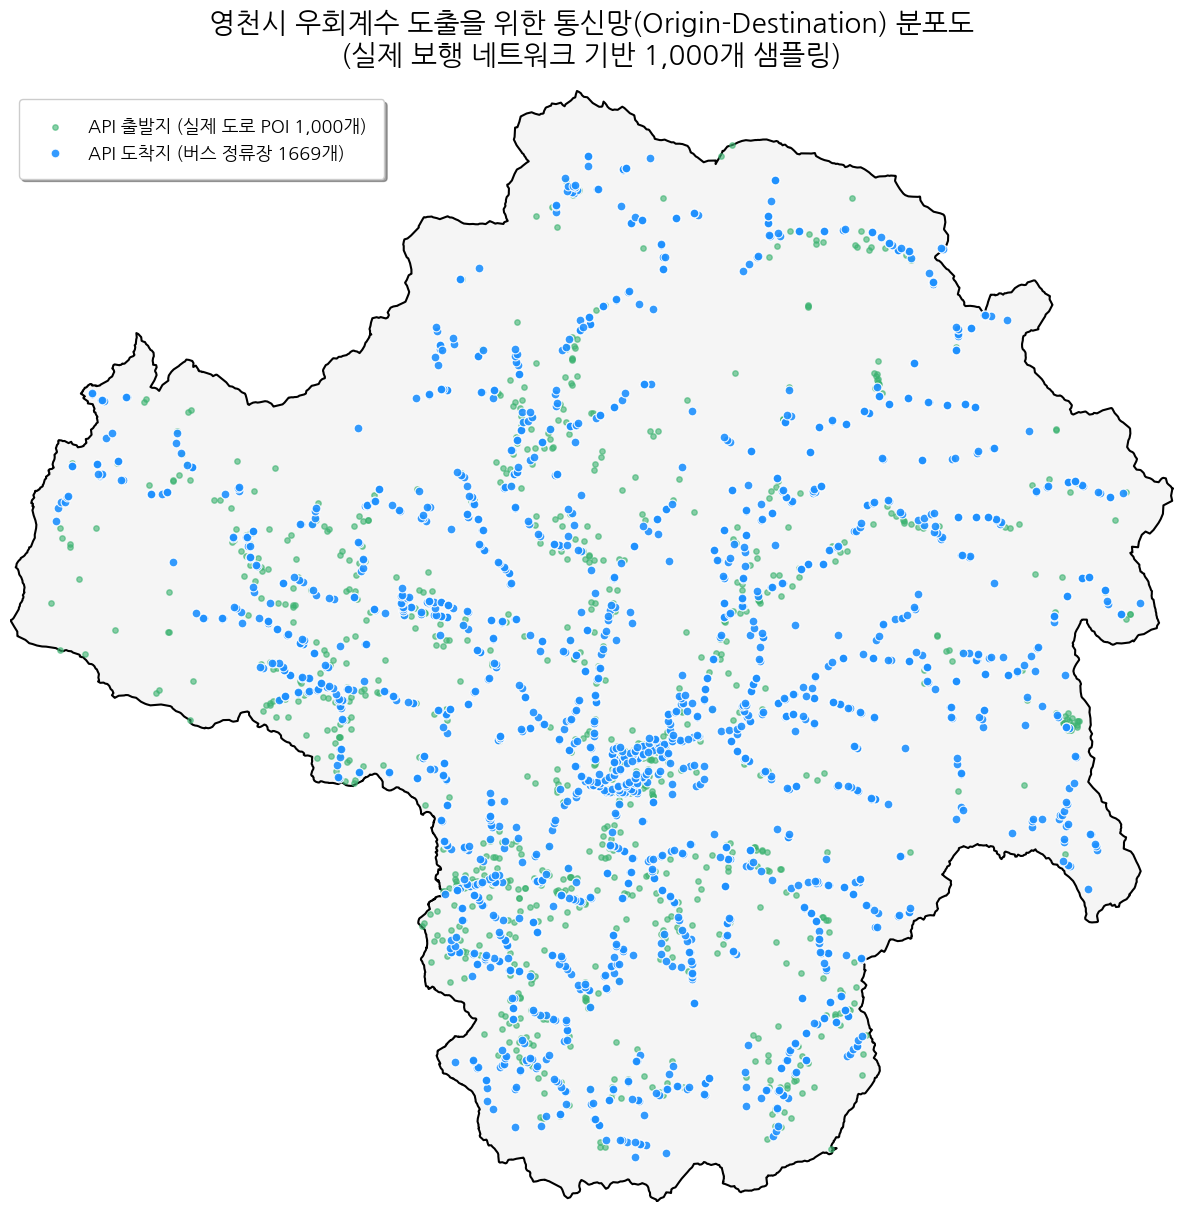

In [19]:
# ==============================================================
# 🎨 [0/4] 나눔고딕 폰트 설치 및 환경 설정
# ==============================================================
!apt-get -qq -y install fonts-nanum > /dev/null

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import warnings

warnings.filterwarnings('ignore')

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# ==============================================================
# 🚨 [1/4] 데이터 로드 (경계선, 버스정류장, 1000개 POI)
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

print("🔄 1단계: 시각화할 데이터를 로드합니다...")

# 1. 영천시 경계선 데이터
try: sigungu_map = gpd.read_file(BASE_DIR + '시군구/bnd_sigungu_37070_2025_2Q.shp', encoding='utf-8')
except: sigungu_map = gpd.read_file(BASE_DIR + '시군구/bnd_sigungu_37070_2025_2Q.shp', encoding='cp949')
yeongcheon_border = sigungu_map[sigungu_map['SIGUNGU_NM'].str.contains('영천', na=False)].to_crs(epsg=5179)
yeongcheon_border['geometry'] = yeongcheon_border.geometry.buffer(0)

# 2. 버스 정류장 데이터 (도착지)
try: df_bus = pd.read_csv(BASE_DIR + 'bus_final.csv', encoding='utf-8')
except: df_bus = pd.read_csv(BASE_DIR + 'bus_final.csv', encoding='cp949')
gdf_bus = gpd.GeoDataFrame(df_bus, geometry=gpd.points_from_xy(df_bus['lon'], df_bus['lat']), crs="EPSG:4326").to_crs(epsg=5179)
# 영천시 내부의 버스 정류장만 깔끔하게 클리핑
gdf_bus = gpd.clip(gdf_bus, yeongcheon_border)

# 3. 🌟 방금 추출한 1,000개 실제 보행로 좌표 (출발지) 🌟
df_pois = pd.read_csv(BASE_DIR + 'yeongcheon_1000_real_pois.csv', encoding='utf-8-sig')
gdf_pois = gpd.GeoDataFrame(df_pois, geometry=gpd.points_from_xy(df_pois['lon'], df_pois['lat']), crs="EPSG:4326").to_crs(epsg=5179)
# 좌표들이 영천시 경계 안에 완벽히 들어오도록 클리핑 (안전장치)
gdf_pois = gpd.clip(gdf_pois, yeongcheon_border)

# ==============================================================
# 🗺️ [2/4] 지도 렌더링 (시각화)
# ==============================================================
print("🗺️ 2단계: 분포 지도를 렌더링합니다...")

fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# 배경: 영천시 외곽선 (흰색 배경에 검은 테두리)
yeongcheon_border.plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=1.5, zorder=1)

# 레이어 1: 1,000개 보행자 출발지 (초록색 작은 점)
gdf_pois.plot(ax=ax, color='mediumseagreen', markersize=15, alpha=0.6, label=f'API 출발지 (실제 도로 POI 1,000개)', zorder=2)

# 레이어 2: 버스 정류장 (파란색 큰 점, 테두리 추가로 가독성 높임)
gdf_bus.plot(ax=ax, color='dodgerblue', markersize=40, alpha=0.9, edgecolor='white', linewidth=0.8, label=f'API 도착지 (버스 정류장 {len(gdf_bus)}개)', zorder=3)

# ==============================================================
# 🎨 [3/4] 디자인 및 디테일 설정
# ==============================================================
# 카메라(축)를 영천시에 꽉 차게 고정
minx, miny, maxx, maxy = yeongcheon_border.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title("영천시 우회계수 도출을 위한 통신망(Origin-Destination) 분포도\n(실제 보행 네트워크 기반 1,000개 샘플링)",
             fontsize=20, fontweight='bold', pad=20)

# 범례 설정
ax.legend(fontsize=13, loc='upper left', shadow=True, borderpad=1)
ax.axis('off')

# ==============================================================
# 💾 [4/4] 결과 저장
# ==============================================================
save_path = BASE_DIR + 'yeongcheon_OD_distribution_map.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"📁 분포 지도가 성공적으로 저장되었습니다: {save_path}")

plt.show()

In [23]:
import pandas as pd
import numpy as np
import requests
import time
from math import radians, cos, sin, asin, sqrt
import warnings

warnings.filterwarnings('ignore')

# ==============================================================
# 🚨 [0/4] Tmap API 키 및 세팅 (⭐⭐⭐ 여기에 API 키 입력! ⭐⭐⭐)
# ==============================================================
TMAP_APP_KEY = 'cjqutBVzxi9GYdCkwzGaY2Om4j5KPyPV6nRcj3gZ'  # 예: 'l7xx...'
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

# ==============================================================
# 🧮 [1/4] 하버사인(Haversine) 직선거리 계산 함수
# ==============================================================
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 6371000 # 지구 반지름 (미터)
    return c * r

# ==============================================================
# 📡 [2/4] Tmap 도보 API 호출 함수
# ==============================================================
def get_tmap_pedestrian_route(start_lon, start_lat, end_lon, end_lat, app_key):
    url = "https://apis.openapi.sk.com/tmap/routes/pedestrian?version=1&format=json&callback=result"
    headers = {"appKey": app_key}
    payload = {
        "startX": str(start_lon),
        "startY": str(start_lat),
        "endX": str(end_lon),
        "endY": str(end_lat),
        "reqCoordType": "WGS84GEO",
        "resCoordType": "WGS84GEO",
        "startName": "출발지",
        "endName": "도착지"
    }

    try:
        response = requests.post(url, json=payload, headers=headers)
        if response.status_code == 200:
            res_data = response.json()
            features = res_data.get('features', [])
            if features:
                properties = features[0]['properties']
                return properties.get('totalDistance'), properties.get('totalTime')
        return None, None
    except Exception as e:
        return None, None

# ==============================================================
# 🧩 [3/4] 데이터 로드 및 유연한 컬럼명 매칭
# ==============================================================
print("🔄 1단계: 데이터를 로드하고 컬럼명을 자동으로 매칭합니다...")

df_pois = pd.read_csv(BASE_DIR + 'yeongcheon_1000_real_pois.csv', encoding='utf-8-sig')
try: df_bus = pd.read_csv(BASE_DIR + 'bus_final.csv', encoding='utf-8')
except: df_bus = pd.read_csv(BASE_DIR + 'bus_final.csv', encoding='cp949')

# 🌟 핵심: 버스 정류장 이름과 ID 컬럼을 자동으로 찾아내는 방어 로직 🌟
bus_cols = df_bus.columns.tolist()

# 1. 정류장 이름 컬럼 찾기
name_candidates = ['정류소명', '정류장명', '정류소이름', 'bstop_nm', '정류소명칭']
bus_name_col = next((col for col in name_candidates if col in bus_cols), None)

# 2. 정류장 ID 컬럼 찾기
id_candidates = ['정류소ID', '정류장ID', '정류소번호', 'bstop_id', 'node_id', 'NODE_ID']
bus_id_col = next((col for col in id_candidates if col in bus_cols), None)

# 만약 자동 매칭에 실패했다면, 사용자에게 알리고 첫 번째/두 번째 컬럼을 임시로 사용
if not bus_name_col: bus_name_col = bus_cols[0]
if not bus_id_col: bus_id_col = bus_cols[1]

print(f"✅ 확인된 컬럼명 -> [이름: '{bus_name_col}', ID: '{bus_id_col}'] 로 진행합니다.")

# ==============================================================
# 🚀 [4/4] 1순위 정류장 매칭 (API 통신 실행)
# ==============================================================
results = []
total_pois = len(df_pois)

print(f"\n🚀 2단계: 총 {total_pois}개의 좌표에 대해 Tmap 도보 API 통신을 시작합니다!")
print("⏳ API Limit을 위해 0.3초씩 쉬면서 진행합니다...\n")

for idx, row in df_pois.iterrows():
    poi_id = row['poi_id']
    poi_lat = row['lat']
    poi_lon = row['lon']

    # 1. 하버사인 직선거리 계산
    distances = df_bus.apply(lambda b: haversine(poi_lon, poi_lat, b['lon'], b['lat']), axis=1)

    # 2. 가장 가까운(1순위) 버스정류장 찾기
    closest_idx = distances.idxmin()
    closest_bus = df_bus.loc[closest_idx]
    euclid_dist = distances[closest_idx]

    # 3. Tmap API 호출
    walk_dist, walk_time_sec = get_tmap_pedestrian_route(
        poi_lon, poi_lat, closest_bus['lon'], closest_bus['lat'], TMAP_APP_KEY
    )

    # 4. 결과 정리
    is_success = 'Y' if walk_dist is not None else 'N'

    results.append({
        'poi_id': poi_id,
        'poi_lat': poi_lat,
        'poi_lon': poi_lon,
        'target_bus_stop': closest_bus[bus_name_col], # 🌟 수정된 부분: 자동 매칭된 컬럼명 사용
        'target_stop_id': closest_bus[bus_id_col],    # 🌟 수정된 부분: 자동 매칭된 컬럼명 사용
        'euclid_dist_m': round(euclid_dist, 1),
        'api_walk_dist_m': walk_dist,
        'api_walk_time_sec': walk_time_sec,
        'api_success': is_success
    })

    if (idx + 1) % 100 == 0 or (idx + 1) == total_pois:
        success_count = sum(1 for r in results if r['api_success'] == 'Y')
        print(f"▶ 진행도: {idx + 1} / {total_pois} 완료 | 🟢 API 성공 누적: {success_count}건")

    time.sleep(0.3)

# ==============================================================
# 💾 [5/5] 결과 데이터프레임 생성 및 저장
# ==============================================================
df_results = pd.DataFrame(results)
df_results['api_walk_dist_m'] = df_results['api_walk_dist_m'].fillna(-1)
success_rate = (len(df_results[df_results['api_success'] == 'Y']) / len(df_results)) * 100

print("\n========================================")
print(f"✅ Tmap API 통신 완료! 최종 성공률: {success_rate:.1f}%")
save_path = BASE_DIR + '3_tmap_api_1000_results.csv'
df_results.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f"📁 결과 파일이 저장되었습니다: {save_path}")
print("========================================")

display(df_results.head())

🔄 1단계: 데이터를 로드하고 컬럼명을 자동으로 매칭합니다...
✅ 확인된 컬럼명 -> [이름: 'Bus_Stop', ID: 'Bus_StopID'] 로 진행합니다.

🚀 2단계: 총 1000개의 좌표에 대해 Tmap 도보 API 통신을 시작합니다!
⏳ API Limit을 위해 0.3초씩 쉬면서 진행합니다...

▶ 진행도: 100 / 1000 완료 | 🟢 API 성공 누적: 23건
▶ 진행도: 200 / 1000 완료 | 🟢 API 성공 누적: 52건
▶ 진행도: 300 / 1000 완료 | 🟢 API 성공 누적: 66건
▶ 진행도: 400 / 1000 완료 | 🟢 API 성공 누적: 85건
▶ 진행도: 500 / 1000 완료 | 🟢 API 성공 누적: 109건
▶ 진행도: 600 / 1000 완료 | 🟢 API 성공 누적: 125건
▶ 진행도: 700 / 1000 완료 | 🟢 API 성공 누적: 143건
▶ 진행도: 800 / 1000 완료 | 🟢 API 성공 누적: 162건
▶ 진행도: 900 / 1000 완료 | 🟢 API 성공 누적: 181건
▶ 진행도: 1000 / 1000 완료 | 🟢 API 성공 누적: 207건

✅ Tmap API 통신 완료! 최종 성공률: 20.7%
📁 결과 파일이 저장되었습니다: /content/drive/MyDrive/영천의미학/3_tmap_api_1000_results.csv


,poi_id,poi_lat,poi_lon,target_bus_stop,target_stop_id,euclid_dist_m,api_walk_dist_m,api_walk_time_sec,api_success
0,POI_0001,35.980362,128.937697,무궁화아파트앞,570030.0,625.6,1110.0,848.0,Y
1,POI_0002,36.037432,128.907293,대천2리(영천방면),570577.0,311.5,-1.0,NaN,N
2,POI_0003,35.902257,129.002600,고지1리(북안방면),571368.0,868.4,-1.0,NaN,N
3,POI_0004,35.889929,128.886346,포척(금호방면),570720.0,287.4,-1.0,NaN,N
4,POI_0005,35.887961,129.020865,도계서원입구,571415.0,13.6,-1.0,NaN,N
